In [1]:
import meshio
import os
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import pandas as pd
from numpy import genfromtxt
import math
import seaborn as sns
from matplotlib.patches import Circle
from scipy.interpolate import griddata

In [3]:
splishsplash_path = 'D:/gabi/'
splishsplash_path_e = 'E:/gabi/thesis/'

## Replication Study: Vorticity Refinement

In [9]:
#We tested for a small dambreak scenario if we could replicate the results. Also tested for a small dam break with wall scenario
# For each we have baseline, VR -1, + 1, -1.5 (breaks), +1.5 (breaks) - acceleration
# For each we have baseline, VR -1, + 1, -1.5, +1.5 - velocity

In [3]:
scene = 'DamBreakModel'
folder_path = splishsplash_path + '/' + scene + '/visc_standard_005/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModel/visc_standard_005/
['mp_01', 'mp_04', 'vc_01', 'vc_05', 'old', 'VR 1.5 - velocity', 'VR 1.0 - velocity', 'baseline', 'VR -1.5 - velocity', 'VR -1.0 - velocity', 'VR 1.0 - acceleration', 'VR -1.0 - acceleration', 'VR 1.0 - acceleration + corrected vorticity', 'vr 1.5 - visc 0.01']


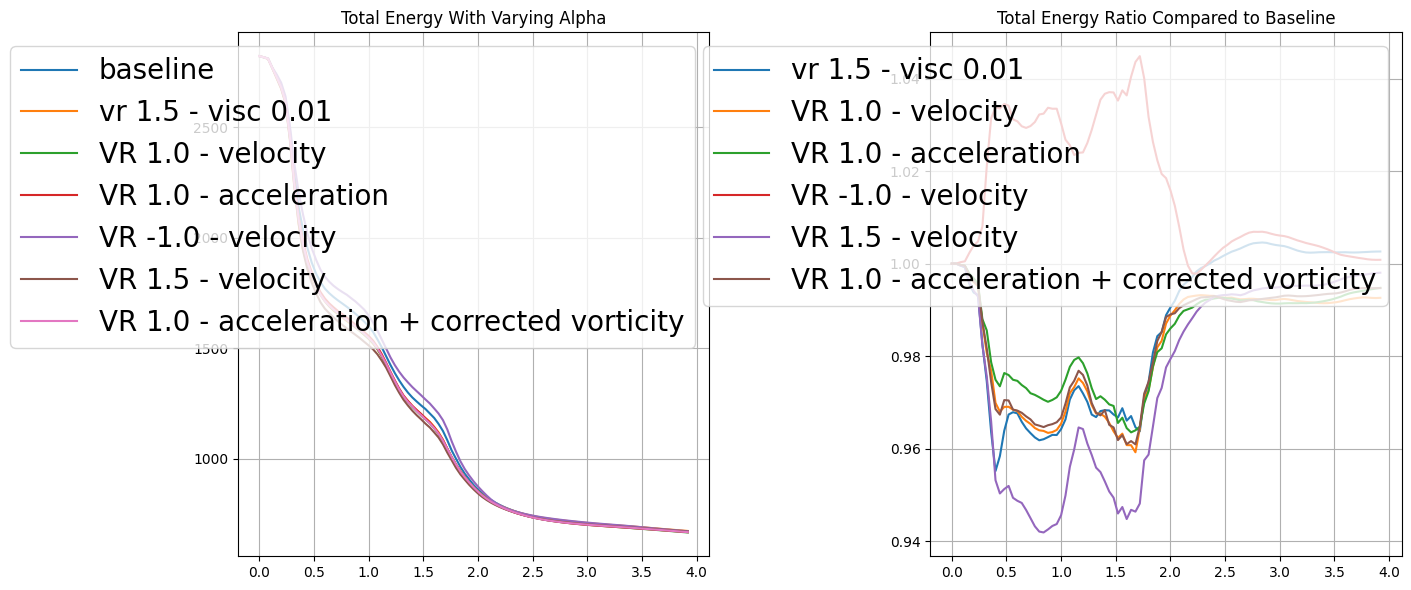

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 100
time = [i / 25 for i in range(99)]

for folder in ['baseline', 'vr 1.5 - visc 0.01', 'VR 1.0 - velocity', 'VR 1.0 - acceleration','VR -1.0 - velocity', 'VR 1.5 - velocity', 'VR 1.0 - acceleration + corrected vorticity']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum(mass * (norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     ax1.plot(kin_energy, label="{}".format(folder))
    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")


kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum(mass *(norm(velocity, axis=1)**2) / 2)
            kin_energy_baseline.append(aux_kin_energy)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

for folder in ['vr 1.5 - visc 0.01','VR 1.0 - velocity', 'VR 1.0 - acceleration','VR -1.0 - velocity', 'VR 1.5 - velocity', 'VR 1.0 - acceleration + corrected vorticity']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy/kin_energy_baseline[i-begin])
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax2.plot(time, total_energy, label="{}".format(folder))
#     ax2.plot(time, kin_energy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()    # neat spacing
plt.show()

In [64]:
scene = 'DamBreakModelWithWall'
folder_path = splishsplash_path + '/' + scene + '/visc_standard_005/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModelWithWall/visc_standard_005/
['VR 1.0 - velocity', 'VR 1.5 - velocity', 'baseline']


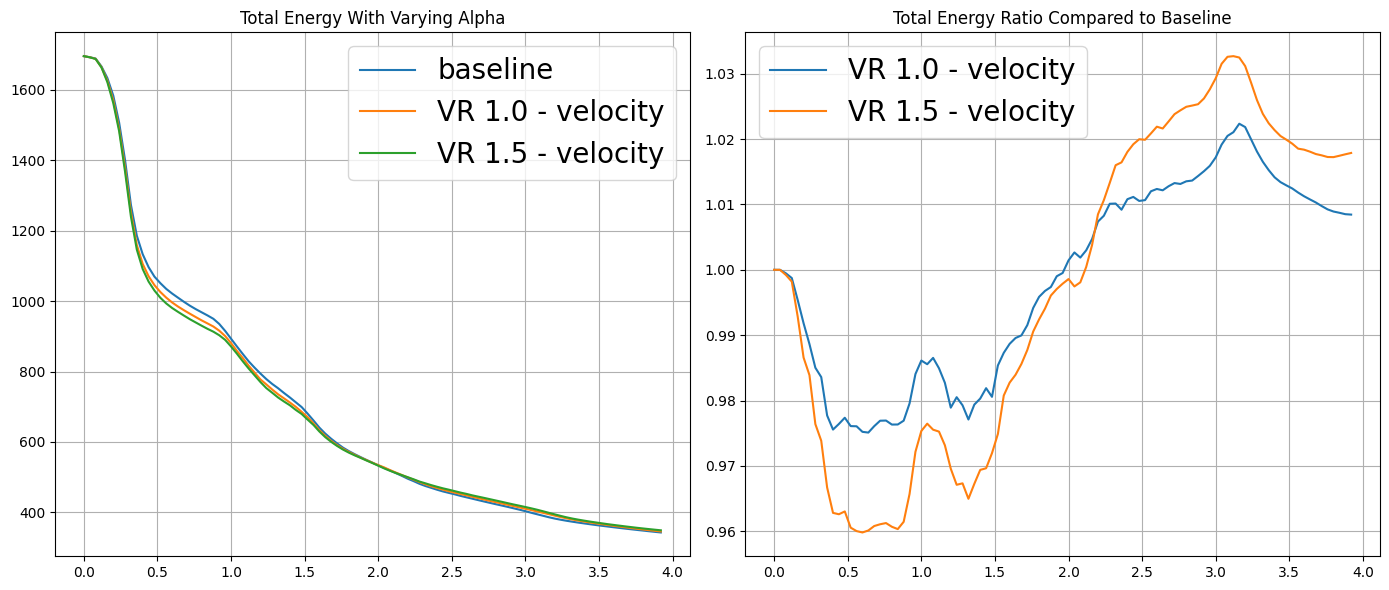

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 100
time = [i / 25 for i in range(99)]

for folder in ['baseline', 'VR 1.0 - velocity', 'VR 1.5 - velocity']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum(mass * (norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     ax1.plot(kin_energy, label="{}".format(folder))
    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")


kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum(mass *(norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

for folder in ['VR 1.0 - velocity', 'VR 1.5 - velocity']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax2.plot(time, total_energy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()    # neat spacing
plt.show()

In [30]:
## distribution of velocities - not relevant
# import os
# import numpy as np
# import meshio
# import matplotlib.pyplot as plt
# from numpy.linalg import norm
# from scipy.stats import gaussian_kde

# plt.figure(figsize=(8, 6))

# begin = 25
# end = 26

# # Collect all data to find global velocity range
# all_vel = []

# for folder in ['baseline', 'VR 1.0 - velocity', 'VR 1.5 - velocity']:
#     full_path = folder_path + folder + '/'
#     total = 0
#     for i in range(begin, end):
#         file = f'ParticleData_Fluid_{i}.vtk'
#         mesh = meshio.read(full_path + file)
#         velocity = mesh.point_data['velocity']
#         vel = norm(velocity, axis=1)   # <-- use velocity magnitude (not squared)
#         total += np.sum(vel)
#         all_vel.extend(vel)
        
#     print(folder)
#     print(total)
        

# # Define shared range for smooth plots
# x_vals = np.linspace(np.min(all_vel), np.max(all_vel), 500)

# # Plot smooth distributions
# for folder in ['baseline', 'VR 1.0 - velocity', 'VR 1.5 - velocity']:
#     full_path = folder_path + folder + '/'
#     vel_all = []

#     for i in range(begin, end):
#         file = f'ParticleData_Fluid_{i}.vtk'
#         mesh = meshio.read(full_path + file)
#         velocity = mesh.point_data['velocity']
#         vel = norm(velocity, axis=1)
#         vel_all.extend(vel)

#     # KDE: smooth probability density estimate
#     kde = gaussian_kde(vel_all, bw_method=0.2)  # you can tune bw_method for smoothness
#     plt.plot(x_vals, kde(x_vals), label=folder, linewidth=2)

# # Format plot
# plt.legend(fontsize=14)
# plt.grid(True)
# plt.xlabel("Velocity magnitude")
# plt.ylabel("Probability density")
# plt.title("Velocity Distribution Comparison (Smoothed)")
# plt.tight_layout()
# plt.show()


## Linear X Rotational Field

Linear - no vorticity - no correction
2 Particles same direction different velocities
2 particles opposite velocity

In [39]:
scene = 'shearflow'

folder_path = splishsplash_path + '/' + scene + '/viscfluid0.01/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//shearflow/viscfluid0.01/
['alpha 1.0 visc 0.01', 'alpha 1.0 visc 0.0', 'alpha 1.5 visc 0.01', 'alpha 1.5 visc 0.0', 'baseline']


C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in float_scalars


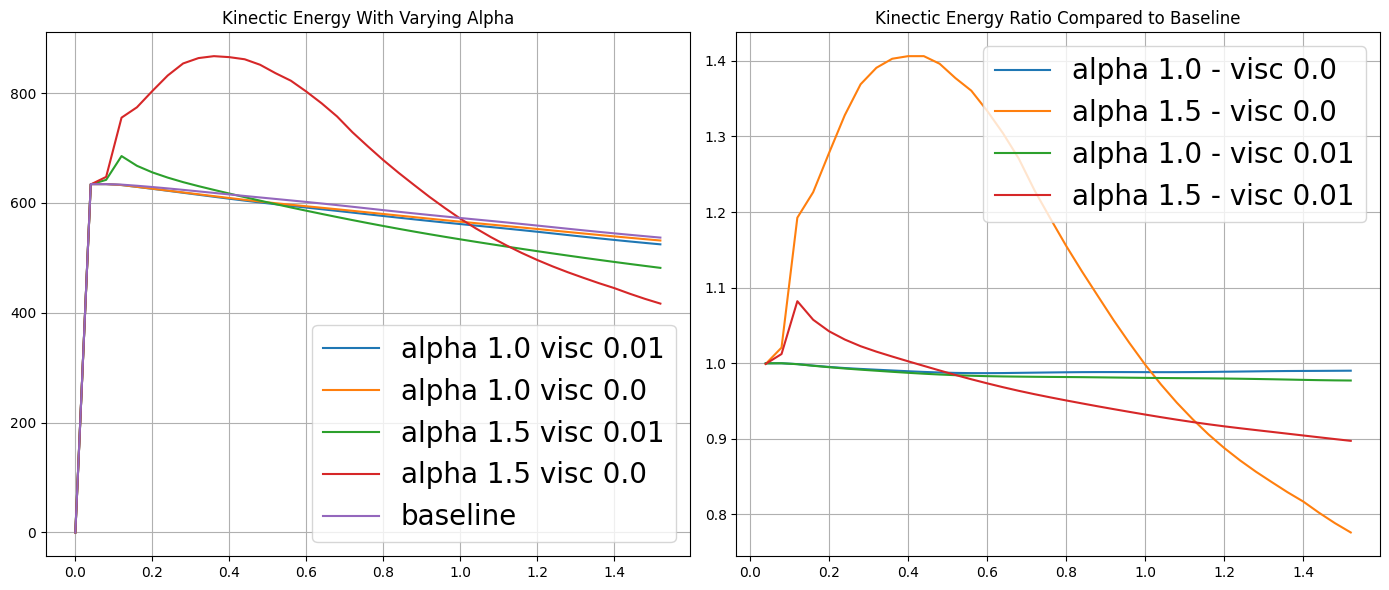

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 40
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
#             aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
#             ls_total_energy.append((aux_pot_energy + aux_kin_energy))
            ls_total_energy.append((aux_kin_energy))
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
    ax1.plot(time, ls_total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Kinectic Energy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 visc 0.0'], total_energy['baseline'])], label="alpha 1.0 - visc 0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.5 visc 0.0'], total_energy['baseline'])], label="alpha 1.5 - visc 0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 visc 0.01'], total_energy['baseline'])], label="alpha 1.0 - visc 0.01")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.5 visc 0.01'], total_energy['baseline'])], label="alpha 1.5 - visc 0.01")

ax2.legend(fontsize=20)
ax2.grid(True)
ax2.set_title("Kinectic Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


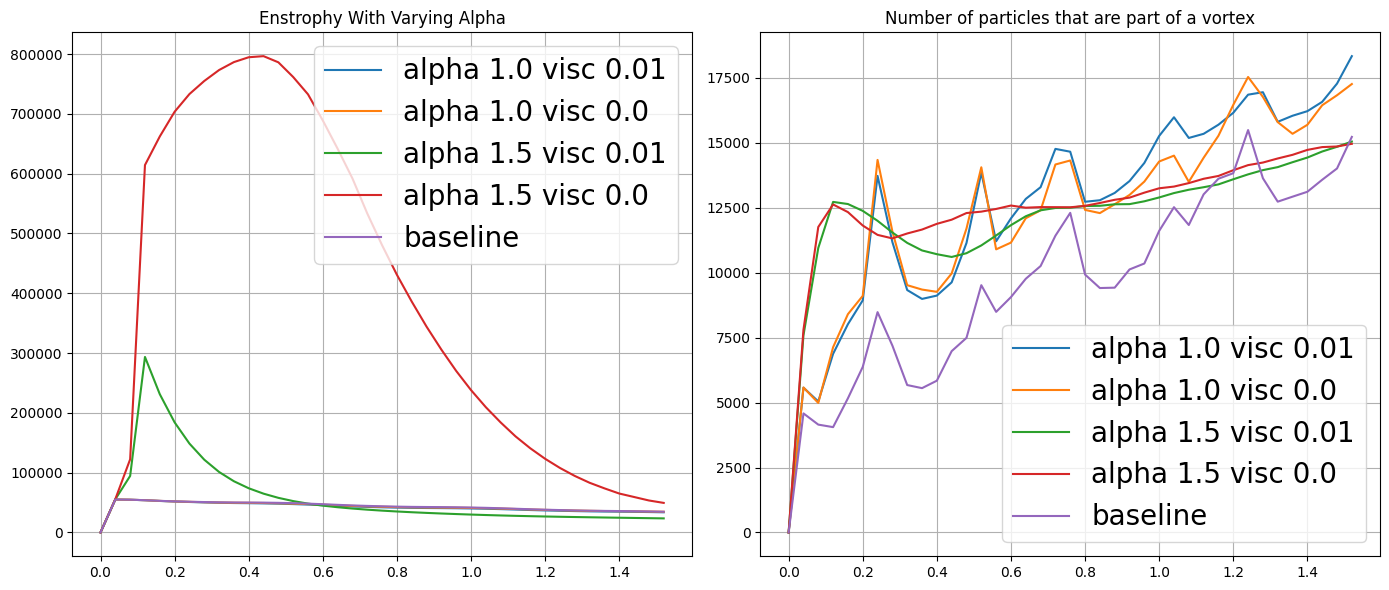

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 40
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    is_vortex = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
            
            is_vortex.append(np.count_nonzero(mesh.point_data['m_is_vortex']))
        else:
            enstrophy.append(0)
            is_vortex.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder))
    ax2.plot(time, is_vortex, label="{}".format(folder))

ax1.legend(fontsize=20)
ax1.grid(True)
ax1.set_title("Enstrophy With Varying Alpha")

ax2.legend(fontsize=20)
ax2.grid(True)
ax2.set_title("Number of particles that are part of a vortex")

plt.tight_layout()

plt.show()

In [42]:
scene = 'rotationalflow'

folder_path = splishsplash_path + '/' + scene + '/viscfluid0.01/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//rotationalflow/viscfluid0.01/
['baseline', 'alpha 1.0 visc 0.0', 'alpha 1.3 visc 0.0', 'alpha 1.0 visc 0.01', 'alpha 1.3 visc 0.01']


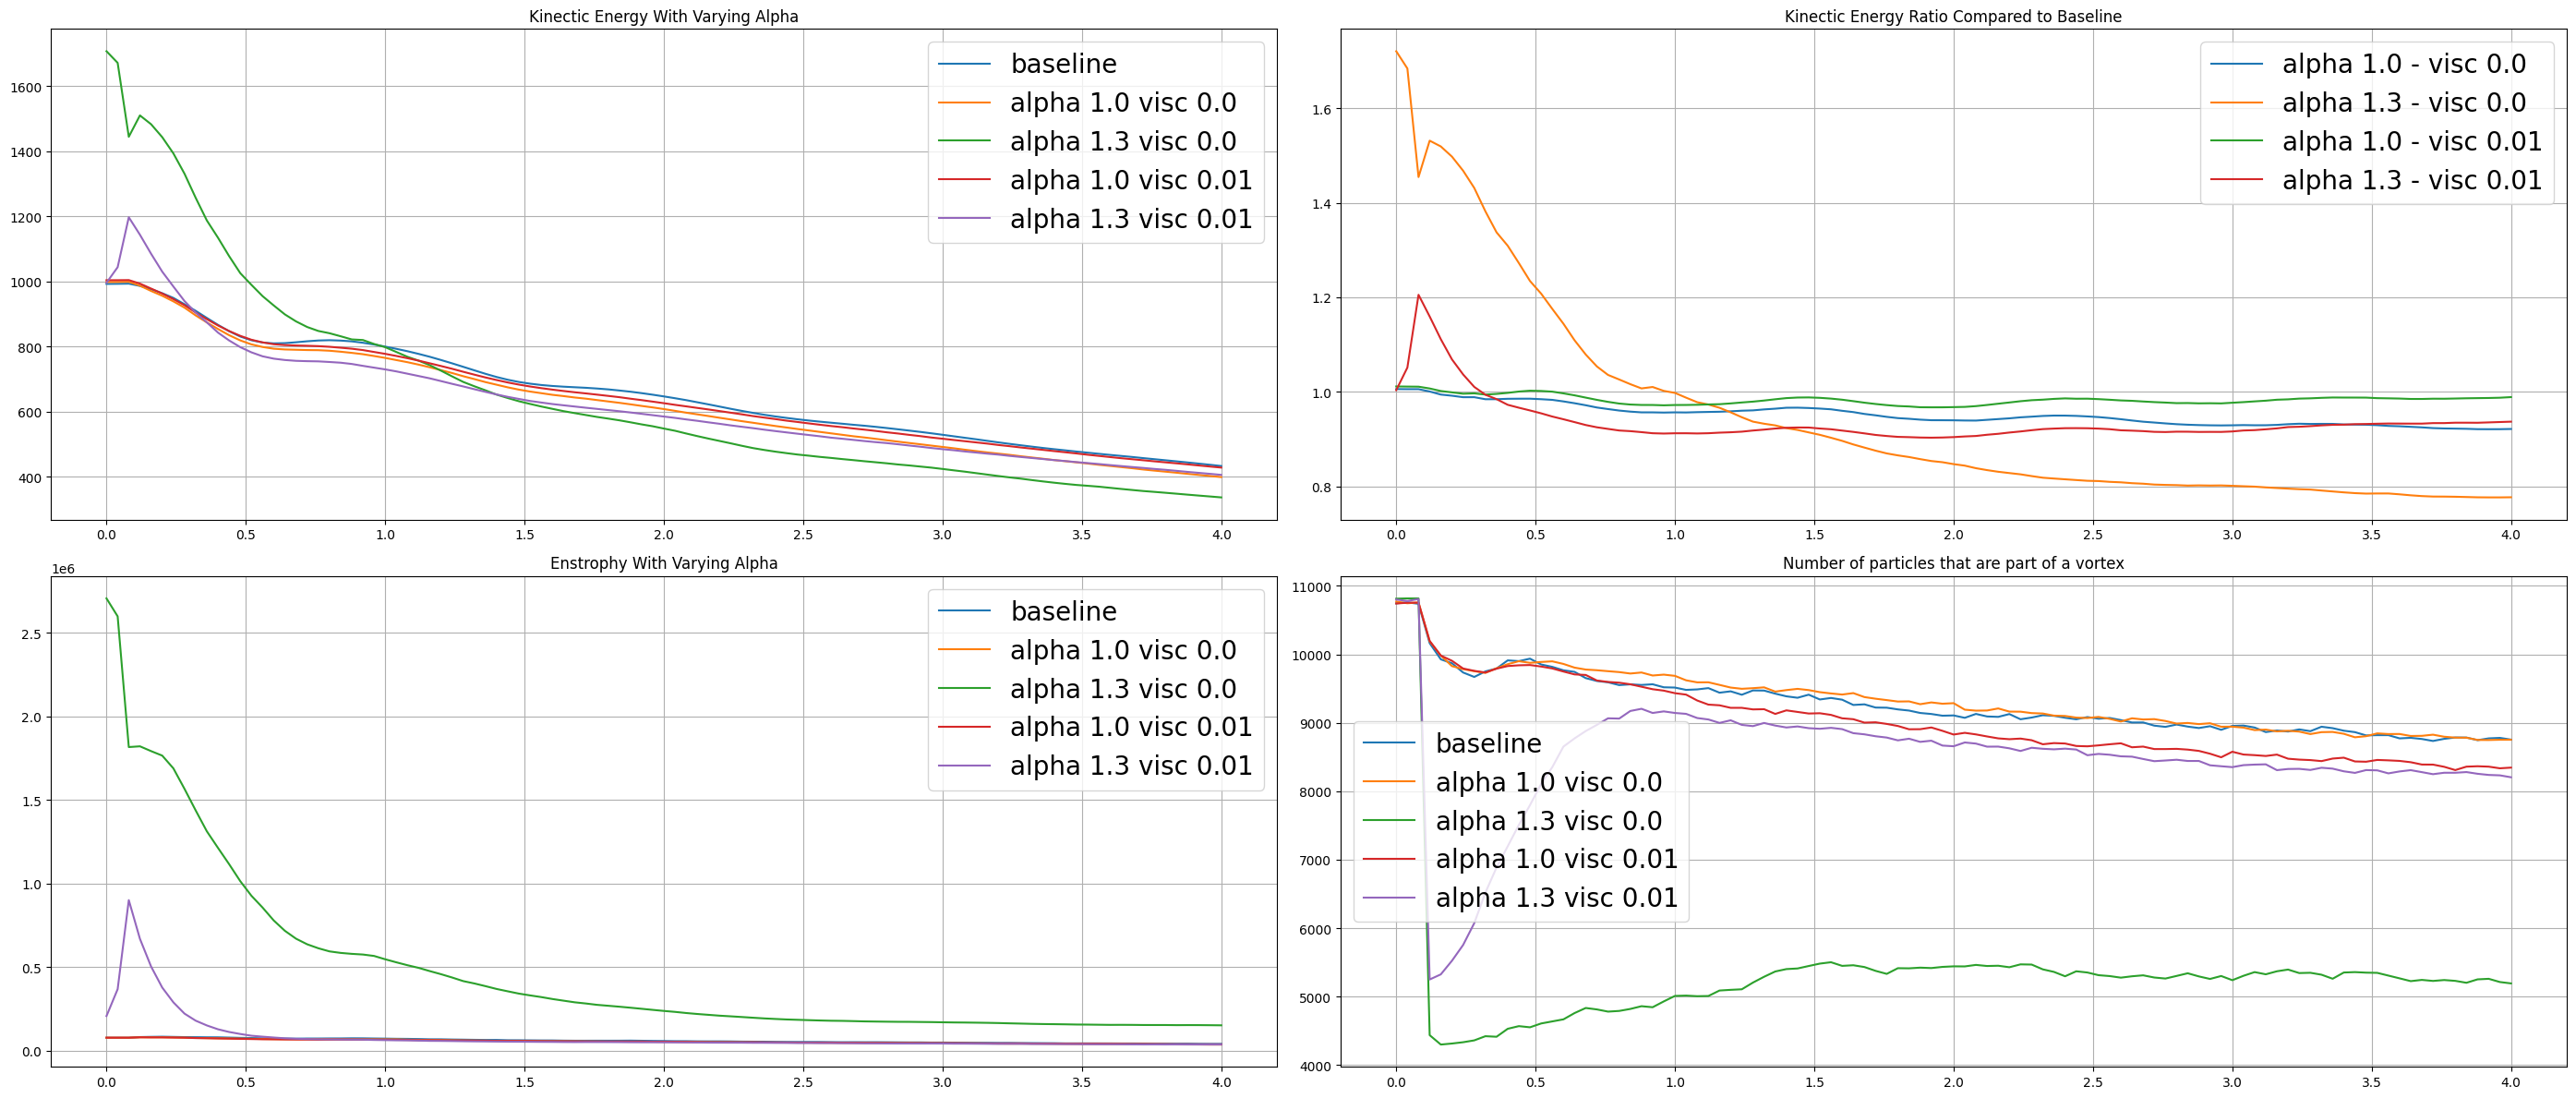

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(28, 12)) 
ax1, ax2, ax3, ax4 = axes.flatten()

begin = 74
end = 7*25
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    is_vortex = []
    
    ls_total_energy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
#             aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
#             ls_total_energy.append((aux_pot_energy + aux_kin_energy))
            ls_total_energy.append((aux_kin_energy))
    
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
            
            is_vortex.append(np.count_nonzero(mesh.point_data['m_is_vortex']))
#         else:
#             ls_total_energy.append(0)
            
    ax3.plot(time, enstrophy, label="{}".format(folder))
    ax4.plot(time, is_vortex, label="{}".format(folder))
    total_energy[folder] = ls_total_energy
    ax1.plot(time, ls_total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Kinectic Energy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 visc 0.0'], total_energy['baseline'])], label="alpha 1.0 - visc 0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.3 visc 0.0'], total_energy['baseline'])], label="alpha 1.3 - visc 0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 visc 0.01'], total_energy['baseline'])], label="alpha 1.0 - visc 0.01")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.3 visc 0.01'], total_energy['baseline'])], label="alpha 1.3 - visc 0.01")

ax2.legend(fontsize=20)
ax2.grid(True)
ax2.set_title("Kinectic Energy Ratio Compared to Baseline")

ax3.legend(fontsize=20)
ax3.grid(True)
ax3.set_title("Enstrophy With Varying Alpha")

ax4.legend(fontsize=20)
ax4.grid(True)
ax4.set_title("Number of particles that are part of a vortex")

plt.tight_layout()

plt.show()

## Understanding the Effects of the Stretching Term

In [66]:
scene = 'DamBreakModel'
folder_path = splishsplash_path + '/' + scene + '/inviscid with xsph 0.001/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModel/inviscid with xsph 0.001/
['VR 1.0 - velocity', 'VR 1.5 - velocity', 'baseline']


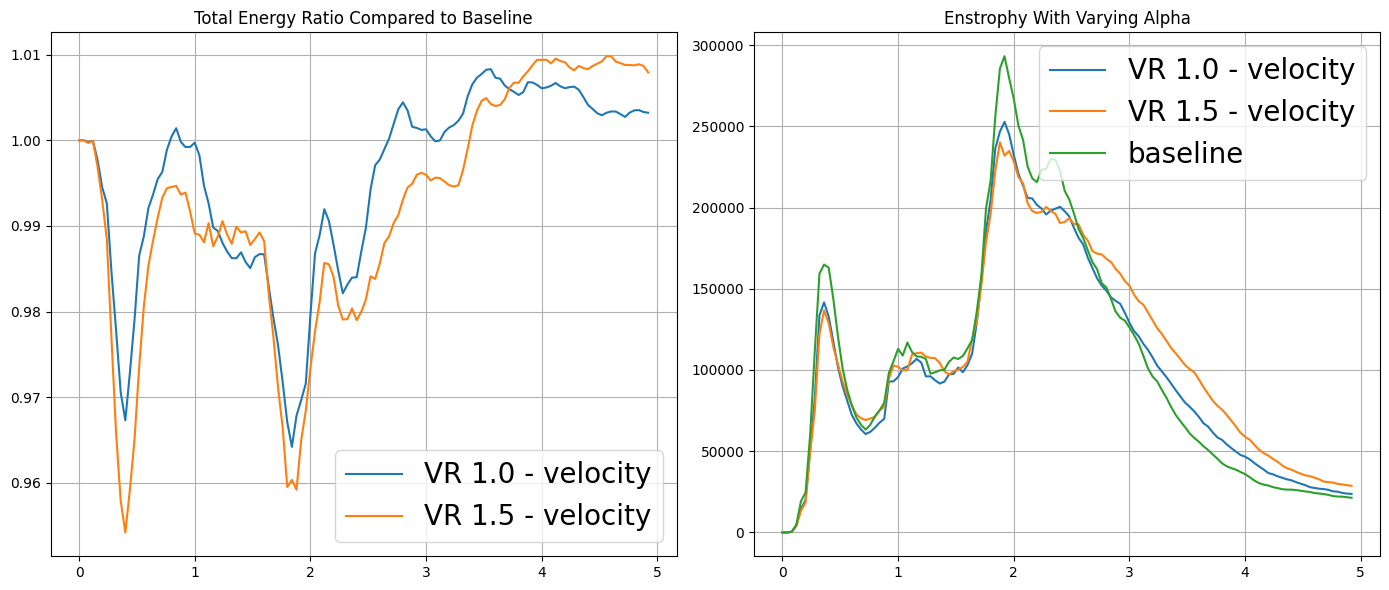

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 125
time = [i / 25 for i in range(124)]

kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

for folder in ['VR 1.0 - velocity', 'VR 1.5 - velocity']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy Ratio Compared to Baseline")


for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax2.plot(time, enstrophy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Enstrophy With Varying Alpha")


plt.tight_layout()    # neat spacing

plt.show()

In [108]:
scene = 'DamBreakModelWithWall'
# fluid 0.02
# visc no method 0.0 - only stretching term working
# different values of alpha
folder_path = splishsplash_path + '/' + scene + '/visc_standard_002_fluid_stretching_term/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModelWithWall/visc_standard_002_fluid_stretching_term/
['baseline', 'alpha 1.0', 'alpha 1.5']


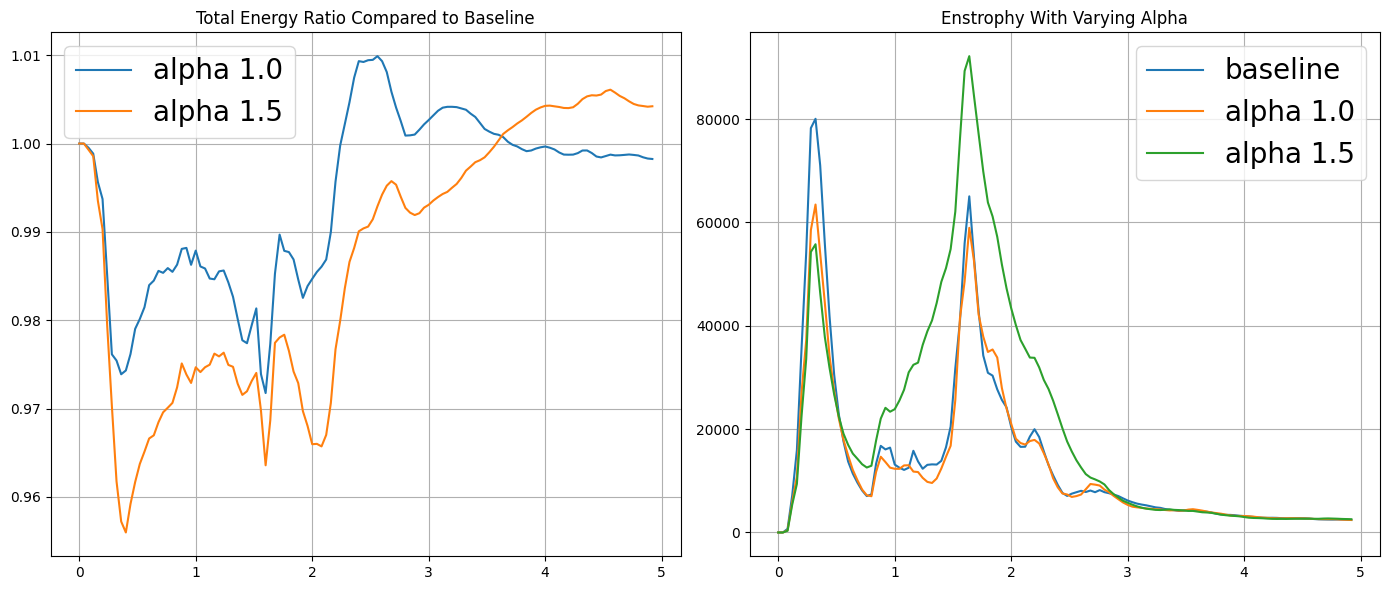

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 125
time = [i / 25 for i in range(124)]

kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

for folder in ['alpha 1.0', 'alpha 1.5']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy Ratio Compared to Baseline")


for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax2.plot(time, enstrophy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Enstrophy With Varying Alpha")


plt.tight_layout()    # neat spacing

plt.show()

In [113]:
scene = 'DamBreakModelWithWall'
folder_path = splishsplash_path + '/' + scene + '/inviscid with xsph 0.001_visc_with_method/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModelWithWall/inviscid with xsph 0.001_visc_with_method/
['baseline', 'VR 1.5 - velocity', 'VR 1.0 - velocity']


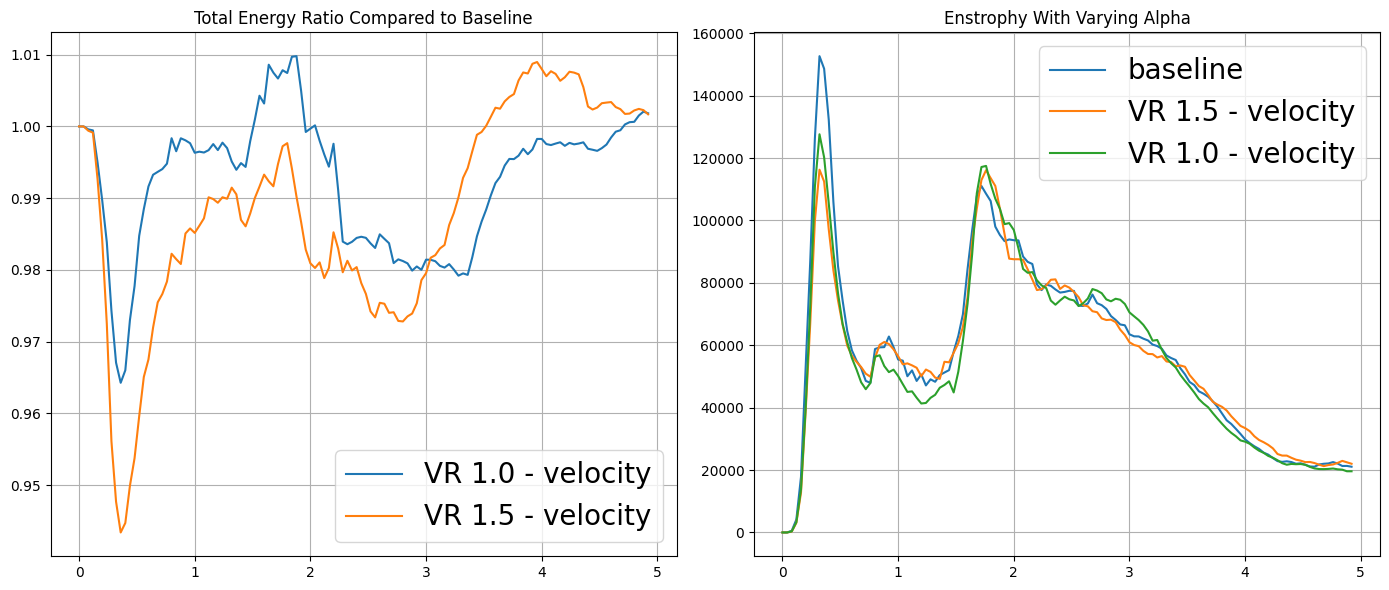

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 125
time = [i / 25 for i in range(end - begin)]

kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

for folder in ['VR 1.0 - velocity', 'VR 1.5 - velocity']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy Ratio Compared to Baseline")


for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax2.plot(time, enstrophy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Enstrophy With Varying Alpha")


plt.tight_layout()    # neat spacing

plt.show()

## Understanding the Effects of the Diffusion Term

In [ ]:
# For a Dam Break and TGV - for a fluid with Visc 0.02 and for alpha = 1.0. We see how much the vorticity 
# changes when varying the viscosity coefficient on the method
# Values for v_v on the method: 0.01, 0.03, 0.05

In [93]:
scene = 'DamBreakModelWithWall'

folder_path = splishsplash_path + '/' + scene + '/testing_difusion_term_alpha 1.0/visc_dettached_from_method/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)

folders.remove('baseline')
print(folders)

D:/gabi//DamBreakModelWithWall/testing_difusion_term_alpha 1.0/visc_dettached_from_method/
['0.05', '0.02', '0.01', 'baseline', '0.00']
['0.05', '0.02', '0.01', '0.00']


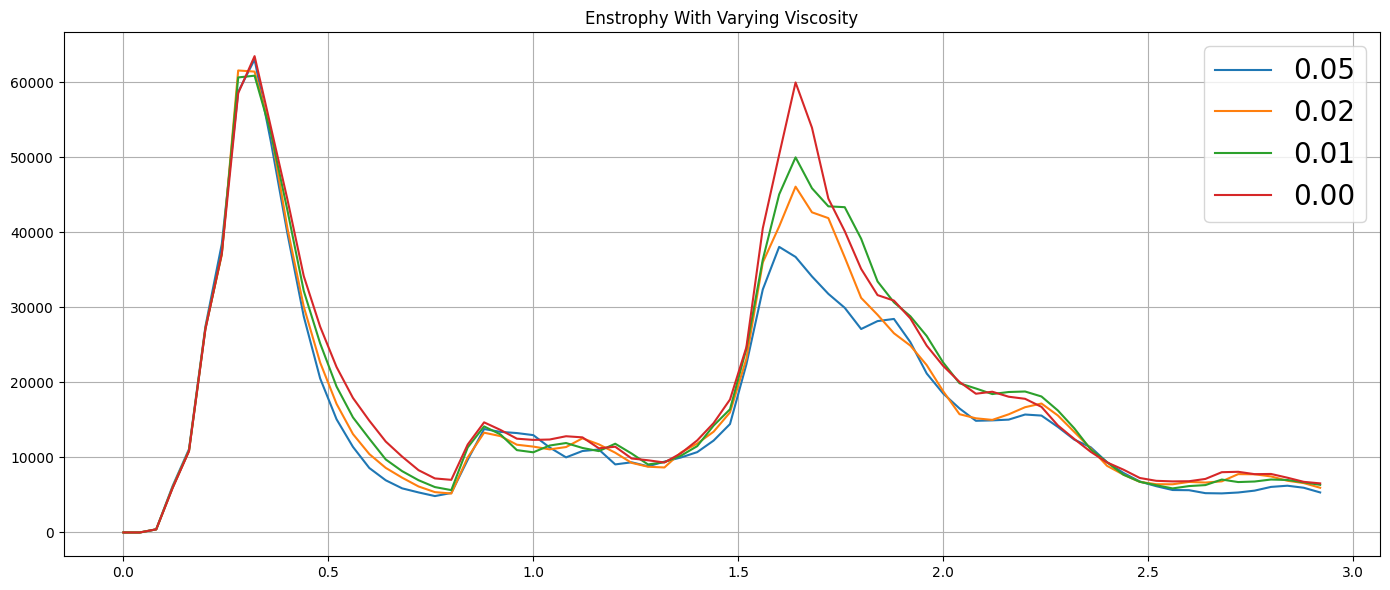

In [98]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1 = axes 

begin = 1
end = 75
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Enstrophy With Varying Viscosity")

plt.tight_layout()    # neat spacing

plt.show()

In [60]:
scene = 'DamBreakModelWithWallMoreFluid'

folder_path = splishsplash_path + '/' + scene + '/visc fluid 0.02/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)


D:/gabi//DamBreakModelWithWallMoreFluid/visc fluid 0.02/
['baseline', '0.05']


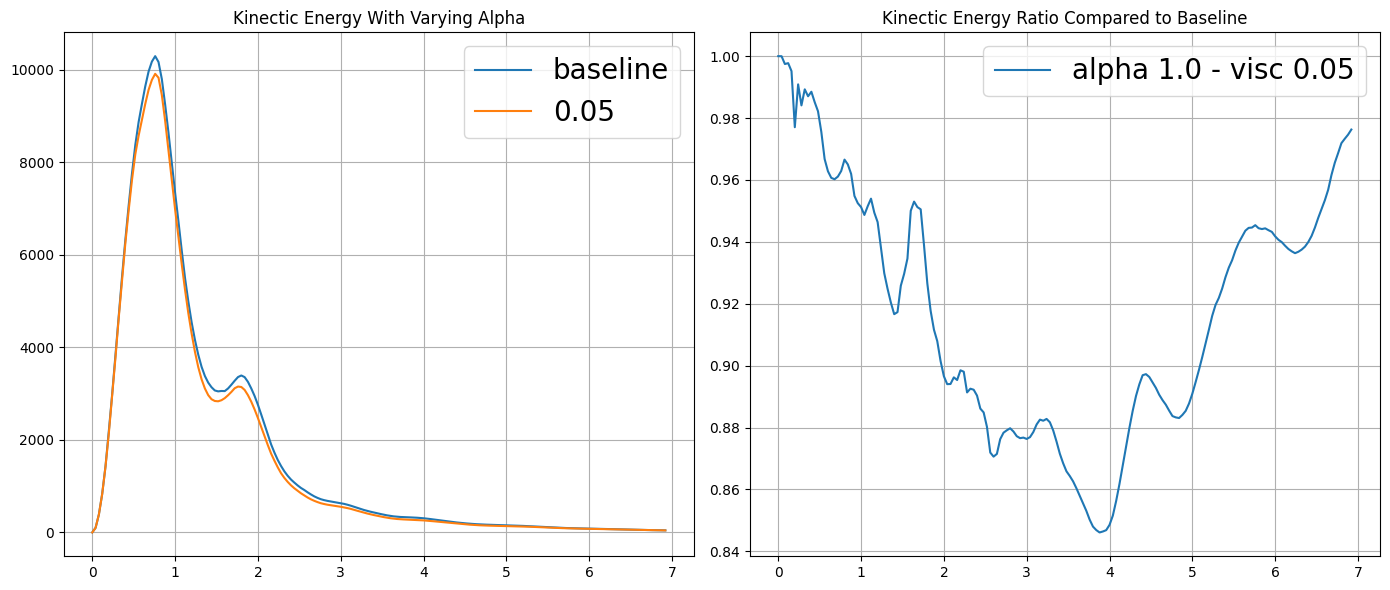

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 175
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
#             aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
#             ls_total_energy.append((aux_pot_energy + aux_kin_energy))
            ls_total_energy.append((aux_kin_energy))
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
    ax1.plot(time, ls_total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Kinectic Energy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['0.05'], total_energy['baseline'])], label="alpha 1.0 - visc 0.05")

ax2.legend(fontsize=20)
ax2.grid(True)
ax2.set_title("Kinectic Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


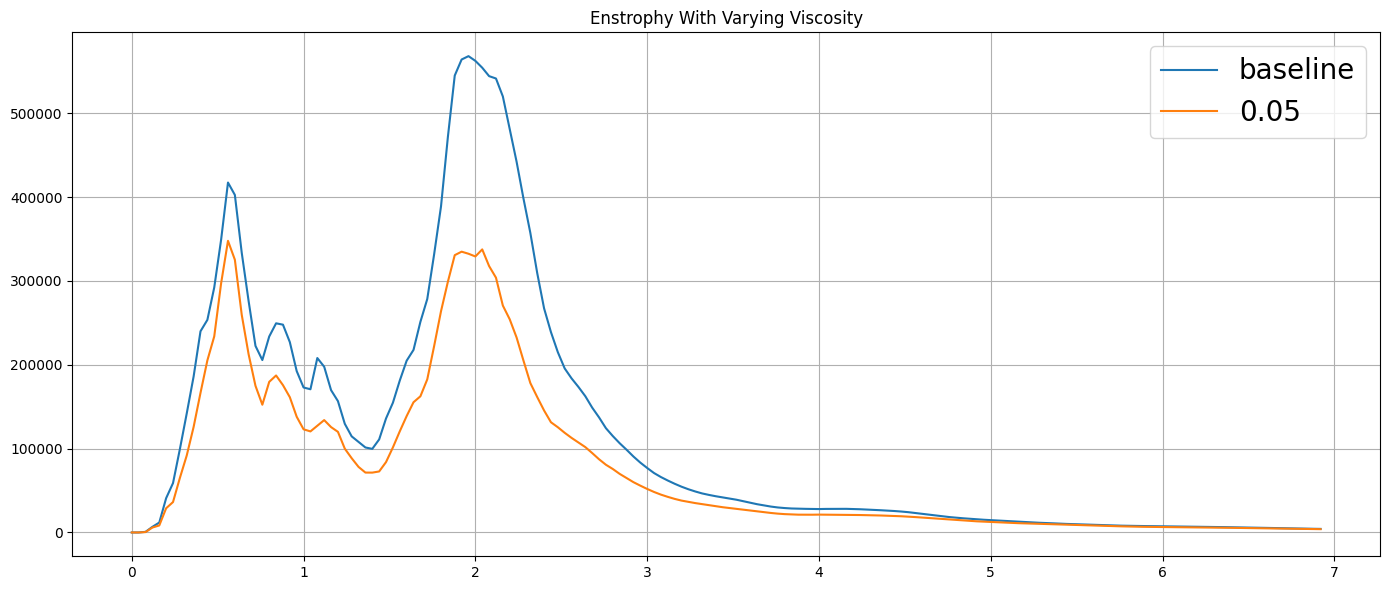

In [63]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1 = axes 

begin = 1
end = 175
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Enstrophy With Varying Viscosity")

plt.tight_layout()    # neat spacing

plt.show()

In [100]:
scene = 'tgv3dnogravity'

folder_path = splishsplash_path + '/' + scene + '/testing_diffusion_term_alpha_1/fluid_visc_002/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)

folders.remove('baseline')
print(folders)

D:/gabi//tgv3dnogravity/testing_diffusion_term_alpha_1/fluid_visc_002/
['0.02', '0.05', 'baseline', '0.00']
['0.02', '0.05', '0.00']


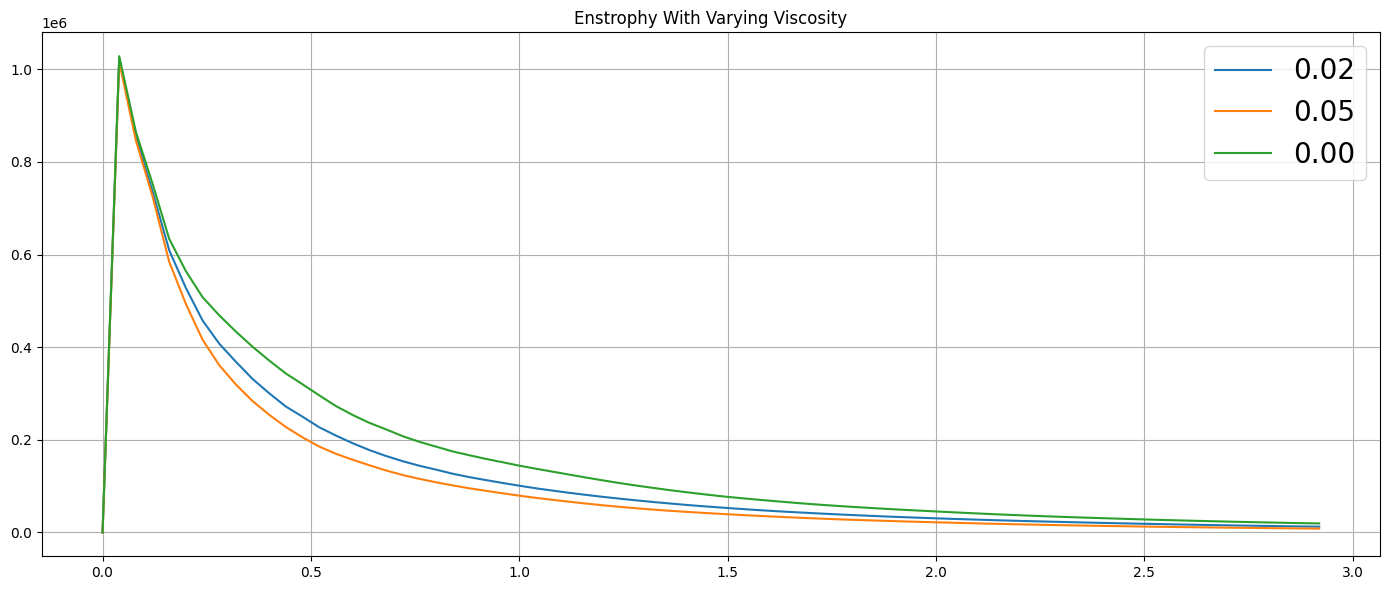

In [101]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1 = axes 

begin = 1
end = 75
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Enstrophy With Varying Viscosity")

plt.tight_layout()    # neat spacing

plt.show()

In [ ]:
# fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
# ax1 = axes 

# begin = 4
# end = 175
# time = [i / 25 for i in range(end - begin)]

# total_energy = {}
    
# for folder in folders:
#     full_path = folder_path + folder + '/'
#     files = os.listdir(full_path)
    
#     ls_total_energy = []
#     for i in range(begin,end):
#         file = 'ParticleData_Fluid_{}.vtk'.format(i)

#         mesh = meshio.read(full_path + file)
#         positions = mesh.points

#         h = mesh.points[:,1]
#         velocity = mesh.point_data['velocity']
#         mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

#         number_particles = len(h)
#         if number_particles > 0:
#             aux_pot_energy = np.sum(mass * h * 9.81)            
#             aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
#             ls_total_energy.append((aux_pot_energy + aux_kin_energy))
#         else:
#             ls_total_energy.append(0)
            
#     total_energy[folder] = ls_total_energy

# ax1.plot(time, [x / y for x, y in zip(total_energy['0.05'], total_energy['0.00'])], label="0.05")
# ax1.plot(time, [x / y for x, y in zip(total_energy['0.02'], total_energy['0.00'])], label="0.02")
# # ax1.plot(time, [x / y for x, y in zip(total_energy['0.01'], total_energy['0.00'])], label="0.01")
# # ax1.plot(time, [x / y for x, y in zip(total_energy['0.00'], total_energy['baseline'])], label="0.00")
# # ax1.plot(time, [x / y for x, y in zip(total_energy['inviscid'], total_energy['baseline inviscid'])], label="inviscid")


# ax1.legend(fontsize=20)          # show the labels
# ax1.grid(True)        # optional grid
# ax1.set_title("For alpha 1.0, Total Energy Ratio Compared to Baseline with Vayring Viscosity Coefficient")


# for folder in folders:
#     full_path = folder_path + folder + '/'
#     files = os.listdir(full_path)
    
#     enstrophy = []
    
#     for i in range(begin,end):
#         file = 'ParticleData_Fluid_{}.vtk'.format(i)

#         mesh = meshio.read(full_path + file)
#         positions = mesh.points

#         vorticity = mesh.point_data['vorticity_corrected_end']
#         mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

#         number_particles = len(h)
#         if number_particles > 0:           
#             aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
#             enstrophy.append(aux_kin_ens)
#         else:
#             enstrophy.append(0)

#     ax1.plot(time, enstrophy, label="{}".format(folder))

# ax1.legend(fontsize=20)          # show the labels
# ax1.grid(True)        # optional grid
# ax1.set_title("Enstrophy With Varying Viscosity")

# plt.tight_layout()    # neat spacing

# plt.show()

## Influence of System Size and Initial Vorticity Level on Vorticity Dynamics  

In [135]:
scene = 'EmitterLarge'
folder_path = splishsplash_path + '/' + scene + '/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//EmitterLarge/
['VR 1.0', 'baseline']


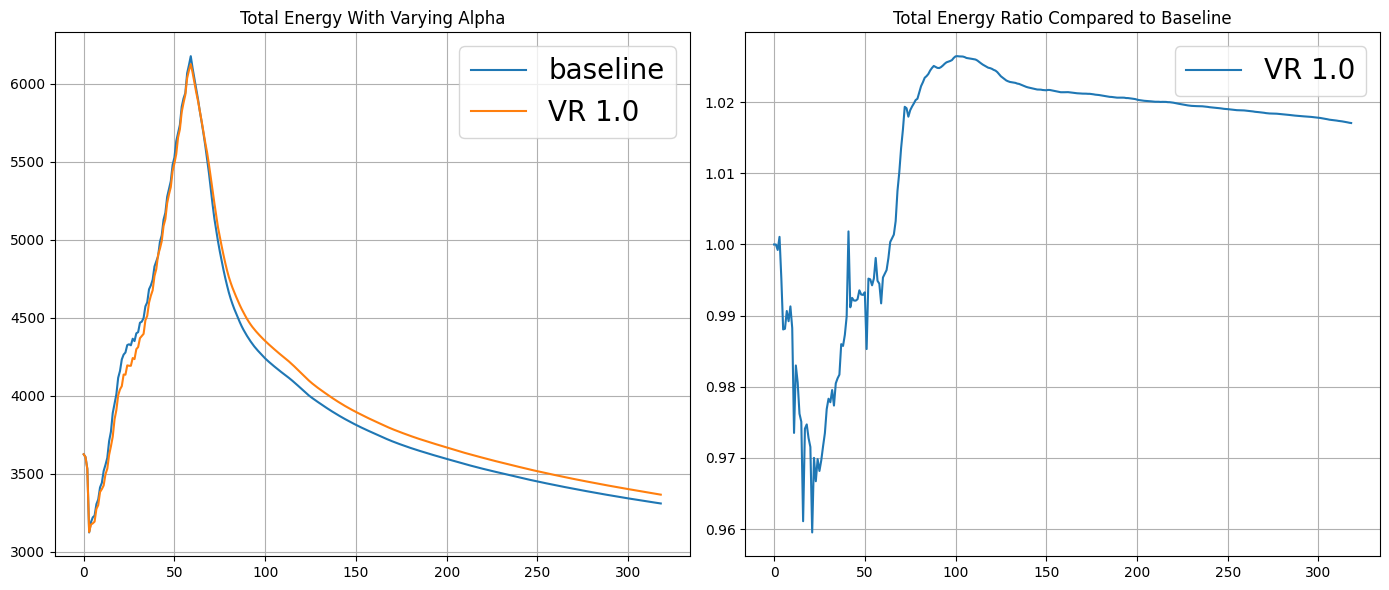

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 320
fps=1
time = [i / fps for i in range(end - begin)]

# for folder in folders:
for folder in ['baseline','VR 1.0']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")


kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

# for folder in folders:
for folder in ['VR 1.0']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax2.plot(time, total_energy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()    # neat spacing
plt.show()

## Visual Evaluation of the Turbulence Details

## Testing Different Advection-Projection Methods

In [91]:
scene = 'DamBreakModel'
folder_path = splishsplash_path + '/' + scene
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModel
['dfsph_inviscid_advected_velocity_for_derivative', 'dfsph_inviscid_derivative_beginning', 'dfsph_visc_forces', 'dfsph_visc_standard_005_advected_velocity_for_derivative', 'dfsph_visc_standard_005_derivative_beginning', 'iisph_visc_standard_005', 'inviscid', 'log', 'pcisph_visc_standard_005', 'visc_standard_005', 'inviscid with xsph 0.001', 'testing_difusion_term_alpha 1.0']


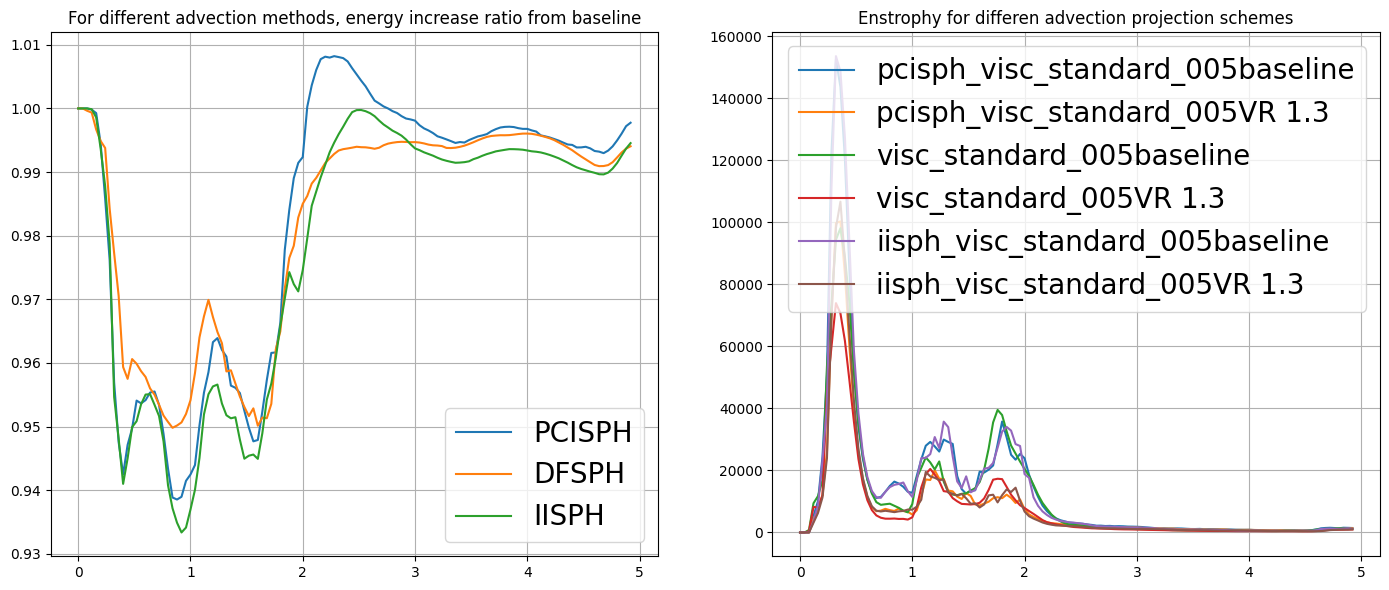

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 125
time = [i / 25 for i in range(124)]

total_energy = {}
    
for folder in ['pcisph_visc_standard_005', 'visc_standard_005', 'iisph_visc_standard_005']:
    main_folder_path = folder_path + '/' + folder + '/'
    for subfolder in ['baseline', 'VR 1.3']:
        child_folder_path = main_folder_path + subfolder + '/'
        files = os.listdir(full_path)

        ls_total_energy = []
        for i in range(begin,end):
            file = 'ParticleData_Fluid_{}.vtk'.format(i)

            mesh = meshio.read(child_folder_path + file)
            positions = mesh.points

            h = mesh.points[:,1]
            velocity = mesh.point_data['velocity']
            mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

            number_particles = len(h)
            if number_particles > 0:
                aux_pot_energy = np.sum(mass * h * 9.81)            
                aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
                ls_total_energy.append((aux_pot_energy + aux_kin_energy))
            else:
                ls_total_energy.append(0)

        total_energy[folder + '_' + subfolder] = ls_total_energy

# print(total_energy.keys())
ax1.plot(time, [x / y for x, y in zip(total_energy['pcisph_visc_standard_005_VR 1.3'], total_energy['pcisph_visc_standard_005_baseline'])], label="PCISPH")
ax1.plot(time, [x / y for x, y in zip(total_energy['visc_standard_005_VR 1.3'], total_energy['visc_standard_005_baseline'])], label="DFSPH")
ax1.plot(time, [x / y for x, y in zip(total_energy['iisph_visc_standard_005_VR 1.3'], total_energy['iisph_visc_standard_005_baseline'])], label="IISPH")

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("For different advection methods, energy increase ratio from baseline")



for folder in ['pcisph_visc_standard_005', 'visc_standard_005', 'iisph_visc_standard_005']:
    main_folder_path = folder_path + '/' + folder + '/'
    for subfolder in ['baseline', 'VR 1.3']:
        child_folder_path = main_folder_path + subfolder + '/'
        files = os.listdir(full_path)
    
        enstrophy = []

        for i in range(begin,end):
            file = 'ParticleData_Fluid_{}.vtk'.format(i)

            mesh = meshio.read(child_folder_path + file)
            positions = mesh.points

            vorticity = mesh.point_data['vorticity_corrected_end']
            mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

            number_particles = len(h)
            if number_particles > 0:           
                aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
                enstrophy.append(aux_kin_ens)
            else:
                enstrophy.append(0)

        ax2.plot(time, enstrophy, label="{}".format(folder + subfolder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Enstrophy for differen advection projection schemes")



plt.tight_layout()    # neat spacing

plt.show()

## Analysis on the Explicit Integration of Vorticity

In [116]:
scene = 'DamBreakModel'
folder_path = splishsplash_path + '/' + scene + '/visc_standard_005/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//DamBreakModel/visc_standard_005/
['baseline', 'mp_01', 'mp_04', 'vc_01', 'vc_05', 'vr -1.0', 'VR 1.0', 'VR 1.3', 'VR 1.5', 'VR 1.3 - deivative beginning', 'baseline -derivative beginning']


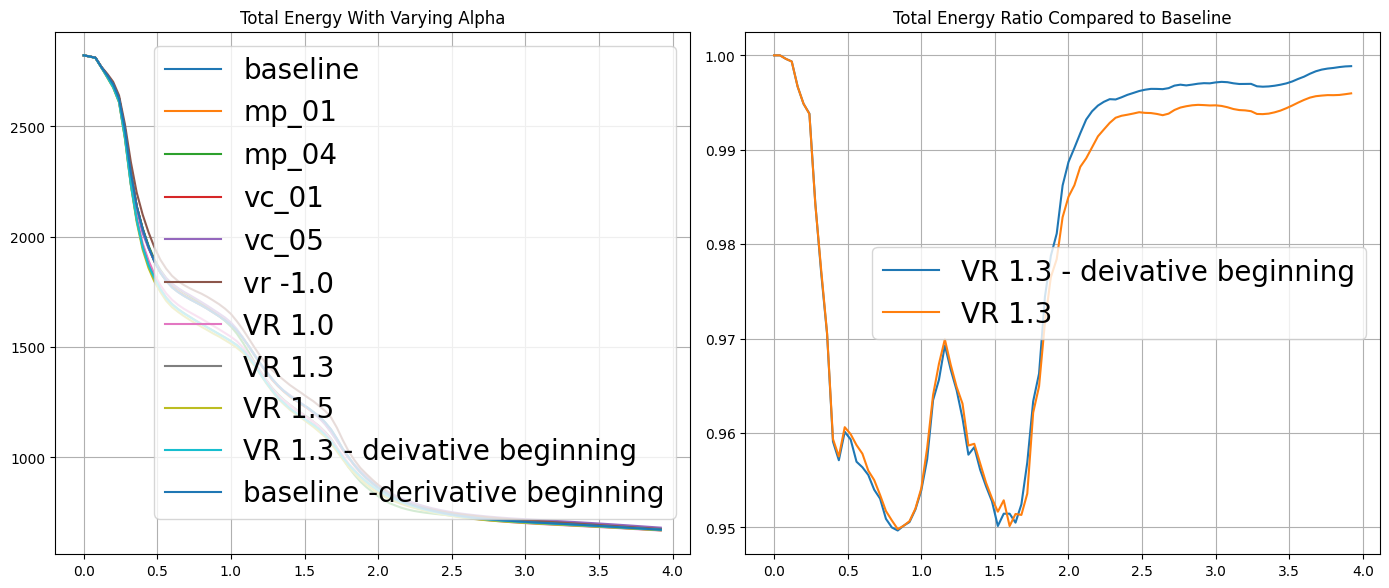

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 100
time = [i / 25 for i in range(99)]

for folder in folders:
# for folder in ['baseline','VR 1.0', 'VR 1.3',  'VR 1.5']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")


kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

# for folder in folders:
for folder in ['VR 1.3 - deivative beginning','VR 1.3']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax2.plot(time, total_energy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()    # neat spacing
plt.show()

In [110]:
scene = 'Emitter/visc0.01/'
folder_path = splishsplash_path + '/' + scene
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

D:/gabi//Emitter/visc0.01/
['baseline', 'vr1.0', 'vr 1.3 derivative beginning', 'baseline - derivative beginning', 'vr 1.0 derivative beginning']


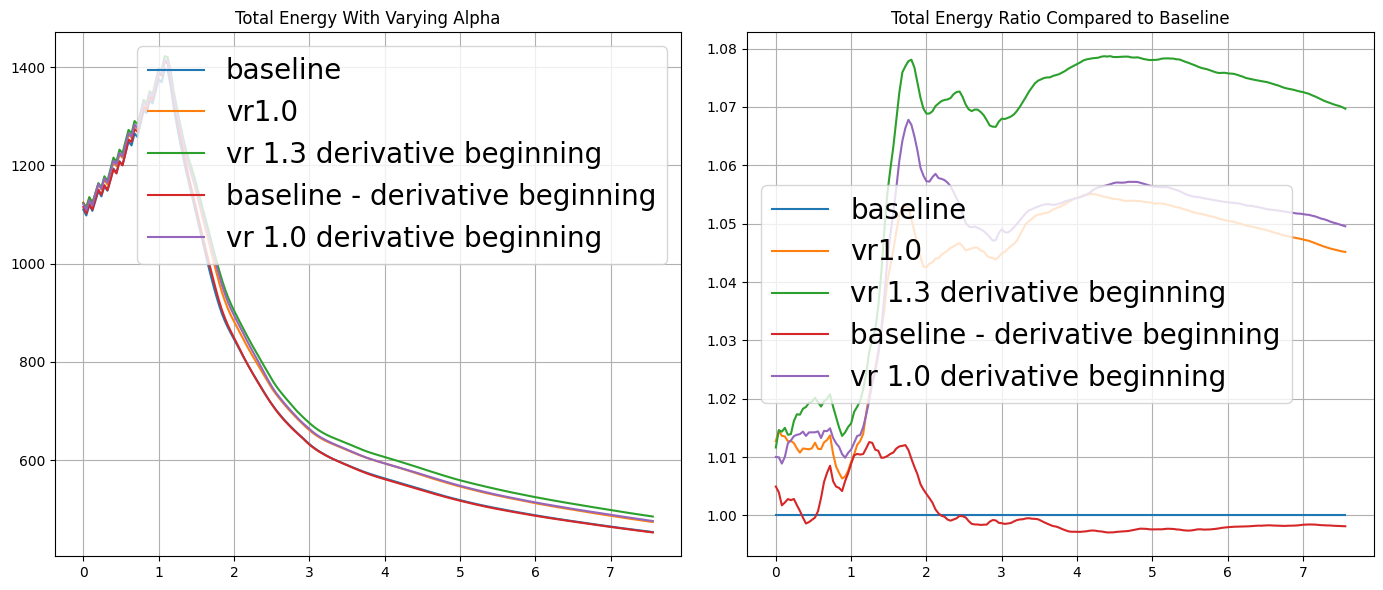

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 60
end = 250
time = [i / 25 for i in range(190)]

for folder in folders:
# for folder in ['baseline','VR 1.0', 'VR 1.3',  'VR 1.5']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    ax1.plot(time, total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")


kin_energy_baseline = []
pot_energy_baseline = []
total_energy_baseline = []
    
for folder in ['baseline']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            total_energy_baseline.append((aux_pot_energy + aux_kin_energy))
        else:
            total_energy_baseline.append(0)

# for folder in folders:
for folder in ['baseline', 'vr1.0', 'vr 1.3 derivative beginning', 'baseline - derivative beginning', 'vr 1.0 derivative beginning']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)
            total_energy.append((aux_pot_energy + aux_kin_energy)/total_energy_baseline[i-begin])
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

    ax2.plot(time, total_energy, label="{}".format(folder))

ax2.legend(fontsize=20)          # show the labels
ax2.grid(True)        # optional grid
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()    # neat spacing
plt.show()

## Analysis of Energy Cascade

In [19]:
scene = 'TGV3DNoGravity'

folder_path = splishsplash_path + '/' + scene + '/viscfluid0.01/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)

# folders.remove('baseline')
print(folders)

D:/gabi//TGV3DNoGravity/viscfluid0.01/
['alpha 1.0 - visc 0.0', 'alpha 1.3 - visc 0.0', 'alpha 1.0 - visc 0.01', 'alpha 1.3 - visc 0.01', 'alpha 1.0 - visc 0.05', 'baseline', 'alpha 1.3 - visc 0.05']
['alpha 1.0 - visc 0.0', 'alpha 1.3 - visc 0.0', 'alpha 1.0 - visc 0.01', 'alpha 1.3 - visc 0.01', 'alpha 1.0 - visc 0.05', 'baseline', 'alpha 1.3 - visc 0.05']


C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:45: RuntimeWarning: invalid value encountered in float_scalars
C:\Users\gabri\anaconda3\envs\venv\lib\site-packages\ipykernel_launcher.py:46: RuntimeWarning: invalid value encountered in float_scalars


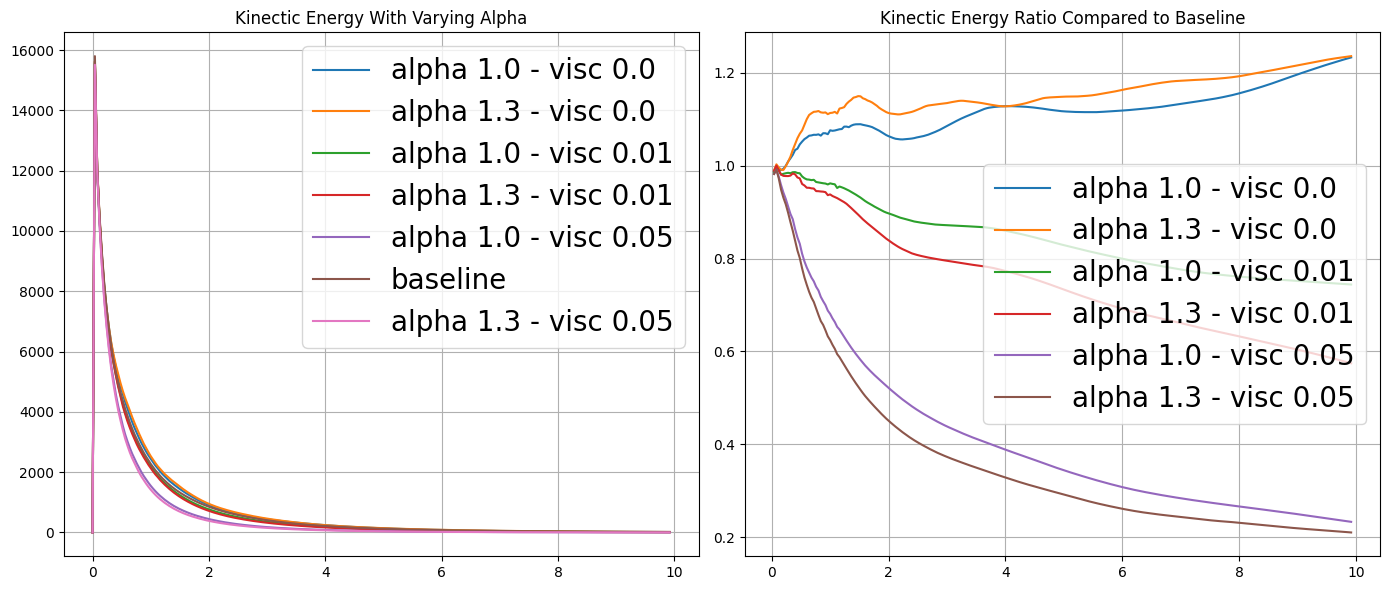

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
#             aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
#             ls_total_energy.append((aux_pot_energy + aux_kin_energy))
            ls_total_energy.append((aux_kin_energy))
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
    ax1.plot(time, ls_total_energy, label="{}".format(folder))

ax1.legend(fontsize=20)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Kinectic Energy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 - visc 0.0'], total_energy['baseline'])], label="alpha 1.0 - visc 0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.3 - visc 0.0'], total_energy['baseline'])], label="alpha 1.3 - visc 0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 - visc 0.01'], total_energy['baseline'])], label="alpha 1.0 - visc 0.01")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.3 - visc 0.01'], total_energy['baseline'])], label="alpha 1.3 - visc 0.01")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 - visc 0.05'], total_energy['baseline'])], label="alpha 1.0 - visc 0.05")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.3 - visc 0.05'], total_energy['baseline'])], label="alpha 1.3 - visc 0.05")

ax2.legend(fontsize=20)
ax2.grid(True)
ax2.set_title("Kinectic Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


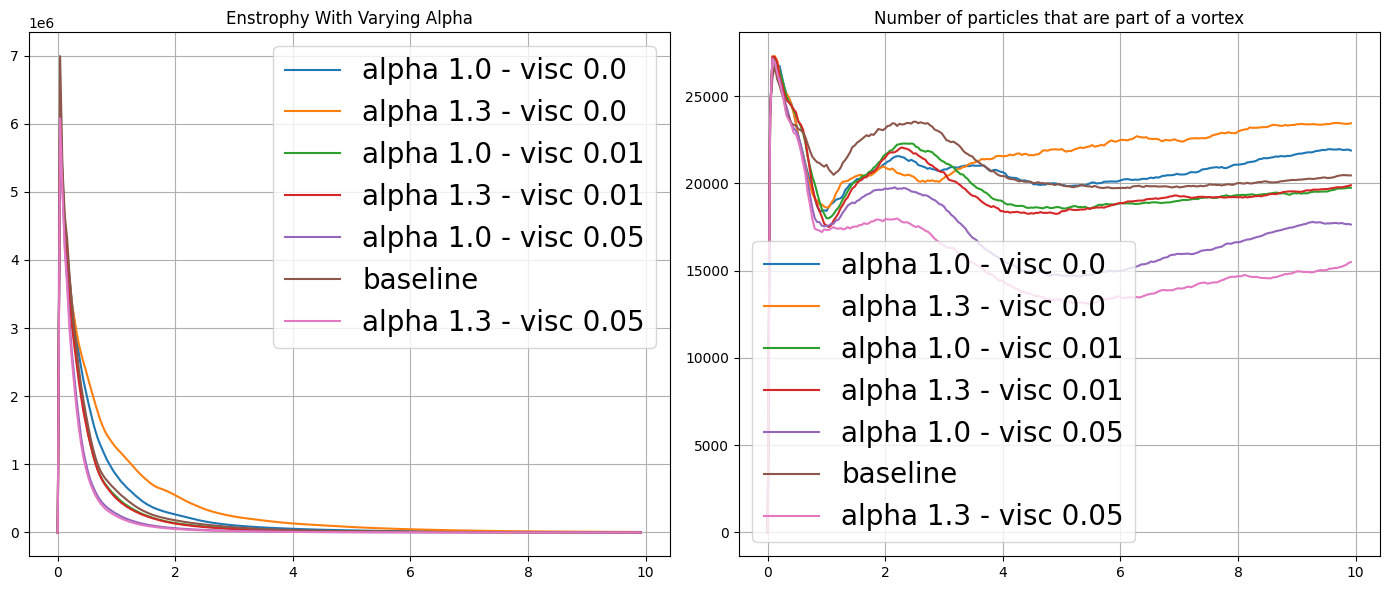

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    is_vortex = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
            
            is_vortex.append(np.count_nonzero(mesh.point_data['m_is_vortex']))
        else:
            enstrophy.append(0)
            is_vortex.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder))
    ax2.plot(time, is_vortex, label="{}".format(folder))

ax1.legend(fontsize=20)
ax1.grid(True)
ax1.set_title("Enstrophy With Varying Alpha")

ax2.legend(fontsize=20)
ax2.grid(True)
ax2.set_title("Number of particles that are part of a vortex")

plt.tight_layout()

plt.show()

## Comparing density i X density j

### More fluid 20k

In [35]:
scene = 'DamBreakModelWithWallMoreFluid'

folder_path = splishsplash_path + '/' + scene + '/visc fluid 0.01/'

print(folder_path)

folders = os.listdir(folder_path)

folders.remove('vr 1.0 - visc 0.01 (both) - curl symmetric - acceleration')
folders.remove('vr 0.0 - visc 0.01 (both) - curl symmetric - acceleration')
# print(folders)

folders = ['vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration'
           , 'vr 1.4 - visc 0.01 (both) - density_i on curls - acceleration'
           , 'vr 1.0 - visc 0.01 (both) - density_j all - acceleration'
           , 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'
           , 'vr 0.0 - visc 0.01 (both) - density_j all - acceleration']

print(folders)

D:/gabi//DamBreakModelWithWallMoreFluid/visc fluid 0.01/
['vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration', 'vr 1.4 - visc 0.01 (both) - density_i on curls - acceleration', 'vr 1.0 - visc 0.01 (both) - density_j all - acceleration', 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration', 'vr 0.0 - visc 0.01 (both) - density_j all - acceleration']


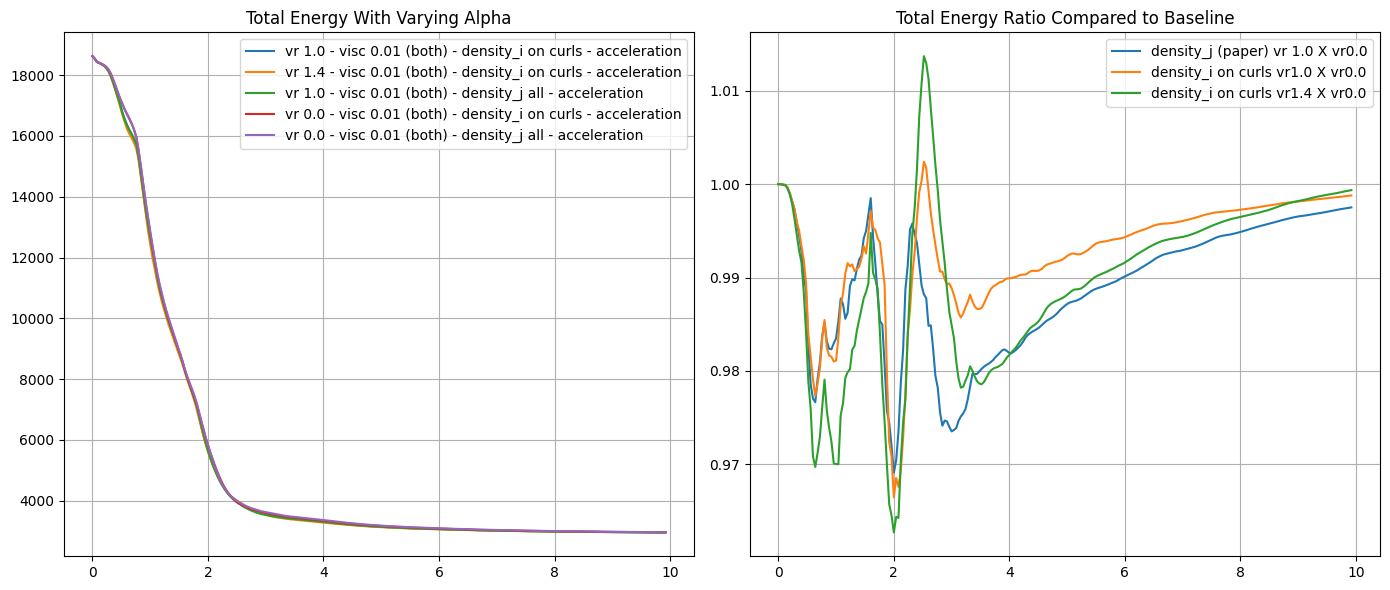

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
#             ls_total_energy.append((aux_kin_energy))
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
    ax1.plot(time, ls_total_energy, label="{}".format(folder))

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")

# ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i - acceleration'])], label="density_i vr 1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_j all - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_j all - acceleration'])], label="density_j (paper) vr 1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="density_i on curls vr1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.4 - visc 0.01 (both) - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="density_i on curls vr1.4 X vr0.0")

# ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration'], total_energy['vr 1.0 - visc 0.01 (both) - density_i - acceleration'])], label="density_i on curls X density_i")
# ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i on curls and gradient- acceleration'], total_energy['vr 1.0 - visc 0.01 (both) - density_i - acceleration'])], label="density_i on curls and gradient")
# ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i cross and stream - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i cross and stream - acceleration'])], label="density_i on curls and stream vr1.0 X vr0.0")
# ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i cross and stream - acceleration'], total_energy['vr 1.0 - visc 0.01 (both) - density_i - acceleration'])], label="density_i on curls and stream X density_i")

# ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i on curls and diff_lap - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i - acceleration'])], label="density_i on curls + lap vr 1.0 X vr 0.0")


ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


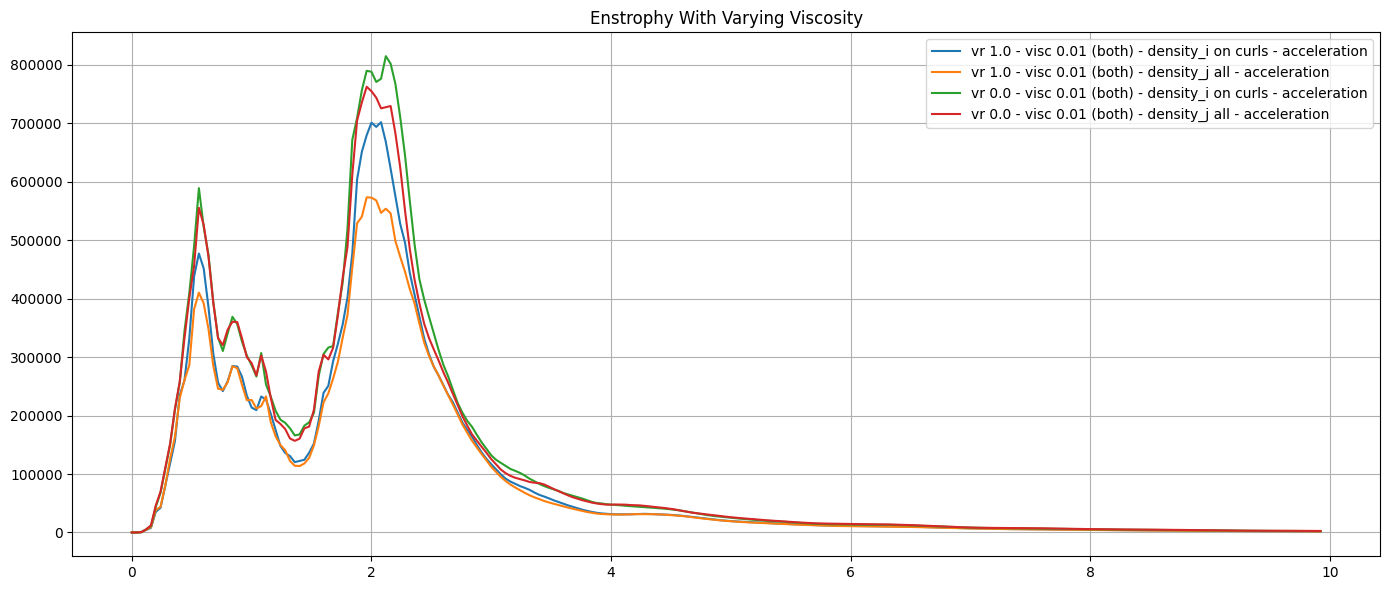

In [34]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6)) 
ax1 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder))

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Enstrophy With Varying Viscosity")

plt.tight_layout()    # neat spacing

plt.show()

### Medium 50k

In [111]:
scene = 'DamBreakModelWithWallMedium'

folder_path = splishsplash_path + '/' + scene + '/fluid_visc_0.01/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)

folders = ['vr1.0_model0.01_acceleration', 'baseline_model0.01_acceleration', 'vr1.4_model0.01_acceleration', 'baseline_model0.01_densityj_acceleration', 'vr1.0_model0.01_densityj_acceleration']

D:/gabi//DamBreakModelWithWallMedium/fluid_visc_0.01/
['vr1.0_model0.01_acceleration', 'baseline_model0.01_acceleration', 'vr1.4_model0.01_acceleration', 'baseline_model0.01_densityj_acceleration', 'vr1.0_model0.01_densityj_acceleration', 'vr1.4_model0.01_densityj_acceleration']


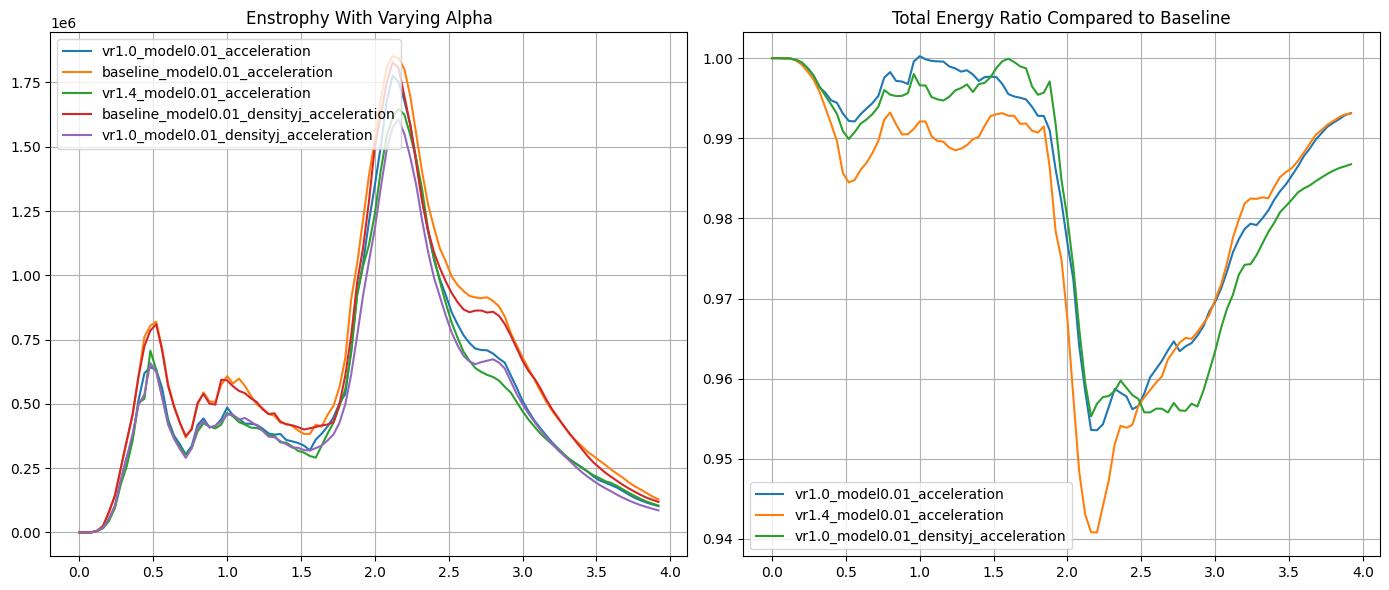

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 100
time = [i / 25 for i in range(end - begin)]

baseline_i = 'baseline_model0.01_acceleration'
others_i = ['vr1.0_model0.01_acceleration', 'vr1.4_model0.01_acceleration']

baseline_j = 'baseline_model0.01_densityj_acceleration'
others_j = ['vr1.0_model0.01_densityj_acceleration']

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))
    ax1.plot(time, enstrophy, label="{}".format(folder))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

for folder in others_i:
    ax2.plot(time, [x / y for x, y in zip(total_energy[folder], total_energy[baseline_i])], label=folder)
    
for folder in others_j:
    ax2.plot(time, [x / y for x, y in zip(total_energy[folder], total_energy[baseline_j])], label=folder)

ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


## Medium box larger 50k

In [123]:
scene = 'DamBreakModelWithWallMediumBoxLarge'

folder_path = splishsplash_path + '/' + scene + '/fluid_visc_0.01/'

print(folder_path)

folders = os.listdir(folder_path)
print(folders)

folders = ['vr1.4_model0.01_acceleration', 'vr1.0_model0.01_acceleration', 'baseline_model0.01_acceleration', 'baseline_model0.01_acceleration - density_j', 'vr1.0_model0.01_acceleration - density_j']

D:/gabi//DamBreakModelWithWallMediumBoxLarge/fluid_visc_0.01/
['vr1.0_model0.01_acceleration', 'baseline_model0.01_acceleration', 'vr1.4_model0.01_acceleration', 'vr1.4_model0.01_acceleration - density_j', 'baseline_model0.01_acceleration - density_j', 'vr1.0_model0.01_acceleration - density_j']


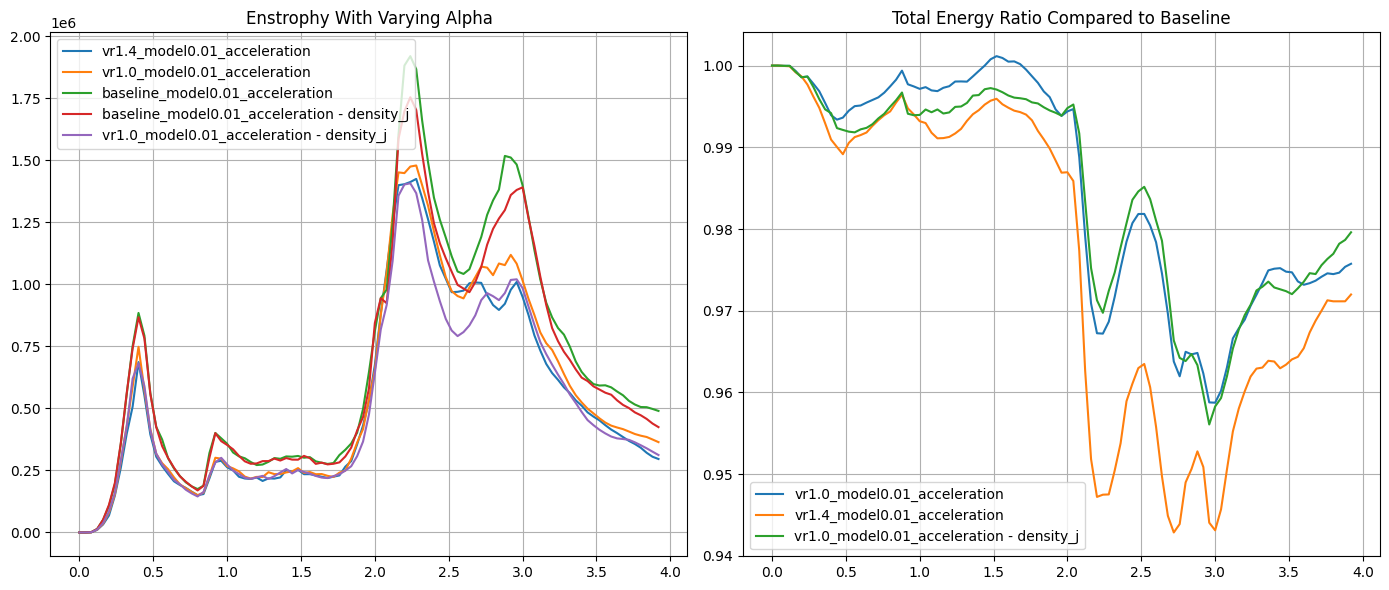

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 100
time = [i / 25 for i in range(end - begin)]

baseline_i = 'baseline_model0.01_acceleration'
others_i = ['vr1.0_model0.01_acceleration','vr1.4_model0.01_acceleration']

baseline_j = 'baseline_model0.01_acceleration - density_j'
others_j = ['vr1.0_model0.01_acceleration - density_j']

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))
    ax1.plot(time, enstrophy, label="{}".format(folder))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

for folder in others_i:
    ax2.plot(time, [x / y for x, y in zip(total_energy[folder], total_energy[baseline_i])], label=folder)
    
for folder in others_j:
    ax2.plot(time, [x / y for x, y in zip(total_energy[folder], total_energy[baseline_j])], label=folder)

ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


## Inviscid VR Dam Break With Wall - Density i (fluid visc 0.01)

In [52]:
scene = 'DamBreakModelWithWallMoreFluid'

folder_path = splishsplash_path + '/' + scene + '/visc fluid 0.01/'

print(folder_path)

folders = os.listdir(folder_path)

folders.remove('vr 1.0 - visc 0.01 (both) - curl symmetric - acceleration')
folders.remove('vr 0.0 - visc 0.01 (both) - curl symmetric - acceleration')
# print(folders)

folders = ['vr 1.5 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'
           , 'vr 1.2 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'
           , 'vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'
           , 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration']

print(folders)

D:/gabi//DamBreakModelWithWallMoreFluid/visc fluid 0.01/
['vr 1.5 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration', 'vr 1.2 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration', 'vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration', 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration']


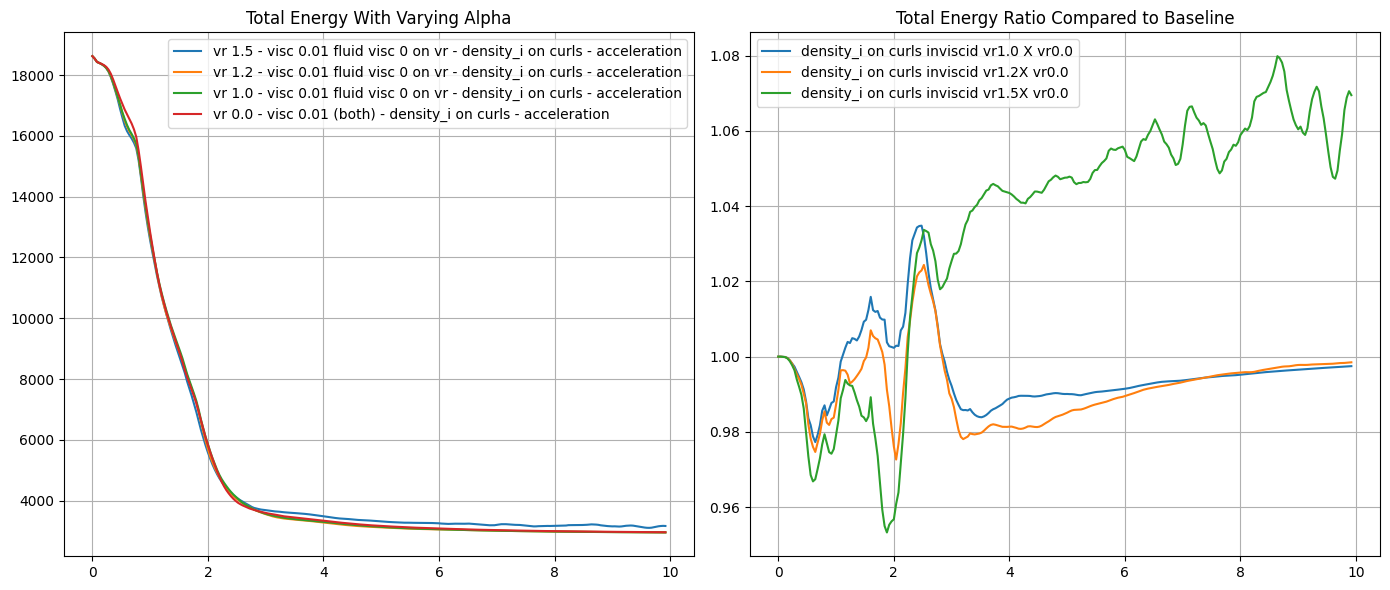

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
#             ls_total_energy.append((aux_kin_energy))
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
    ax1.plot(time, ls_total_energy, label="{}".format(folder))

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Total Energy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="density_i on curls inviscid vr1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.2 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="density_i on curls inviscid vr1.2X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.5 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="density_i on curls inviscid vr1.5X vr0.0")


ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


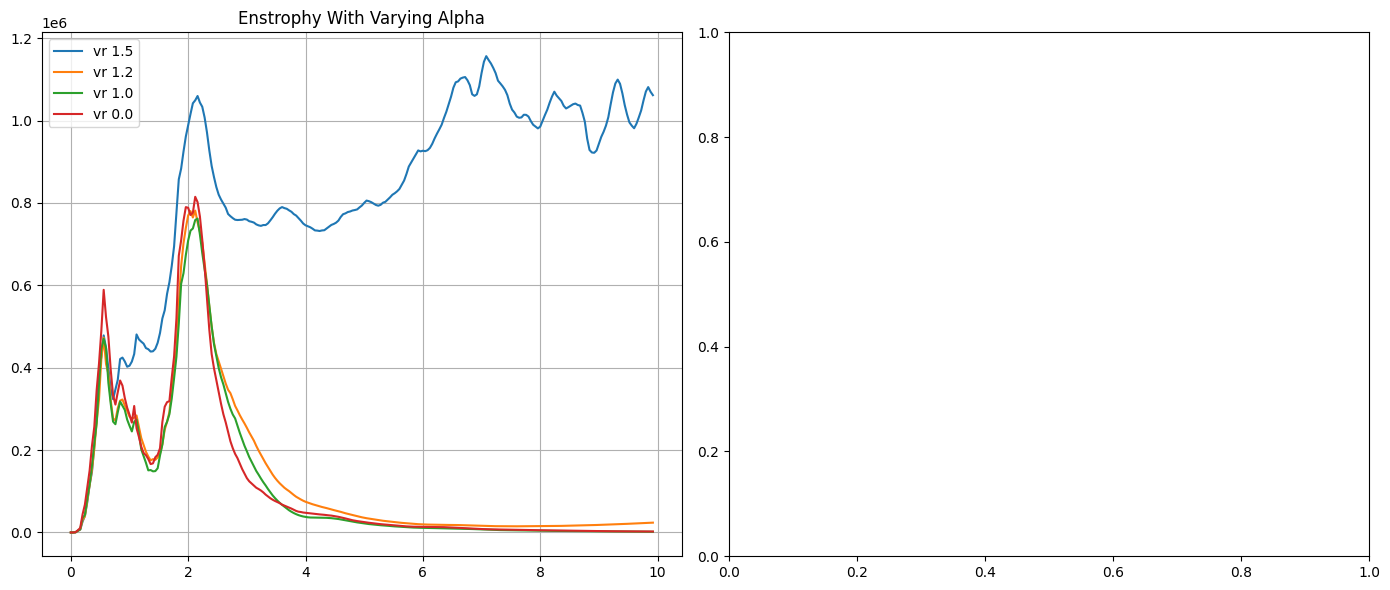

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    ax1.plot(time, enstrophy, label="{}".format(folder[:6]))

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Enstrophy With Varying Alpha")

plt.tight_layout()    # neat spacing

plt.show()

## Viscous VR Dam Break With Wall - Density i (fluid visc 0.01)

In [4]:
scene = 'DamBreakModelWithWallMoreFluid'

folder_path = splishsplash_path + '/' + scene + '/visc fluid 0.01/'

print(folder_path)

folders = os.listdir(folder_path)

folders.remove('vr 1.0 - visc 0.01 (both) - curl symmetric - acceleration')
folders.remove('vr 0.0 - visc 0.01 (both) - curl symmetric - acceleration')
# print(folders)

folders = ['vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'
           , 'vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration'
           , 'vr 1.0 - visc 0.01 fluid visc 0.03 on vr - density_i on curls - acceleration'
           , 'vr 1.0 - visc 0.01 fluid visc 0.05 on vr - density_i on curls - acceleration'
           , 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'
           , 'vr1.0 - visc 0.01 (both) - density_i o curls - acceleration - normalized diffusion']
 
print(folders)

D:/gabi//DamBreakModelWithWallMoreFluid/visc fluid 0.01/
['vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration', 'vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration', 'vr 1.0 - visc 0.01 fluid visc 0.03 on vr - density_i on curls - acceleration', 'vr 1.0 - visc 0.01 fluid visc 0.05 on vr - density_i on curls - acceleration', 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration', 'vr1.0 - visc 0.01 (both) - density_i o curls - acceleration - normalized diffusion']


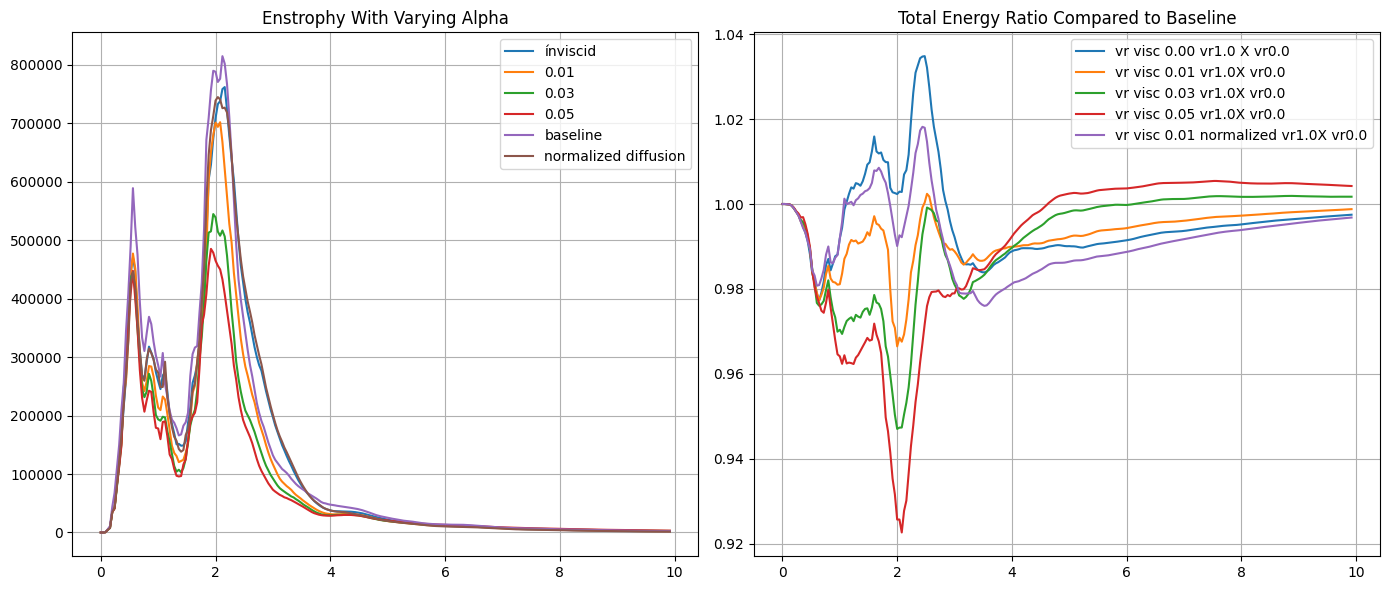

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))
    if folder == 'vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration':
        name = 'ínviscid'
    elif folder == 'vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration':
        name = '0.01'
    elif folder == 'vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration':
        name = 'baseline'
    elif folder ==  'vr1.0 - visc 0.01 (both) - density_i o curls - acceleration - normalized diffusion':
        name = 'normalized diffusion'
    else:
        name = folder[30:34]
    ax1.plot(time, enstrophy, label="{}".format(name))
#     ax1.plot(time[50:75], enstrophy[50:75], label="{}".format(name))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 fluid visc 0 on vr - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="vr visc 0.00 vr1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 (both) - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="vr visc 0.01 vr1.0X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 fluid visc 0.03 on vr - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="vr visc 0.03 vr1.0X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr 1.0 - visc 0.01 fluid visc 0.05 on vr - density_i on curls - acceleration'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="vr visc 0.05 vr1.0X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['vr1.0 - visc 0.01 (both) - density_i o curls - acceleration - normalized diffusion'], total_energy['vr 0.0 - visc 0.01 (both) - density_i on curls - acceleration'])], label="vr visc 0.01 normalized vr1.0X vr0.0")


ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


In [4]:
scene = 'DamBreakModelWithWallMoreFluid'

folder_path = splishsplash_path + '/' + scene + '/visc fluid 0.05/'

print(folder_path)

folders = os.listdir(folder_path)

folders.remove('alpha1.0_visc0.05_both_acceleration_nocfl')
folders.remove('alpha1.0_visc0.05_both_acceleration_lapdot')
folders.remove('coparing_diff_stretching.pvsm')
folders.remove('alpha1.0_fluid0.05_vr0.05modularvisc_Acceleration_smoothlow')
folders.remove('alpha1.0_fluid0.05_vr0.05modularvisc_Acceleration_smoothhigh')
# print(folders)

# folders = ['alpha1.0_fluid0.05_vr0.02_acceleration'
#            , 'alpha1.0_visc0.05_both_acceleration'
#            , 'baseline_visc0,05_both_acceleration'
#            , 'alpha1.0_fluid0.05both_lap_norm_acceleration'
#           ]

print(folders)

D:/gabi//DamBreakModelWithWallMoreFluid/visc fluid 0.05/
['alpha1.0_fluid0.05_vr0.02_acceleration', 'alpha1.0_visc0.05_both_acceleration', 'baseline_visc0,05_both_acceleration', 'alpha1.0_fluid0.05both_lap_norm_acceleration', 'alpha1.0_visc0.05_both_acceleration_derend', 'alpha1.0_fluid0.05_vr0.005_acceleration', 'alpha1.0_visc0.05both_diverror0.01_acceleration', 'alpha1.0_visc0.05both_diverror0.5_acceleration', 'baseline_visc0.05both_diverror0.5_acceleration', 'baseline_visc0.05both_divfreedisabled_acceleration', 'alpha1.0_visc0.05both_divfreedisabled_acceleration']


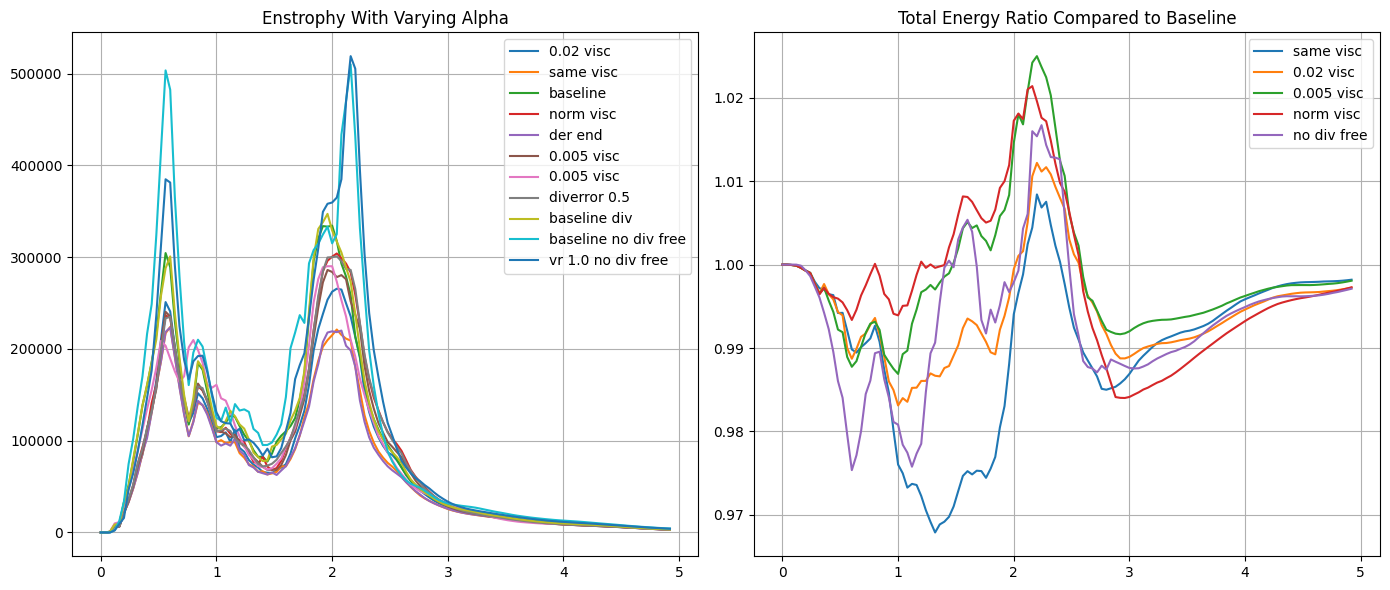

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 125
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))
    if folder == 'baseline_visc0,05_both_acceleration':
        name = 'baseline'
    elif folder == 'alpha1.0_visc0.05_both_acceleration':
        name = 'same visc'
    elif folder == 'alpha1.0_fluid0.05_vr0.02_acceleration':
        name = '0.02 visc'
    elif folder == 'alpha1.0_fluid0.05_vr0.005_acceleration':
        name = '0.005 visc'
    elif folder == 'alpha1.0_fluid0.05both_lap_norm_acceleration':
        name = 'norm visc'
    elif folder == 'alpha1.0_visc0.05_both_acceleration_nocfl':
        name = 'no cfl'
    elif folder == 'alpha1.0_visc0.05_both_acceleration_lapdot':
        name = 'laplacian dot'
    elif folder == 'alpha1.0_visc0.05_both_acceleration_derend':
        name = 'der end'
    elif folder == 'alpha1.0_fluid0.05_vr0.05modularvisc_Acceleration_smoothhigh':
        name = 'mod visc'
    elif folder == 'alpha1.0_visc0.05both_diverror0.5_acceleration':
        name = 'diverror 0.5'
    elif folder == 'baseline_visc0.05both_diverror0.5_acceleration':
        name = 'baseline div'
    elif folder == 'alpha1.0_visc0.05both_divfreedisabled_acceleration':
        name = 'vr 1.0 no div free'
    elif folder == 'baseline_visc0.05both_divfreedisabled_acceleration':
        name = 'baseline no div free'
    ax1.plot(time, enstrophy, label="{}".format(name))
#     ax1.plot(time[50:75], enstrophy[50:75], label="{}".format(name))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['alpha1.0_visc0.05_both_acceleration'], total_energy['baseline_visc0,05_both_acceleration'])], label="same visc")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha1.0_fluid0.05_vr0.02_acceleration'], total_energy['baseline_visc0,05_both_acceleration'])], label="0.02 visc")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha1.0_fluid0.05_vr0.005_acceleration'], total_energy['baseline_visc0,05_both_acceleration'])], label="0.005 visc")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha1.0_fluid0.05both_lap_norm_acceleration'], total_energy['baseline_visc0,05_both_acceleration'])], label="norm visc")
# ax2.plot(time, [x / y for x, y in zip(total_energy['alpha1.0_visc0.05both_diverror0.5_acceleration'], total_energy['baseline_visc0.05both_diverror0.5_acceleration'])], label="div 0.5")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha1.0_visc0.05both_divfreedisabled_acceleration'], total_energy['baseline_visc0.05both_divfreedisabled_acceleration'])], label="no div free")




ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


[[  -28.564543   -20.450125    68.50488 ]
 [  -15.45349    -35.632553    27.579927]
 [  -70.539345   -34.512173  -187.55011 ]
 ...
 [ -762.91724   -163.18706   -338.11652 ]
 [   33.477036  1638.345    -1340.6233  ]
 [ -392.23996   1188.9192    -733.9235  ]]
[  76.9874    47.63551  203.32716 ...  850.29144 2117.207   1451.215  ]
2117.207


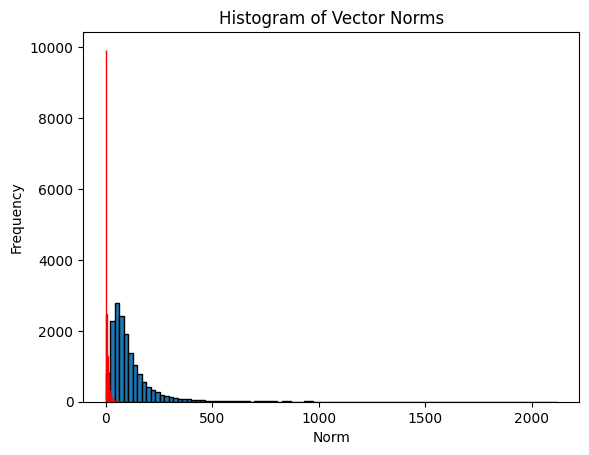

In [19]:
# for folder in folders:
folder = 'baseline_visc0,05_both_acceleration'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
enstrophy = []
#     for i in range(begin,end):
file = 'ParticleData_Fluid_{}.vtk'.format(40)

mesh = meshio.read(full_path + file)
positions = mesh.points

lap = mesh.point_data['m_vorticity_rate_laplacian']
grad = mesh.point_data['m_vorticity_rate_gradient']

print(lap)

norms_lap = np.linalg.norm(lap, axis=1)
norms_grad = np.linalg.norm(grad, axis=1)

print(norms_lap)
print(np.max(norms_lap))

#     h = mesh.points[:,1]

plt.hist(norms_lap, bins=100, edgecolor='black')
plt.hist(norms_grad, bins=100, edgecolor='red')

plt.xlabel("Norm")
plt.ylabel("Frequency")
plt.title("Histogram of Vector Norms")
plt.show()

## 2D Spilling

In [93]:
scene = 'Spilling2D'

folder_path = splishsplash_path + '/' + scene + '/visc fluid 0.01/'

print(folder_path)

folders = os.listdir(folder_path)
folders.remove('alpha1.0_fluid0.01_vr0.02')

print(folders)

D:/gabi//Spilling2D/visc fluid 0.01/
['alpha1.2_fluid0.01_vr0.01', 'baseline_fluid0.01_vr0.01', 'alpha0.5_fluid_0.01_vr0.02', 'alpha0.5_fluid0.01_vr0.0', 'alpha1.0_fluid0.01_vr0.01']


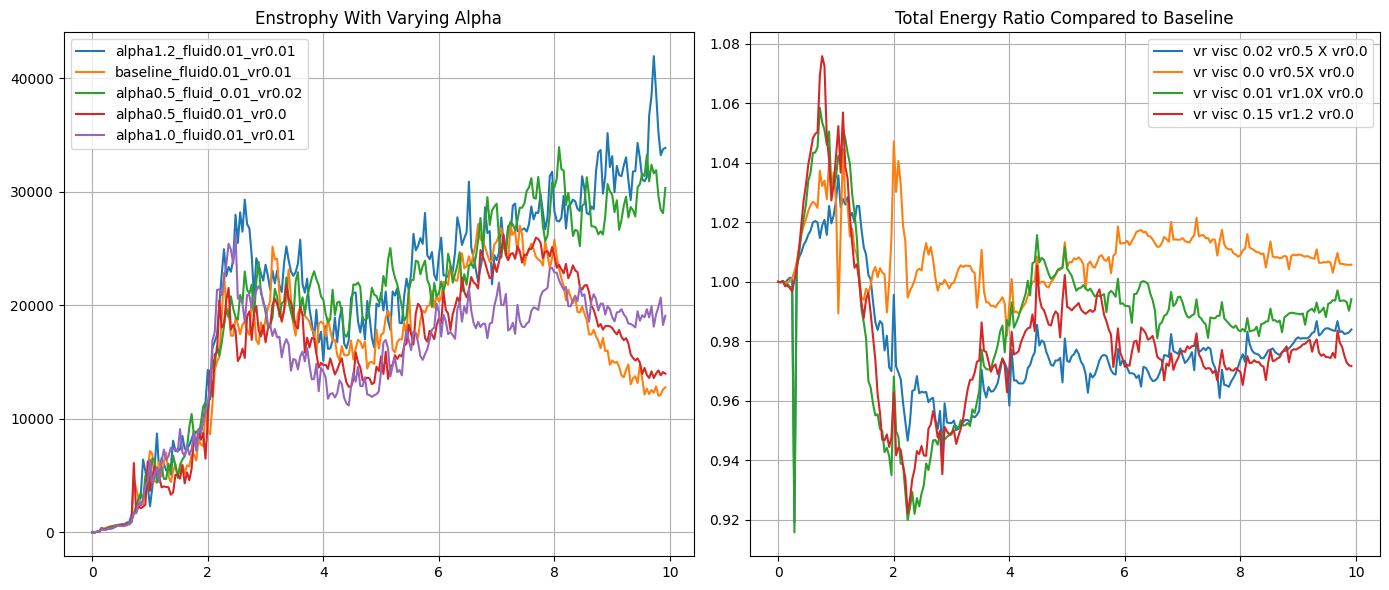

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 250
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))

    ax1.plot(time, enstrophy, label="{}".format(folder))
#     ax1.plot(time[50:75], enstrophy[50:75], label="{}".format(name))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['alpha0.5_fluid_0.01_vr0.02'], total_energy['baseline_fluid0.01_vr0.01'])], label="vr visc 0.02 vr0.5 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha0.5_fluid0.01_vr0.0'], total_energy['baseline_fluid0.01_vr0.01'])], label="vr visc 0.0 vr0.5X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha1.0_fluid0.01_vr0.01'], total_energy['baseline_fluid0.01_vr0.01'])], label="vr visc 0.01 vr1.0X vr0.0")
# ax2.plot(time, [x / y for x, y in zip(total_energy['alpha1.0_fluid0.01_vr0.02'], total_energy['baseline_fluid0.01_vr0.01'])], label="vr visc 0.02 vr1.0X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha1.2_fluid0.01_vr0.01'], total_energy['baseline_fluid0.01_vr0.01'])], label="vr visc 0.15 vr1.2 vr0.0")


ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


In [136]:
folder_teste = 'C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModelWithWallMoreFluid/vtk/'
begin = 3
end = 4
for i in range(begin,end):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(folder_teste + file)
    print(mesh.point_data['m_lambdatwo'])
    print(mesh.point_data['m_is_vortex'])
    print(mesh.point_data['m_a_adv'])
    print(mesh.point_data['velocity'])

[0.6724004  0.6036457  0.6045917  ... 0.68222487 0.68225586 0.79997844]
[0.6724004  0.6036457  0.6045917  ... 0.68222487 0.68225586 0.79997844]
[0.6724004  0.6036457  0.6045917  ... 0.68222487 0.68225586 0.79997844]
[[-3.2780793e-02 -6.9383764e-01 -4.7707019e-04]
 [-3.0224326e-01 -8.4209985e-01  1.5725321e-04]
 [-2.9194510e-01 -8.4550768e-01 -1.0204399e-03]
 ...
 [ 0.0000000e+00 -7.9460984e-01  0.0000000e+00]
 [ 0.0000000e+00 -7.9460984e-01  0.0000000e+00]
 [ 0.0000000e+00 -7.9460984e-01  0.0000000e+00]]


In [16]:
scene = 'DamBreakModelWithWallMoreFluidMoreParticles'

folder_path = splishsplash_path + scene + '/visc0.01/'

print(folder_path)

folders = os.listdir(folder_path)
folders.remove('old-larger_fluid_breaking_on_top')
folders.remove('comparingall.blend1')
folders.remove('comparingall.blend')

print(folders)

D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.01/
['nocfl_0.001_baseline_fluid0.01_vr0.01', 'nocfl_0.001_alpha1.0_fluid0.01_vr0.01', 'nocfl_0.0001_alpha1.0_fluid0.01_vr0.01', 'nocfl_0.0001_baseline_fluid0.01_vr0.01', 'baseline_fluid0.01_vr0.01', 'alpha1.0_fluid0.01_vr0.01', 'nocfl_0.0005_alpha1.0_fluid0.01_vr0.01', 'nocfl_0.0005_baseline_fluid0.01_vr0.01', 'nocfl_0.005_alpha1.0_fluid0.01_vr0.01', 'nocfl_0.005_baseline_fluid0.01_vr0.01']


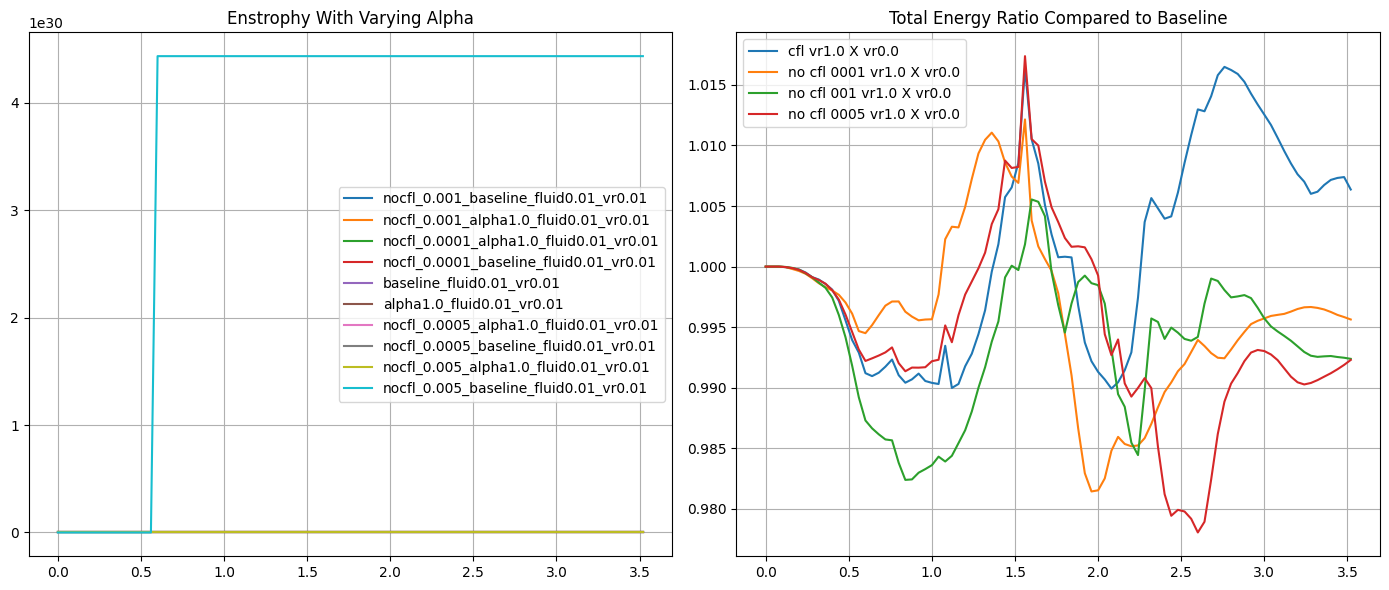

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 90
time = [i / 25 for i in range(end - begin)] 

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
            
    total_energy[folder] = ls_total_energy
    ax1.plot(time, total_energy[folder], label="{}".format(folder))    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
ax1.set_title("Enstrophy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['alpha1.0_fluid0.01_vr0.01'], total_energy['baseline_fluid0.01_vr0.01'])], label="cfl vr1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['nocfl_0.0001_alpha1.0_fluid0.01_vr0.01'], total_energy['nocfl_0.0001_baseline_fluid0.01_vr0.01'])], label="no cfl 0001 vr1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['nocfl_0.001_alpha1.0_fluid0.01_vr0.01'], total_energy['nocfl_0.001_baseline_fluid0.01_vr0.01'])], label="no cfl 001 vr1.0 X vr0.0")
# ax2.plot(time, [x / y for x, y in zip(total_energy['nocfl_0.005_alpha1.0_fluid0.01_vr0.01'], total_energy['nocfl_0.005_baseline_fluid0.01_vr0.01'])], label="no cfl 005 vr1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['nocfl_0.0005_alpha1.0_fluid0.01_vr0.01'], total_energy['nocfl_0.0005_baseline_fluid0.01_vr0.01'])], label="no cfl 0005 vr1.0 X vr0.0")


ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


[[-119.332726  190.11374  -112.629005]
 [ 172.0103   -191.3942    135.55043 ]
 [-269.4376   -313.7912     -1.350907]
 ...
 [ -19.65521   128.71106   -85.74727 ]
 [ -32.717705  112.945045  -92.14563 ]
 [ 165.29546   123.38987   -79.6594  ]]
[[-1.7451634   9.5898905  -1.3796525 ]
 [47.066536   20.857891    4.1446376 ]
 [ 7.17819    38.071053   -5.578218  ]
 ...
 [-5.509773   -3.5831902   4.363461  ]
 [-0.90944445 -1.7661104   0.6424498 ]
 [-6.878416   -1.190057    3.8233018 ]]
[0.03920019 0.17757568 0.09463628 ... 0.0506024  0.01397546 0.03599454]


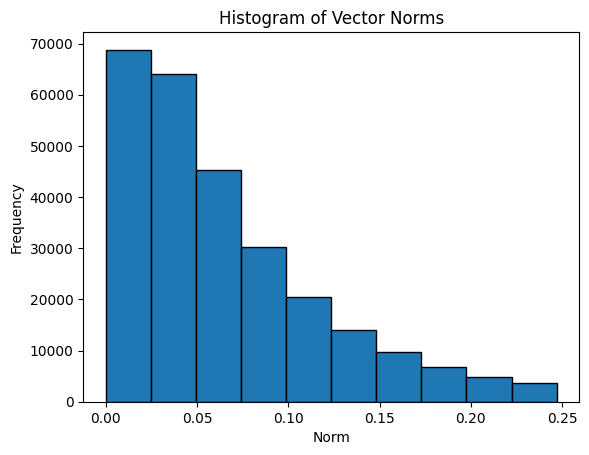

In [47]:
# for folder in folders:
folder = 'nocfl_0.001_baseline_fluid0.01_vr0.01'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
enstrophy = []
#     for i in range(begin,end):
file = 'ParticleData_Fluid_{}.vtk'.format(70)

mesh = meshio.read(full_path + file)
positions = mesh.points

lap = mesh.point_data['m_vorticity_rate_laplacian']
grad = mesh.point_data['m_vorticity_rate_gradient']

print(lap)
print(grad)

norms_lap = np.linalg.norm(lap, axis=1)
norms_grad = np.linalg.norm(grad, axis=1)

grad_over_lap = norms_grad/np.clip(norms_lap, 1e-8, None)
low, high = np.percentile(grad_over_lap, [0, 95])
filtered = grad_over_lap[(grad_over_lap >= low) & (grad_over_lap <= high)]

# print(norms_lap)
# print(np.max(norms_lap))
print(grad_over_lap)

#     h = mesh.points[:,1]

# plt.hist(norms_lap, bins=100, edgecolor='black')
# plt.hist(norms_grad, bins=100, edgecolor='red')
plt.hist(filtered, bins=10, edgecolor='black')


plt.xlabel("Norm")
plt.ylabel("Frequency")
plt.title("Histogram of Vector Norms")
plt.show()

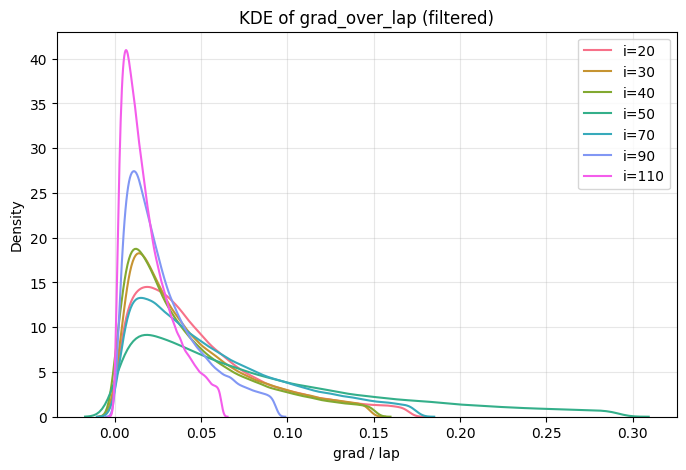

In [22]:
import os
import numpy as np
import meshio
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
colors = sns.color_palette("husl", 7)


# for folder in folders:
folder = 'nocfl_0.001_baseline_fluid0.01_vr0.01'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
enstrophy = []

for idx, i in enumerate([20, 30, 40, 50, 70, 90, 110]):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points

    lap = mesh.point_data['m_vorticity_rate_laplacian']
    grad = mesh.point_data['m_vorticity_rate_gradient']

    norms_lap = np.linalg.norm(lap, axis=1)
    norms_grad = np.linalg.norm(grad, axis=1)

    grad_over_lap = norms_grad / np.clip(norms_lap, 1e-8, None)

    # percentile filtering
    low, high = np.percentile(grad_over_lap, [0, 90])
    filtered = grad_over_lap[(grad_over_lap >= low) & (grad_over_lap <= high)]

    # --- KDE plot ---
    sns.kdeplot(filtered, fill=False, bw_method='scott', color=colors[idx], label=f"i={i}")

plt.xlabel("grad / lap")
plt.ylabel("Density")
plt.title("KDE of grad_over_lap (filtered)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<Figure size 800x500 with 0 Axes>

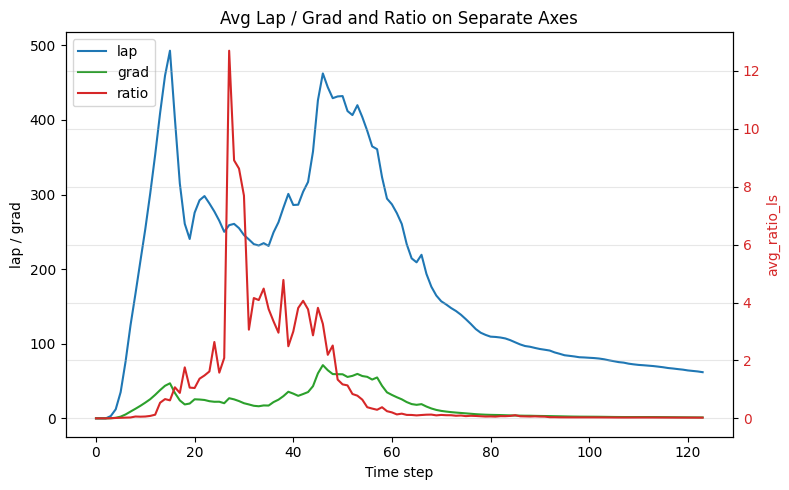

In [9]:
import os
import numpy as np
import meshio
import matplotlib.pyplot as plt
import seaborn as sns

# fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
# ax1, ax2 = axes 

begin = 1
end = 125
time = [i / 25 for i in range(end - begin)] 
# ax1.plot(time, total_energy[folder], label="{}".format(folder))    
# ax2.legend(fontsize=10)
# ax2.grid(True)
# ax2.set_title("Total Energy Ratio Compared to Baseline")

# plt.tight_layout()
# plt.show()

plt.figure(figsize=(8, 5))
colors = sns.color_palette("husl", 6)

fig, ax1 = plt.subplots(figsize=(8, 5))


# for folder in folders:
folder = 'nocfl_0.001_baseline_fluid0.01_vr0.01'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
avg_ratio_ls = []
avg_lap = []
avg_grad = []

for i in range(begin, end):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points
    
    number_particles = len(positions)

    lap = mesh.point_data['m_vorticity_rate_laplacian']
    grad = mesh.point_data['m_vorticity_rate_gradient']

    norms_lap = np.linalg.norm(lap, axis=1)
    norms_grad = np.linalg.norm(grad, axis=1)
    
    avg_lap.append(np.mean(norms_lap))
    avg_grad.append(np.mean(norms_grad))

    grad_over_lap = norms_grad / np.clip(norms_lap, 1e-8, None)
    
    avg_ratio = np.mean(grad_over_lap)
    avg_ratio_ls.append(avg_ratio)

#     # percentile filtering
#     low, high = np.percentile(grad_over_lap, [0, 99])
#     filtered = grad_over_lap[(grad_over_lap >= low) & (grad_over_lap <= high)]

    # --- KDE plot ---

# First axis: lap and grad
ax1.plot(avg_lap, label="lap", color="tab:blue")
ax1.plot(avg_grad, label="grad", color="tab:green")
ax1.set_xlabel("Time step")
ax1.set_ylabel("lap / grad", color="black")
ax1.tick_params(axis='y', labelcolor='black')

# Second axis: avg_ratio_ls
ax2 = ax1.twinx()
ax2.plot(avg_ratio_ls, label="ratio", color="tab:red")
ax2.set_ylabel("avg_ratio_ls", color="tab:red")
ax2.tick_params(axis='y', labelcolor='tab:red')

# Combine legends from both axes
lns1, labels1 = ax1.get_legend_handles_labels()
lns2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, labels1 + labels2, loc="upper left")

plt.title("Avg Lap / Grad and Ratio on Separate Axes")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<Figure size 800x500 with 0 Axes>

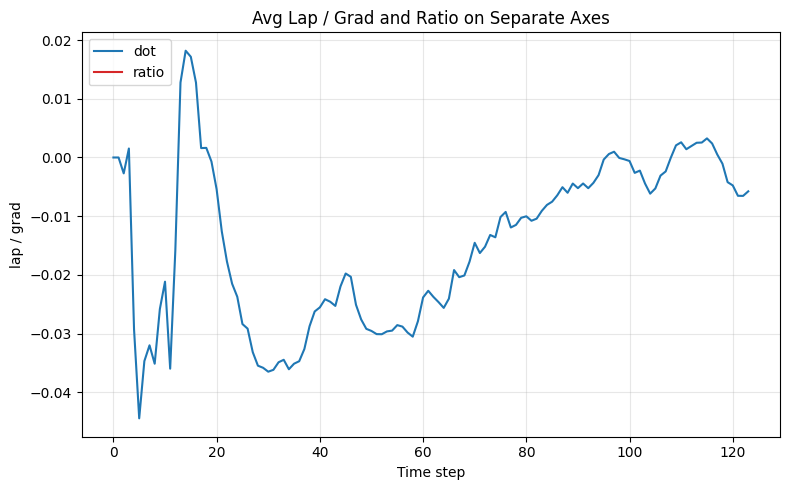

In [10]:
begin = 1
end = 125
time = [i / 25 for i in range(end - begin)] 

plt.figure(figsize=(8, 5))
colors = sns.color_palette("husl", 6)

fig, ax1 = plt.subplots(figsize=(8, 5))


# for folder in folders:
folder = 'nocfl_0.001_baseline_fluid0.01_vr0.01'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
avg_ratio_ls = []
avg_lap = []
avg_grad = []
avg_dot_ls = []

for i in range(begin, end):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points
    
    number_particles = len(positions)

    lap = mesh.point_data['m_vorticity_rate_laplacian']
    grad = mesh.point_data['m_vorticity_rate_gradient']

    # Compute norms (shape: (N, 1))
    lap_norm = np.linalg.norm(lap, axis=1, keepdims=True)
    grad_norm = np.linalg.norm(grad, axis=1, keepdims=True)

    # Avoid division by zero
    lap_norm[lap_norm == 0] = 1.0
    grad_norm[grad_norm == 0] = 1.0

    # Normalize
    lap_unit = lap / lap_norm
    grad_unit = grad / grad_norm

    # Dot product of normalized vectors
    dot_norm = np.sum(lap_unit * grad_unit, axis=1)

    # Average
    avg_dot = np.mean(dot_norm)
    avg_dot_ls.append(avg_dot)


# First axis: lap and grad
ax1.plot(avg_dot_ls, label="dot", color="tab:blue")
ax1.set_xlabel("Time step")
ax1.set_ylabel("lap / grad", color="black")
ax1.tick_params(axis='y', labelcolor='black')

# Combine legends from both axes
lns1, labels1 = ax1.get_legend_handles_labels()
lns2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, labels1 + labels2, loc="upper left")

plt.title("Avg Lap / Grad and Ratio on Separate Axes")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


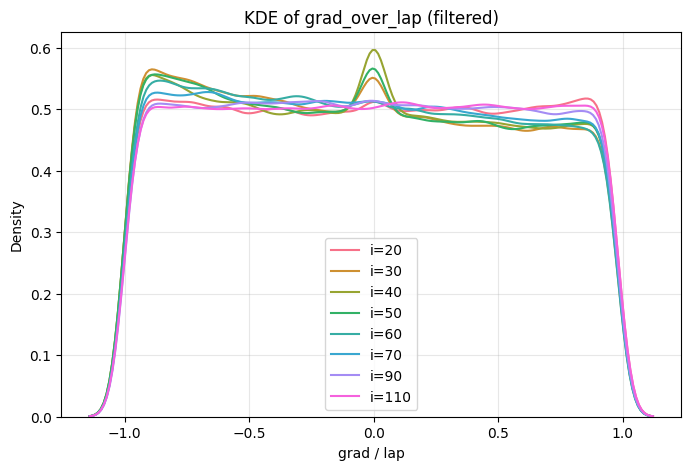

In [19]:
plt.figure(figsize=(8, 5))
colors = sns.color_palette("husl", 8)


# for folder in folders:
folder = 'nocfl_0.001_baseline_fluid0.01_vr0.01'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
enstrophy = []

for idx, i in enumerate([20, 30, 40, 50, 60, 70, 90, 110]):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points

    lap = mesh.point_data['m_vorticity_rate_laplacian']
    grad = mesh.point_data['m_vorticity_rate_gradient']

    # Compute norms (shape: (N, 1))
    lap_norm = np.linalg.norm(lap, axis=1, keepdims=True)
    grad_norm = np.linalg.norm(grad, axis=1, keepdims=True)

    # Avoid division by zero
    lap_norm[lap_norm == 0] = 1.0
    grad_norm[grad_norm == 0] = 1.0

    # Normalize
    lap_unit = lap / lap_norm
    grad_unit = grad / grad_norm

    # Dot product of normalized vectors
    dot_norm = np.sum(lap_unit * grad_unit, axis=1)

    # percentile filtering
    low, high = np.percentile(dot_norm, [0, 99])
    filtered = dot_norm[(dot_norm >= low) & (dot_norm <= high)]

    # --- KDE plot ---
    sns.kdeplot(filtered, fill=False, bw_method='scott', color=colors[idx], label=f"i={i}")

plt.xlabel("grad / lap")
plt.ylabel("Density")
plt.title("KDE of grad_over_lap (filtered)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [44]:
scene = 'DamBreakModelWithWallMoreFluidMoreParticles'

folder_path = splishsplash_path + scene + '/visc0.02/'

print(folder_path)

folders = os.listdir(folder_path)
# folders.remove('alpha1.0_fluid0.01_vr0.02')

print(folders)

D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.02/
['vrvisc00_baseline_particle01', 'vrvisc02_baseline_particle01', 'vrvisc05_baseline_particle01', 'vrvisc00_alpha15_particle01', 'vrvisc00_alpha13_particle01', 'vrvisc00_alpha1_particle01', 'vrvisc02_alpha1_particle01', 'vrvisc05_alpha1_particle01', 'vrvisc02_alpha1_particle02', 'vrvisc02_alpha1_particle015', 'vrvisc02_baseline_particle02', 'vrvisc02_baseline_particle015', 'vrvisc01_alpha1_particle01', 'vrvisc1_alpha1_particle01', 'vrvisc02_baseline_particle025', 'vrvisc02_alpha1_particle025', 'vrvisc01_alpha0_particle01', 'vrvisc1_alpha0_particle01', 'vrvisc02_alpha1_particle01_modinit200', 'vrvisc02_alpha1_particle01_modgrad500']


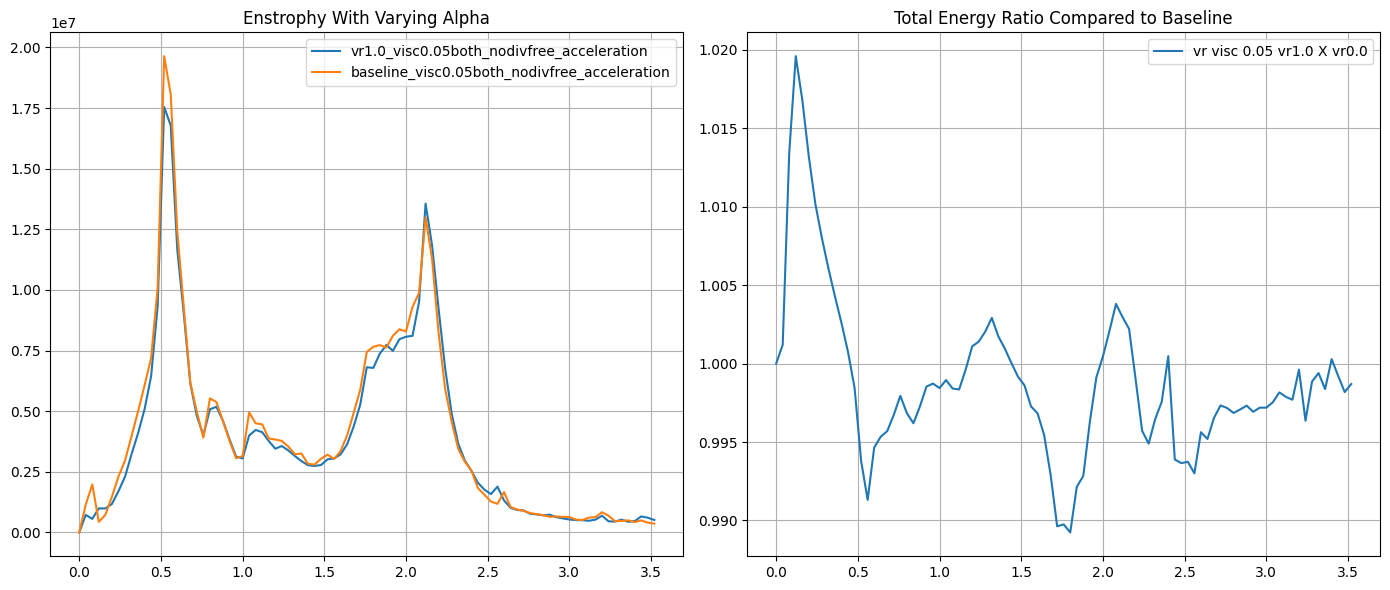

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 90
time = [i / 25 for i in range(end - begin)] 

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_pot_energy + aux_kin_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))

    ax1.plot(time, enstrophy, label="{}".format(folder))
#     ax1.plot(time[50:75], enstrophy[50:75], label="{}".format(name))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['vr1.0_visc0.05both_nodivfree_acceleration'], total_energy['baseline_visc0.05both_nodivfree_acceleration'])], label="vr visc 0.05 vr1.0 X vr0.0")

ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


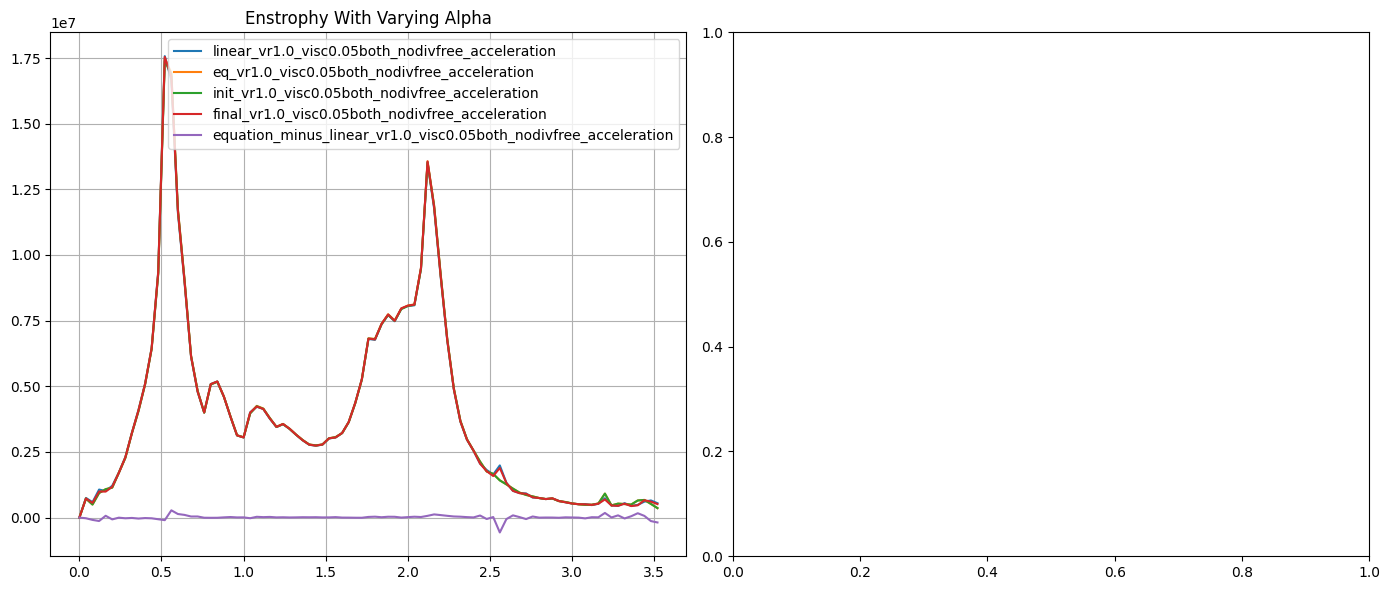

In [44]:
folders = ['vr1.0_visc0.05both_nodivfree_acceleration']

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 90
time = [i / 25 for i in range(end - begin)]

total_energy = {}

    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy_linear = []
    enstrophy_eq = []
    enstrophy_init = []
    enstrophy_final = []
    enstrophy_eq_minus_lin = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        lap = mesh.point_data['m_vorticity_rate_laplacian']
        grad = mesh.point_data['m_vorticity_rate_gradient']
        der = mesh.point_data['vorticity_derivative']
        init = mesh.point_data['m_vorticity_init']
        eq = mesh.point_data['m_vorticity_equation']
        linear = mesh.point_data['vorticity_linear_field']
        final = mesh.point_data['vorticity_corrected_end']
        
        number_particles = len(h)
        if number_particles > 0:

            aux_kin_ens = np.sum((norm(linear, axis=1)**2) / 2)
            enstrophy_linear.append(aux_kin_ens)
            
            aux_kin_ens = np.sum((norm(eq, axis=1)**2) / 2)
            enstrophy_eq.append(aux_kin_ens)
            
            aux_kin_ens = np.sum((norm(init, axis=1)**2) / 2)
            enstrophy_init.append(aux_kin_ens)
            
            aux_kin_ens = np.sum((norm(final, axis=1)**2) / 2)
            enstrophy_final.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
#     total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))

    ax1.plot(time, enstrophy_linear, label="linear_{}".format(folder))
    ax1.plot(time, enstrophy_eq, label="eq_{}".format(folder))
    ax1.plot(time, enstrophy_init, label="init_{}".format(folder))
    ax1.plot(time, enstrophy_final, label="final_{}".format(folder))
    ax1.plot(time, [a - b for a, b in zip(enstrophy_eq, enstrophy_linear)], label="equation_minus_linear_{}".format(folder))
#     ax1.plot(time[50:75], enstrophy[50:75], label="{}".format(name))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

# ax2.plot(time, [x / y for x, y in zip(total_energy['vr1.0_visc0.01_fluid0.01_acceleration'], total_energy['baseline_visc0.01_fluid0.01_acceleration'])], label="vr visc 0.01 vr1.0 X vr0.0")

# ax2.legend(fontsize=10)
# ax2.grid(True)
# ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


[  -2.2423985  -11.275013   -13.107786  ...  147.95688    -43.073357
 -783.66815  ]


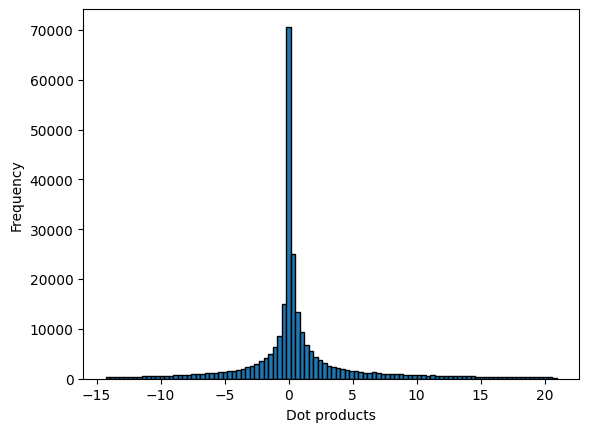

In [38]:
# for folder in folders:
folder = 'vr1.0_visc0.05both_nodivfree_acceleration'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
enstrophy = []
#     for i in range(begin,end):
file = 'ParticleData_Fluid_{}.vtk'.format(65)

mesh = meshio.read(full_path + file)
positions = mesh.points

lap = mesh.point_data['m_vorticity_rate_laplacian']
grad = mesh.point_data['m_vorticity_rate_gradient']
der = mesh.point_data['vorticity_derivative']
init = mesh.point_data['m_vorticity_init']

dot_products = np.sum(der * init, axis=1)
low, high = np.percentile(dot_products, [5, 95])
filtered = dot_products[(dot_products >= low) & (dot_products <= high)]
print(dot_products)
#     h = mesh.points[:,1]

plt.hist(filtered, bins=100, edgecolor='black')

plt.xlabel("Dot products")
plt.ylabel("Frequency")
plt.show()


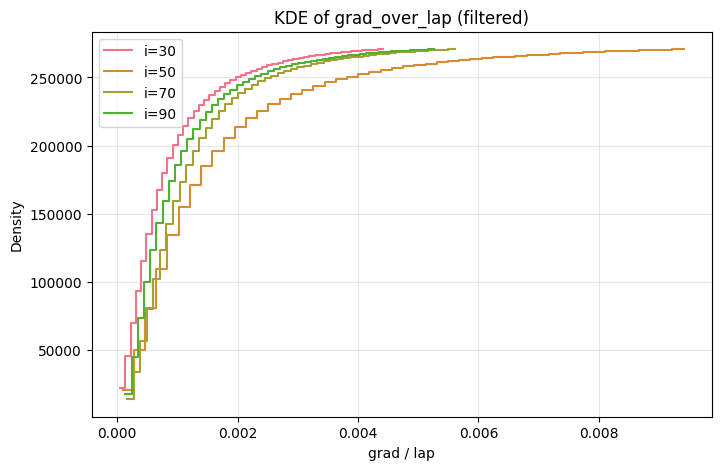

In [47]:
import os
import numpy as np
import meshio
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
colors = sns.color_palette("husl", 9)


# for folder in folders:
folder = 'vrvisc02_baseline_particle01'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
enstrophy = []

for idx, i in enumerate([30, 50, 70, 90]):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points

    vel = mesh.point_data['m_velocity_from_dfsph']
    delta_vel = mesh.point_data['delta_velocity']
    lap = mesh.point_data['m_vorticity_rate_laplacian'] / 0.02
    grad = mesh.point_data['m_vorticity_rate_gradient']
    init = mesh.point_data['m_vorticity_init']
    der = mesh.point_data['vorticity_derivative']

    norms_vel = np.linalg.norm(vel, axis=1)
    norms_lap = np.linalg.norm(lap, axis=1)
    norms_grad = np.linalg.norm(grad, axis=1)
    norms_init = np.linalg.norm(init, axis=1)
    norms_der = np.linalg.norm(der, axis=1)
    norms_del_vel = np.linalg.norm(delta_vel, axis=1)

    v_v = 0.02
    grad_over_vel = norms_grad / np.clip(norms_vel, 1e-8, None)
    grad_over_lap = norms_grad /  np.clip(v_v * norms_lap, 1e-8, None)
    lap_over_grad = v_v * norms_lap  /  np.clip(norms_grad, 1e-8, None)
    grad_over_init = norms_grad / np.clip(norms_init, 1e-8, None)
    lap_over_init = v_v * norms_lap / np.clip(norms_init, 1e-8, None)
    init_over_lap = norms_init  / np.clip(norms_lap, 1e-8, None)
    der_over_init = norms_der / np.clip(norms_init, 1e-8, None)
    rey = norms_vel * norms_init / np.clip(norms_lap, 1e-8, None)
    del_over_vel = norms_del_vel / np.clip(norms_vel, 1e-8, None)

    # percentile filtering
    low, high = np.percentile(del_over_vel, [2, 98])
    filtered = del_over_vel[(del_over_vel >= low) & (del_over_vel <= high)]

    # --- KDE plot ---
    # sns.kdeplot(filtered, fill=False, bw_method='scott', color=colors[idx], label=f"i={i}")
    # --- Histogram plot ---
    sns.histplot(
        filtered,
        bins=50,
        stat="count",     # normalize like KDE
        element="step",     # outline only (good for overlays)
        fill=False,
        color=colors[idx],
        label=f"i={i}",
        cumulative=True
    )

plt.xlabel("grad / lap")
plt.ylabel("Density")
plt.title("KDE of grad_over_lap (filtered)")
plt.grid(True, alpha=0.3)
plt.legend()
# plt.xlim(0.0, 0.03)
# plt.ylim(0, 0.5)

plt.show()


In [9]:
scene = 'DamBreakModelSmallerParticleMoreFluid2'

folder_path = splishsplash_path + scene + '/fluid visc 02/' 

print(folder_path)

folders = os.listdir(folder_path)
# folders.remove('alpha1.0_fluid0.01_vr0.02')

print(folders)

D:/gabi/DamBreakModelSmallerParticleMoreFluid2/fluid visc 02/
['vrvisc02_alpha1', 'vrvisc02_baseline']


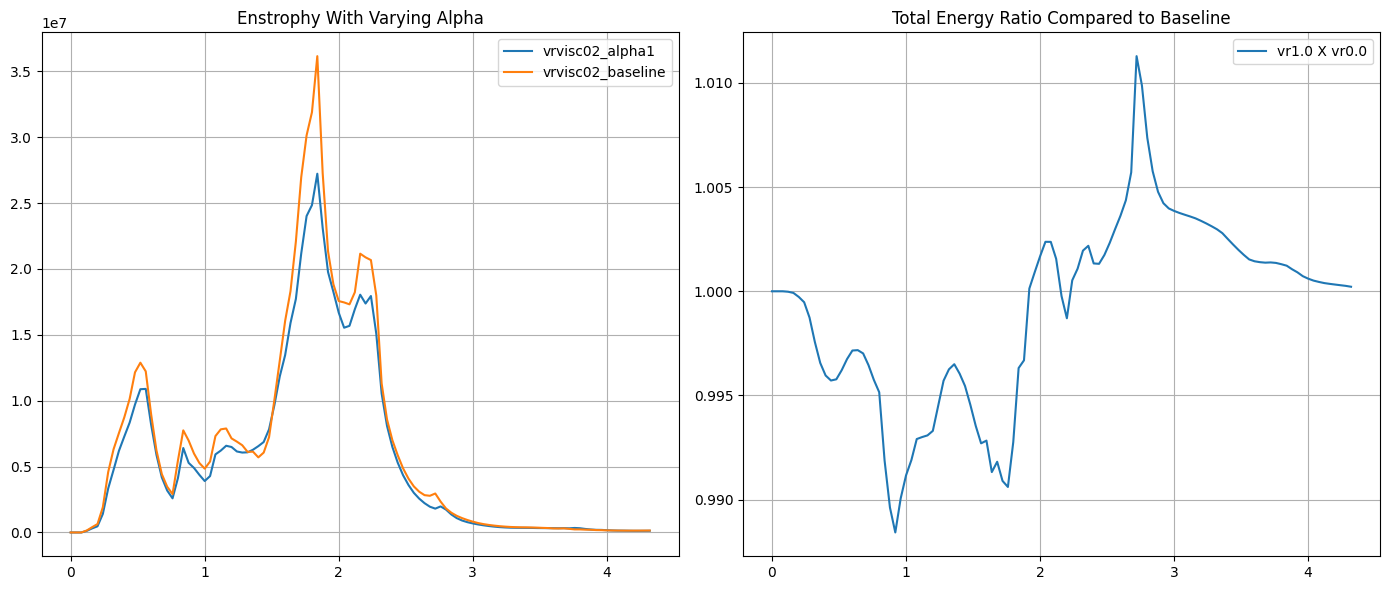

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 110
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_kin_energy + aux_pot_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))

    ax1.plot(time, enstrophy, label="{}".format(folder))
#     ax1.plot(time[50:75], enstrophy[50:75], label="{}".format(name))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['vrvisc02_alpha1'], total_energy['vrvisc02_baseline'])], label="vr1.0 X vr0.0")

ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


In [11]:
print(number_particles)

449624


In [8]:
scene = 'DamBreakModelSmallerParticleMoreFluid'

folder_path = splishsplash_path + scene + '/visc 0.02/' 

print(folder_path)

folders = os.listdir(folder_path)
# folders.remove('alpha1.0_fluid0.01_vr0.02')

print(folders)

D:/gabi/DamBreakModelSmallerParticleMoreFluid/visc 0.02/
['fluid02vr02baseline', 'fluid02vr02alpha1']


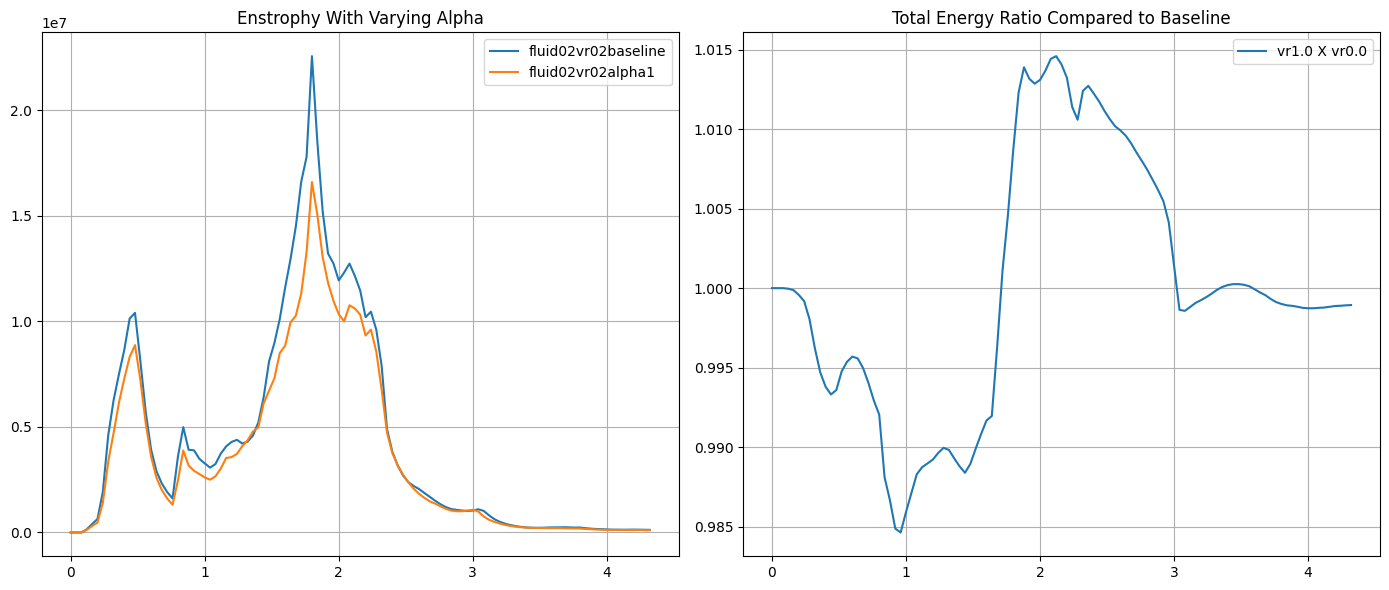

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 110
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_kin_energy + aux_pot_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))

    ax1.plot(time, enstrophy, label="{}".format(folder))
#     ax1.plot(time[50:75], enstrophy[50:75], label="{}".format(name))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['fluid02vr02alpha1'], total_energy['fluid02vr02baseline'])], label="vr1.0 X vr0.0")

ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


In [4]:
scene = 'DamBreakModelSmallerParticle'

folder_path = splishsplash_path + scene + '/visc 0.01/' 

print(folder_path)

folders = os.listdir(folder_path)
# folders.remove('alpha1.0_fluid0.01_vr0.02')

print(folders)

D:/gabi/DamBreakModelSmallerParticle/visc 0.01/
['cfl_baseline', 'cfl_alpha 1.2', 'no cfl 0.001 alpha 1.0', 'no cfl 0.001 alpha 1.2', 'no cfl 0.001 baseline', 'no cfl ts 0.0001 alpha 1.2', 'no cfl ts 0.0001 baseline', 'no cfl ts 0.0005 alpha 1.2', 'no cfl ts 0.0005 baseline', 'no cfl 0.005 alpha 1.2', 'no cfl 0.005 baseline']


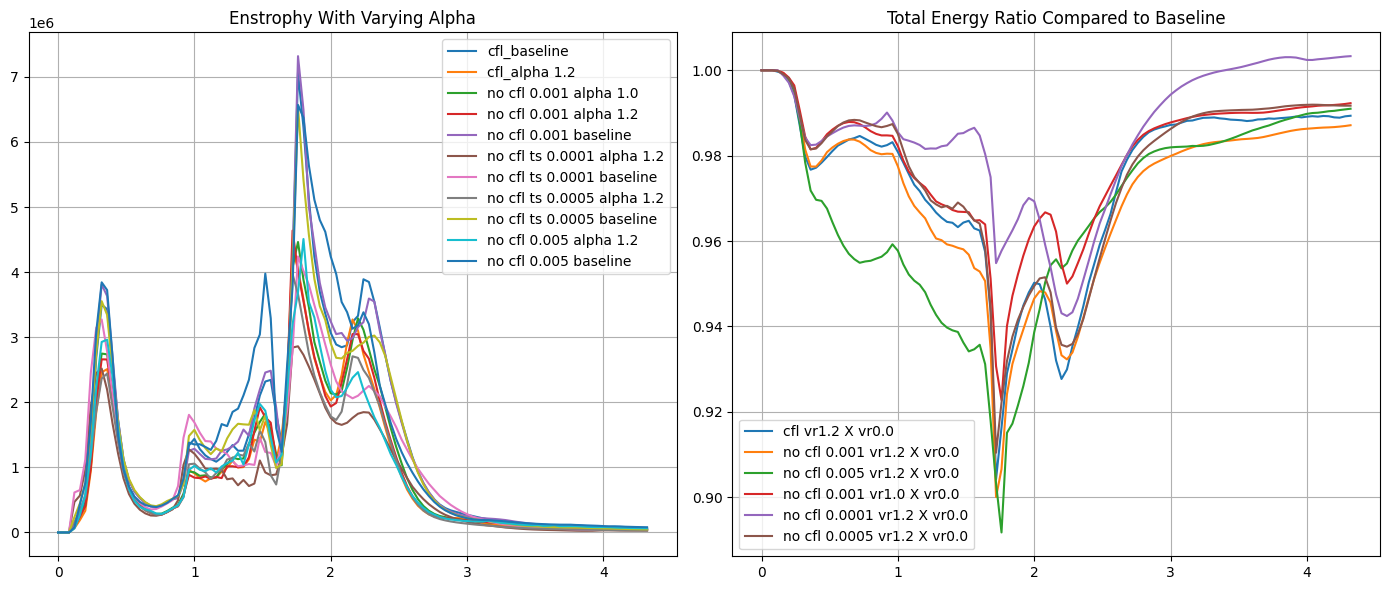

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 110
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_kin_energy + aux_pot_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))

    ax1.plot(time, enstrophy, label="{}".format(folder))
#     ax1.plot(time[50:75], enstrophy[50:75], label="{}".format(name))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['cfl_alpha 1.2'], total_energy['cfl_baseline'])], label="cfl vr1.2 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['no cfl 0.001 alpha 1.2'], total_energy['no cfl 0.001 baseline'])], label="no cfl 0.001 vr1.2 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['no cfl 0.005 alpha 1.2'], total_energy['no cfl 0.005 baseline'])], label="no cfl 0.005 vr1.2 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['no cfl 0.001 alpha 1.0'], total_energy['no cfl 0.001 baseline'])], label="no cfl 0.001 vr1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['no cfl ts 0.0001 alpha 1.2'], total_energy['no cfl ts 0.0001 baseline'])], label="no cfl 0.0001 vr1.2 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['no cfl ts 0.0005 alpha 1.2'], total_energy['no cfl ts 0.0005 baseline'])], label="no cfl 0.0005 vr1.2 X vr0.0")


ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


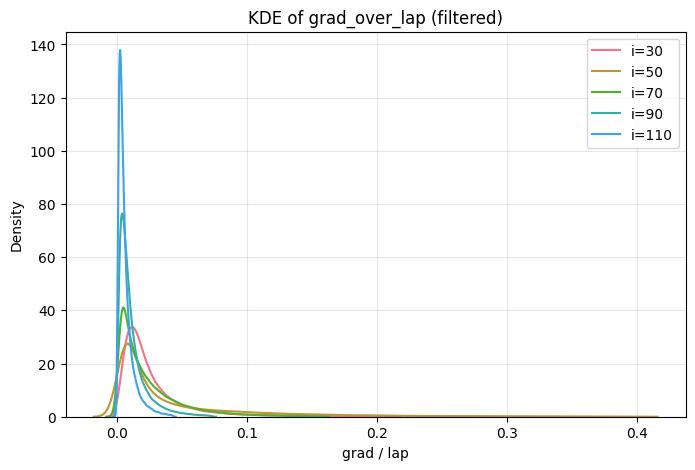

In [61]:
import os
import numpy as np
import meshio
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
colors = sns.color_palette("husl", 6)


# for folder in folders:
folder = 'no cfl 0.001 alpha 1.2'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
enstrophy = []

for idx, i in enumerate([30, 50, 70, 90, 110]):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points

    lap = mesh.point_data['m_vorticity_rate_laplacian']
    grad = mesh.point_data['m_vorticity_rate_gradient']

    norms_lap = np.linalg.norm(lap, axis=1)
    norms_grad = np.linalg.norm(grad, axis=1)

    grad_over_lap = norms_grad / np.clip(norms_lap, 1e-8, None)

    # percentile filtering
    low, high = np.percentile(grad_over_lap, [0, 99])
    filtered = grad_over_lap[(grad_over_lap >= low) & (grad_over_lap <= high)]

    # --- KDE plot ---
    sns.kdeplot(filtered, fill=False, bw_method='scott', color=colors[idx], label=f"i={i}")

plt.xlabel("grad / lap")
plt.ylabel("Density")
plt.title("KDE of grad_over_lap (filtered)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<Figure size 800x500 with 0 Axes>

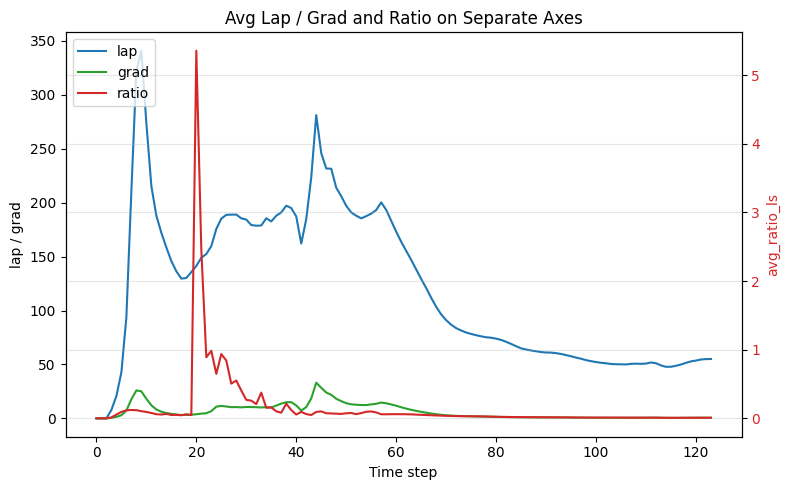

In [92]:
import os
import numpy as np
import meshio
import matplotlib.pyplot as plt
import seaborn as sns

# fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
# ax1, ax2 = axes 

begin = 1
end = 125
time = [i / 25 for i in range(end - begin)] 
# ax1.plot(time, total_energy[folder], label="{}".format(folder))    
# ax2.legend(fontsize=10)
# ax2.grid(True)
# ax2.set_title("Total Energy Ratio Compared to Baseline")

# plt.tight_layout()
# plt.show()

plt.figure(figsize=(8, 5))
colors = sns.color_palette("husl", 6)

fig, ax1 = plt.subplots(figsize=(8, 5))


# for folder in folders:
folder = 'no cfl 0.001 baseline'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
avg_ratio_ls = []
avg_lap = []
avg_grad = []

for i in range(begin, end):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points
    
    number_particles = len(positions)

    lap = mesh.point_data['m_vorticity_rate_laplacian']
    grad = mesh.point_data['m_vorticity_rate_gradient']

    norms_lap = np.linalg.norm(lap, axis=1)
    norms_grad = np.linalg.norm(grad, axis=1)
    
    avg_lap.append(np.mean(norms_lap))
    avg_grad.append(np.mean(norms_grad))

    grad_over_lap = norms_grad / np.clip(norms_lap, 1e-8, None)
    
    avg_ratio = np.mean(grad_over_lap)
    avg_ratio_ls.append(avg_ratio)

#     # percentile filtering
#     low, high = np.percentile(grad_over_lap, [0, 99])
#     filtered = grad_over_lap[(grad_over_lap >= low) & (grad_over_lap <= high)]

    # --- KDE plot ---

# First axis: lap and grad
ax1.plot(avg_lap, label="lap", color="tab:blue")
ax1.plot(avg_grad, label="grad", color="tab:green")
ax1.set_xlabel("Time step")
ax1.set_ylabel("lap / grad", color="black")
ax1.tick_params(axis='y', labelcolor='black')

# Second axis: avg_ratio_ls
ax2 = ax1.twinx()
ax2.plot(avg_ratio_ls, label="ratio", color="tab:red")
ax2.set_ylabel("avg_ratio_ls", color="tab:red")
ax2.tick_params(axis='y', labelcolor='tab:red')

# Combine legends from both axes
lns1, labels1 = ax1.get_legend_handles_labels()
lns2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, labels1 + labels2, loc="upper left")

plt.title("Avg Lap / Grad and Ratio on Separate Axes")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<Figure size 800x500 with 0 Axes>

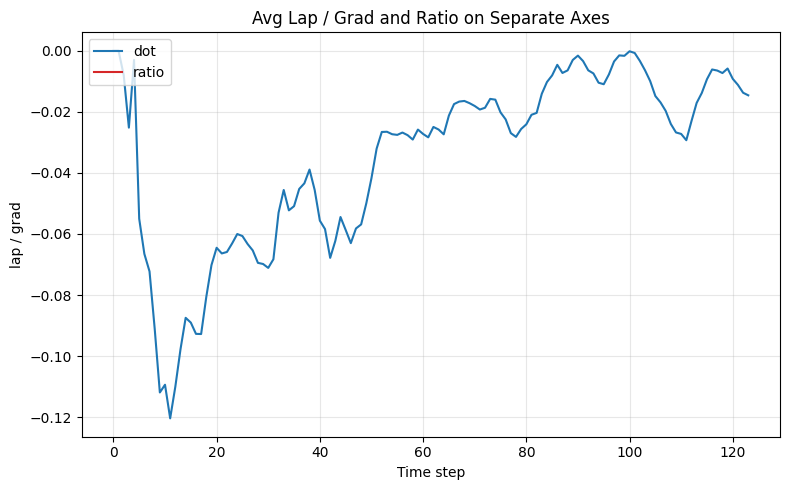

In [91]:
begin = 1
end = 125
time = [i / 25 for i in range(end - begin)] 

plt.figure(figsize=(8, 5))
colors = sns.color_palette("husl", 6)

fig, ax1 = plt.subplots(figsize=(8, 5))


# for folder in folders:
folder = 'no cfl 0.001 baseline'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
avg_ratio_ls = []
avg_lap = []
avg_grad = []
avg_dot_ls = []

for i in range(begin, end):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points
    
    number_particles = len(positions)

    lap = mesh.point_data['m_vorticity_rate_laplacian']
    grad = mesh.point_data['m_vorticity_rate_gradient']

    # Compute norms (shape: (N, 1))
    lap_norm = np.linalg.norm(lap, axis=1, keepdims=True)
    grad_norm = np.linalg.norm(grad, axis=1, keepdims=True)

    # Avoid division by zero
    lap_norm[lap_norm == 0] = 1.0
    grad_norm[grad_norm == 0] = 1.0

    # Normalize
    lap_unit = lap / lap_norm
    grad_unit = grad / grad_norm

    # Dot product of normalized vectors
    dot_norm = np.sum(lap_unit * grad_unit, axis=1)

    # Average
    avg_dot = np.mean(dot_norm)
    avg_dot_ls.append(avg_dot)


# First axis: lap and grad
ax1.plot(avg_dot_ls, label="dot", color="tab:blue")
ax1.set_xlabel("Time step")
ax1.set_ylabel("lap / grad", color="black")
ax1.tick_params(axis='y', labelcolor='black')

# Combine legends from both axes
lns1, labels1 = ax1.get_legend_handles_labels()
lns2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, labels1 + labels2, loc="upper left")

plt.title("Avg Lap / Grad and Ratio on Separate Axes")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


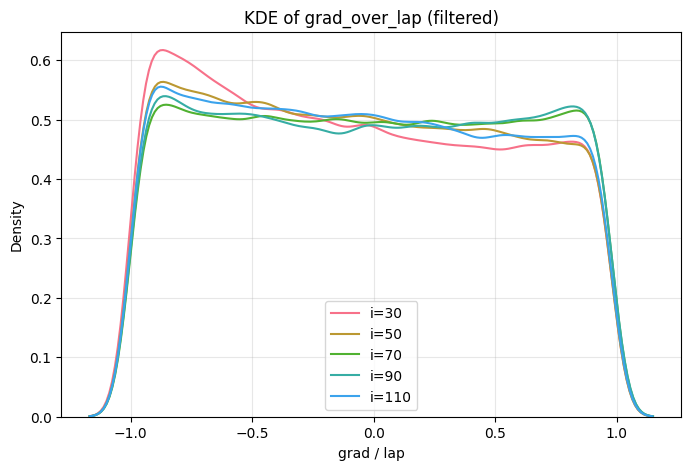

In [100]:
plt.figure(figsize=(8, 5))
colors = sns.color_palette("husl", 6)


# for folder in folders:
folder = 'no cfl 0.001 alpha 1.2'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
enstrophy = []

for idx, i in enumerate([30, 50, 70, 90, 110]):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points

    lap = mesh.point_data['m_vorticity_rate_laplacian']
    grad = mesh.point_data['m_vorticity_rate_gradient']

    # Compute norms (shape: (N, 1))
    lap_norm = np.linalg.norm(lap, axis=1, keepdims=True)
    grad_norm = np.linalg.norm(grad, axis=1, keepdims=True)

    # Avoid division by zero
    lap_norm[lap_norm == 0] = 1.0
    grad_norm[grad_norm == 0] = 1.0

    # Normalize
    lap_unit = lap / lap_norm
    grad_unit = grad / grad_norm

    # Dot product of normalized vectors
    dot_norm = np.sum(lap_unit * grad_unit, axis=1)

    # percentile filtering
    low, high = np.percentile(dot_norm, [0, 99])
    filtered = dot_norm[(dot_norm >= low) & (dot_norm <= high)]

    # --- KDE plot ---
    sns.kdeplot(filtered, fill=False, bw_method='scott', color=colors[idx], label=f"i={i}")

plt.xlabel("grad / lap")
plt.ylabel("Density")
plt.title("KDE of grad_over_lap (filtered)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [41]:
scene = 'DamBreakModelWithWalls'

folder_path = splishsplash_path + scene + '/'

print(folder_path)

folders = os.listdir(folder_path)

print(folders)

D:/gabi/DamBreakModelWithWalls/
['baseline_visc0.02both_particle01_ts0005', 'alpha1.0_visc0.02both_particle01_ts0005']


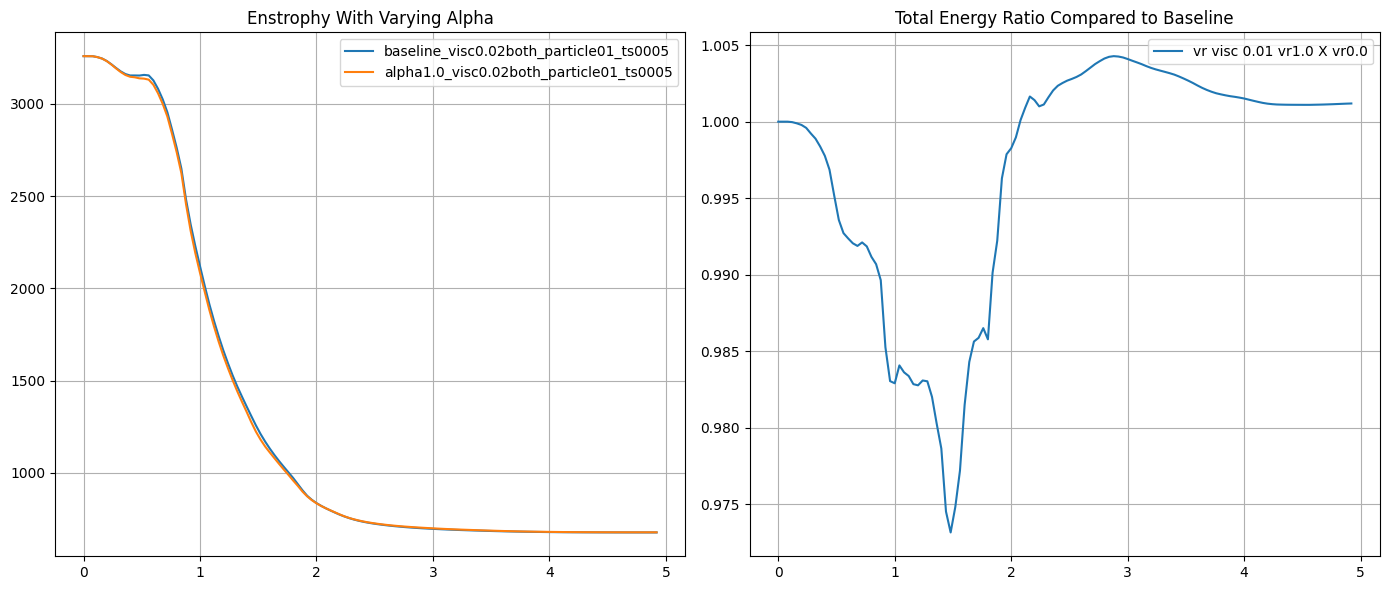

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 125
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.01 * 0.01 * 0.01

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_kin_energy + aux_pot_energy))
#             ls_total_energy.append((aux_pot_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
    ax1.plot(time, ls_total_energy, label="{}".format(folder))

#     ax1.plot(time, enstrophy, label="{}".format(folder))
#     ax1.plot(time[50:75], enstrophy[50:75], label="{}".format(name))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['alpha1.0_visc0.02both_particle01_ts0005'], total_energy['baseline_visc0.02both_particle01_ts0005'])], label="vr visc 0.01 vr1.0 X vr0.0")

ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


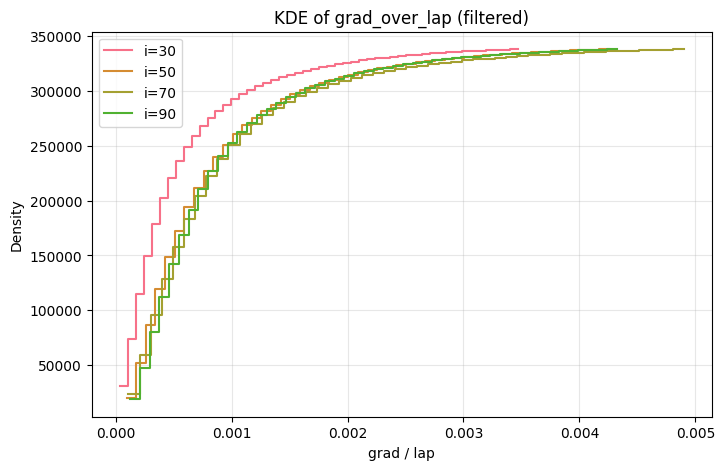

In [42]:
import os
import numpy as np
import meshio
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
colors = sns.color_palette("husl", 9)


# for folder in folders:
folder = 'baseline_visc0.02both_particle01_ts0005'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
enstrophy = []

for idx, i in enumerate([30, 50, 70, 90]):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points

    vel = mesh.point_data['m_velocity_from_dfsph']
    delta_vel = mesh.point_data['delta_velocity']
    lap = mesh.point_data['m_vorticity_rate_laplacian'] / 0.02
    grad = mesh.point_data['m_vorticity_rate_gradient']
    init = mesh.point_data['m_vorticity_init']
    der = mesh.point_data['vorticity_derivative']

    norms_vel = np.linalg.norm(vel, axis=1)
    norms_lap = np.linalg.norm(lap, axis=1)
    norms_grad = np.linalg.norm(grad, axis=1)
    norms_init = np.linalg.norm(init, axis=1)
    norms_der = np.linalg.norm(der, axis=1)
    norms_del_vel = np.linalg.norm(delta_vel, axis=1)

    v_v = 0.02
    grad_over_vel = norms_grad / np.clip(norms_vel, 1e-8, None)
    grad_over_lap = norms_grad /  np.clip(v_v * norms_lap, 1e-8, None)
    lap_over_grad = v_v * norms_lap  /  np.clip(norms_grad, 1e-8, None)
    grad_over_init = norms_grad / np.clip(norms_init, 1e-8, None)
    lap_over_init = v_v * norms_lap / np.clip(norms_init, 1e-8, None)
    init_over_lap = norms_init  / np.clip(norms_lap, 1e-8, None)
    der_over_init = norms_der / np.clip(norms_init, 1e-8, None)
    rey = norms_vel * norms_init / np.clip(norms_lap, 1e-8, None)
    del_over_vel = norms_del_vel / np.clip(norms_vel, 1e-8, None)

    # percentile filtering
    low, high = np.percentile(del_over_vel, [2, 98])
    filtered = del_over_vel[(del_over_vel >= low) & (del_over_vel <= high)]

    # --- KDE plot ---
    # sns.kdeplot(filtered, fill=False, bw_method='scott', color=colors[idx], label=f"i={i}")
    # --- Histogram plot ---
    sns.histplot(
        filtered,
        bins=50,
        stat="count",     # normalize like KDE
        element="step",     # outline only (good for overlays)
        fill=False,
        color=colors[idx],
        label=f"i={i}",
        cumulative=True
    )

plt.xlabel("grad / lap")
plt.ylabel("Density")
plt.title("KDE of grad_over_lap (filtered)")
plt.grid(True, alpha=0.3)
plt.legend()
# plt.xlim(0.0, 0.03)
# plt.ylim(0, 0.5)

plt.show()


In [20]:
print(norms_lap)
print(norms_lap.size)
print(np.sort(norms_lap))
print(norms_grad)
print(np.sort(norms_grad))
print(grad_over_lap)
print(np.sort(grad_over_lap))

[ 8552.867  11233.091  30112.062  ...  9958.474   9902.114   4937.7407]
351936
[     0.        0.        0.   ...  95957.49  98355.54 107610.09]
[4.812433   3.2501535  5.264849   ... 0.37719402 0.42497724 0.3580186 ]
[ 0.        0.        0.       ... 27.665825 30.46918  49.614754]
[0.02813345 0.01446687 0.00874209 ... 0.00189383 0.00214589 0.00362533]
[0.        0.        0.        ... 0.5431247 0.6328173 1.9553326]


In [36]:
scene = 'ShearFlow3D'

folder_path = splishsplash_path + scene + '/'

print(folder_path)
# folders = os.listdir(folder_path)

folders = {}
# folders['alpha0.0_fluid0.01_vr0.0_particle_0.02_ts_0.001'] = 'Baseline'
# folders['alpha1.3_fluid0.01_vr0.0_particle_0.02_ts_0.001'] = 'Method Viscosity 0, Alpha 1.3'
folders['alpha1.3_fluid0.01_vr0.01_particle_0.02_ts_0.001'] = 'Method Viscosity 0.01, Alpha 1.3'
# folders['alpha 1.3_fluid0.01_vr0.01_particle_0.02_ts_0.001_diff_mod_k_3_min0.2'] = 'Method mod k = 3'
# folders['alpha 1.3_fluid0.01_vr0.01_particle_0.02_ts_0.001_diff_mod_k_5'] = 'Method mod k = 5'


print(folders)


D:/gabi/ShearFlow3D/
{'alpha1.3_fluid0.01_vr0.01_particle_0.02_ts_0.001': 'Method Viscosity 0.01, Alpha 1.3'}


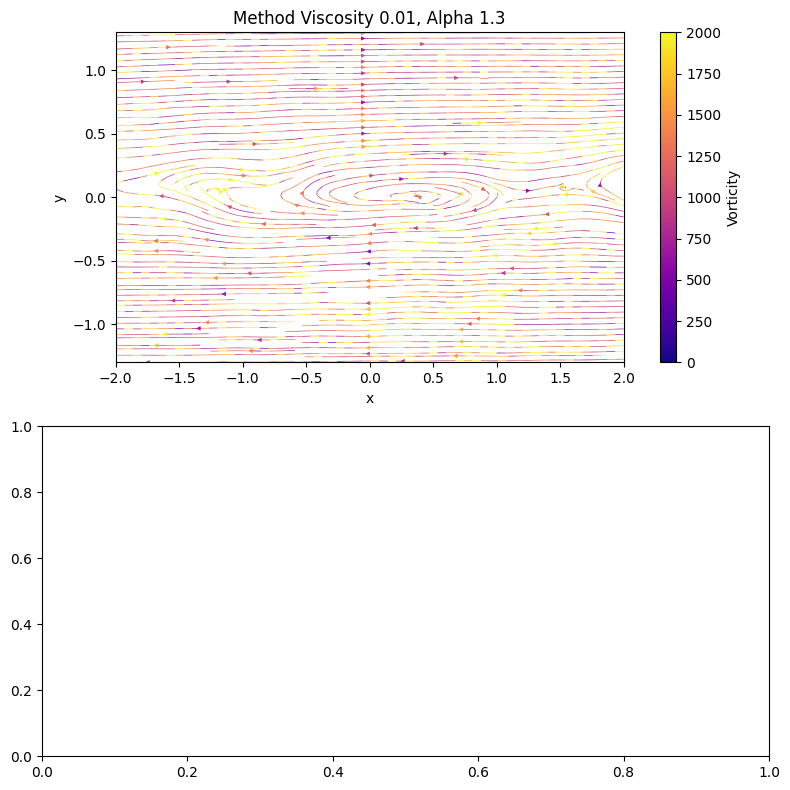

In [37]:
from matplotlib.colors import Normalize

norm_color = Normalize(vmin=0, vmax=2000)


### --- Define the grid limits once so all plots share the same scale ---
x_min, x_max = -2, 2
y_min, y_max = -1.3, 1.3
grid_x = np.linspace(x_min, x_max, 1000)
grid_y = np.linspace(y_min, y_max, 1000)
X, Y = np.meshgrid(grid_x, grid_y)

# Create a single figure with 3 subplots stacked vertically
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 8))

for i, folder in enumerate(folders.keys()):
    full_path = folder_path + folder + '/'
    
    file = 'ParticleData_Fluid_40.vtk'
    
    mesh = meshio.read(full_path + file)
    positions = mesh.points
    velocity = mesh.point_data['velocity']
    vorticity = mesh.point_data['vorticity_linear_field']
    vort = np.linalg.norm(vorticity, axis=1)

    lap = mesh.point_data['m_vorticity_rate_laplacian'] / 0.02
    grad = mesh.point_data['m_vorticity_rate_gradient']
    norms_lap = np.linalg.norm(lap, axis=1)
    norms_grad = np.linalg.norm(grad, axis=1)
    v_v = 0.02
    grad_over_lap = v_v * norms_lap /  np.clip(vort, 1e-8, None)

    x = positions[:, 0]
    y = positions[:, 1]
    vx = velocity[:, 0]
    vy = velocity[:, 1]

    # Interpolate velocities onto the fixed grid
    VX = griddata((x, y), vx, (X, Y), method='linear')
    VY = griddata((x, y), vy, (X, Y), method='linear')
    
    # Interpolate vorticity onto the grid
    # VORT = griddata((x, y), vort, (X, Y), method='linear')

    # Interpolate vorticity onto the grid
    VORT = griddata((x, y), norms_lap, (X, Y), method='linear')

    # Handle NaNs
    mask = np.isnan(VX) | np.isnan(VY) | np.isnan(VORT)
    VX[mask] = 0
    VY[mask] = 0
    VORT[mask] = 0

    ax = axes[i]

    # --- STREAMPLOT COLORED BY VORTICITY ---
    strm = ax.streamplot(
        X, Y, VX, VY,
        color=VORT,               # << color by vorticity
        cmap='plasma',             # or 'viridis', 'plasma', etc.
        linewidth=0.5,
        density=2.0,
        arrowsize=0.6
        ,
        norm=norm_color
    )


#     # Handle NaNs
#     mask = np.isnan(VX) | np.isnan(VY)
#     VX[mask] = 0
#     VY[mask] = 0

#     speed = np.sqrt(VX**2 + VY**2)

#     ax = axes[i]
#     # Adjust streamplot settings for black and white streamlines with high density
#     strm = ax.streamplot(X, Y, VX, VY, color='k', linewidth=0.5, density=2.0, arrowsize=0.6)  # Increased density and black streamlines

    # Add colorbar
    cbar = fig.colorbar(strm.lines, ax=ax)
    cbar.set_label("Vorticity")
    
    ax.set_title(f"{folders[folder]}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', adjustable='box')

# Adjust the layout to make space for the colorbar (if needed)
fig.subplots_adjust(right=2.0)

plt.tight_layout()
plt.show()


In [4]:
splishsplash_path = 'E:/gabi/thesis/'
scene = 'Ramp'

folder_path = splishsplash_path + scene + '/'

print(folder_path)

folders = os.listdir(folder_path)
# folders.remove('baseline_firsttry')
# folders.remove('baseline_faster')

print(folders)

E:/gabi/thesis/Ramp/
['visc02both_particle01_alpha0_cfl001', 'visc02both_particle01_alpha13_cfl001']


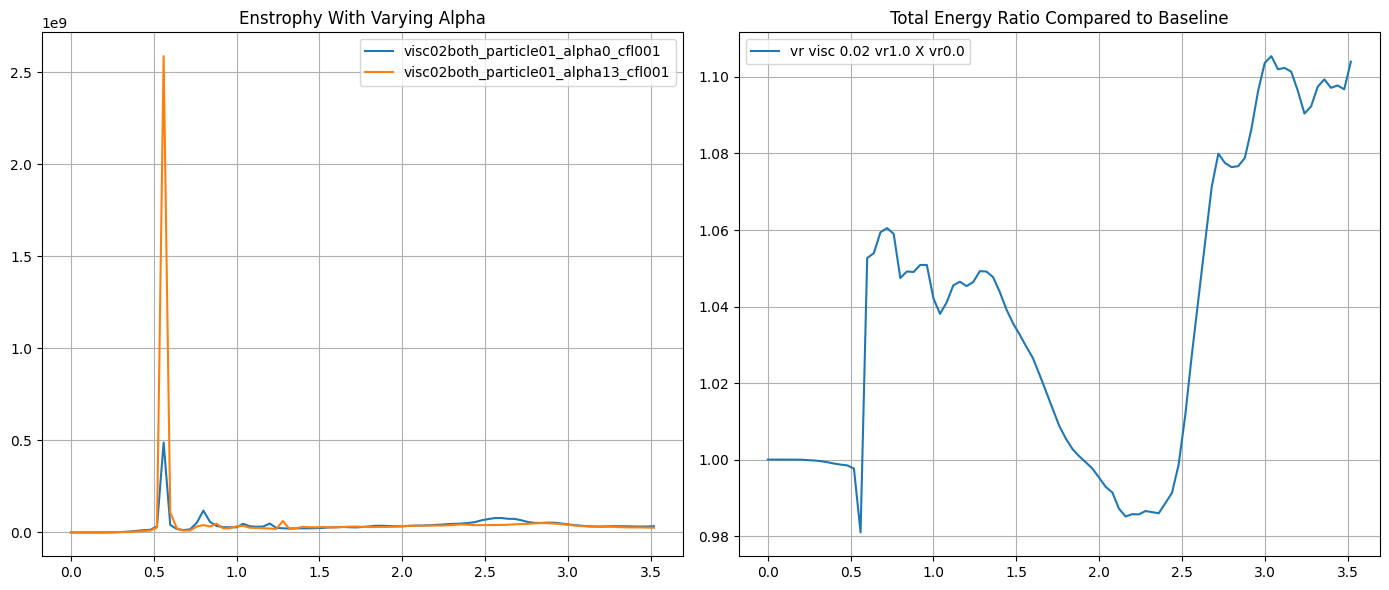

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 175
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_kin_energy + aux_pot_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))

    ax1.plot(time, enstrophy, label="{}".format(folder))
#     ax1.plot(time[50:75], enstrophy[50:75], label="{}".format(name))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['visc02both_particle01_alpha13_cfl001'], total_energy['visc02both_particle01_alpha0_cfl001'])], label="vr visc 0.02 vr1.0 X vr0.0")


ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


# Energia entre simulacoes

In [5]:
scene = 'RotatingCylinder'

folder_path_cylinder = splishsplash_path + scene + '/'

print(folder_path_cylinder)

folders_cylinder = os.listdir(folder_path_cylinder)
# folders_cylinder = ['baseline']

print(folders_cylinder)


scene = 'DamBreakModelWithWallMoreFluidMoreParticles'

folder_path_dam = splishsplash_path + scene + '/visc0.02/'

print(folder_path_dam)

folders_dam = os.listdir(folder_path_dam)
# folders_dam = ['vrvisc02_baseline_particle01']

print(folders_dam)


scene = 'Ramp'

folder_path_ramp = splishsplash_path_e + scene + '/'

print(folder_path_ramp)

folders_ramp = os.listdir(folder_path_ramp)
# folders_ramp = ['visc02both_particle01_alpha0_cfl001']

print(folders_ramp)



D:/gabi/RotatingCylinder/
['baseline_firsttry', 'baseline_faster', 'baseline', 'alpha 1.0', 'alpha 1.0 density vr 0.01']
D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.02/
['vrvisc00_baseline_particle01', 'vrvisc02_baseline_particle01', 'vrvisc05_baseline_particle01', 'vrvisc00_alpha15_particle01', 'vrvisc00_alpha13_particle01', 'vrvisc00_alpha1_particle01', 'vrvisc02_alpha1_particle01', 'vrvisc05_alpha1_particle01', 'vrvisc02_alpha1_particle02', 'vrvisc02_alpha1_particle015', 'vrvisc02_baseline_particle02', 'vrvisc02_baseline_particle015', 'vrvisc01_alpha1_particle01', 'vrvisc1_alpha1_particle01', 'vrvisc02_baseline_particle025', 'vrvisc02_alpha1_particle025', 'vrvisc01_alpha0_particle01', 'vrvisc1_alpha0_particle01', 'vrvisc02_alpha1_particle01_modinit200', 'vrvisc02_alpha1_particle01_modgrad500']
E:/gabi/thesis/Ramp/
['visc02both_particle01_alpha0_cfl001', 'visc02both_particle01_alpha13_cfl001']


In [6]:
folders = ['D:/gabi/RotatingCylinder/baseline/','D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.02/vrvisc02_baseline_particle01/'
          , 'E:/gabi/thesis/Ramp/visc02both_particle01_alpha0_cfl001/']
print(folders)

['D:/gabi/RotatingCylinder/baseline/', 'D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.02/vrvisc02_baseline_particle01/', 'E:/gabi/thesis/Ramp/visc02both_particle01_alpha0_cfl001/']


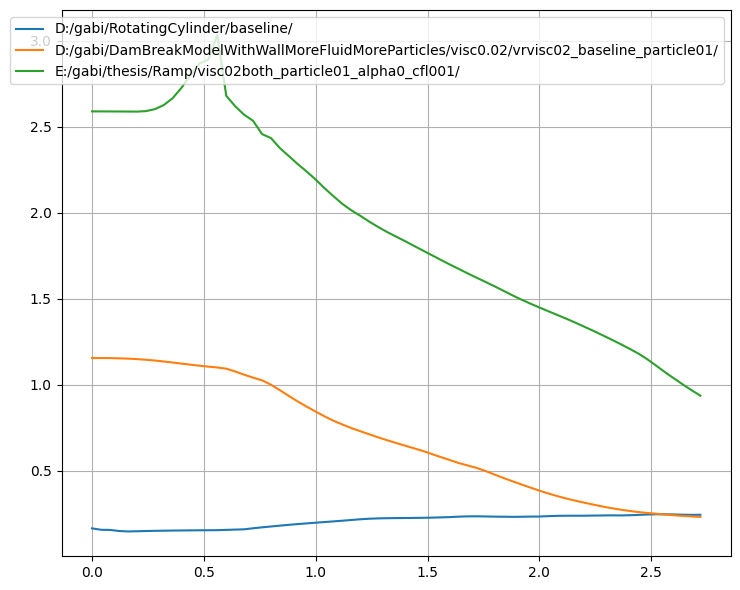

In [8]:
plt.figure(figsize=(8, 6))
begin = 1
end = 70
time = [i / 25 for i in range(end - begin)]

for folder in folders:
    full_path = folder
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.average(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.average((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    # plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(time, total_energy, label="{}".format(folder))

plt.legend(fontsize=10)          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing
# plt.xticks(np.arange(0, 70, step=1))


plt.show()

In [27]:
folders = ['D:/gabi/RotatingCylinder/alpha 1.0/','D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.02/vrvisc02_alpha1_particle01/'
          , 'E:/gabi/thesis/Ramp/visc02both_particle01_alpha13_cfl001/']
print(folders)

['D:/gabi/RotatingCylinder/alpha 1.0/', 'D:/gabi/DamBreakModelWithWallMoreFluidMoreParticles/visc0.02/vrvisc02_alpha1_particle01/', 'E:/gabi/thesis/Ramp/visc02both_particle01_alpha13_cfl001/']


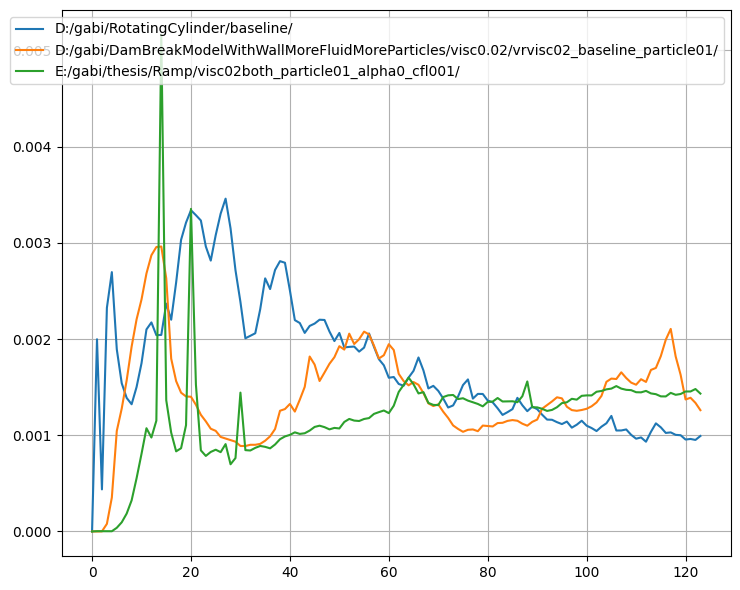

In [23]:
plt.figure(figsize=(8, 6))
begin = 1
end = 125
time = [i / 25 for i in range(70)]

for folder in folders:
    full_path = folder
    files = os.listdir(full_path)
    
    del_Vel = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['m_velocity_from_dfsph']
        delta_velocity = mesh.point_data['delta_velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            del_over_vel = np.average(norm(delta_velocity, axis=1)/np.clip(norm(velocity, axis=1), 1e-8, None))
            del_Vel.append(del_over_vel)

        else:
            del_Vel.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(del_Vel, label="{}".format(folder))
    # plt.plot(time, total_energy, label="{}".format(folder))

plt.legend(fontsize=10)          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing
# plt.xticks(np.arange(0, 70, step=1))


plt.show()

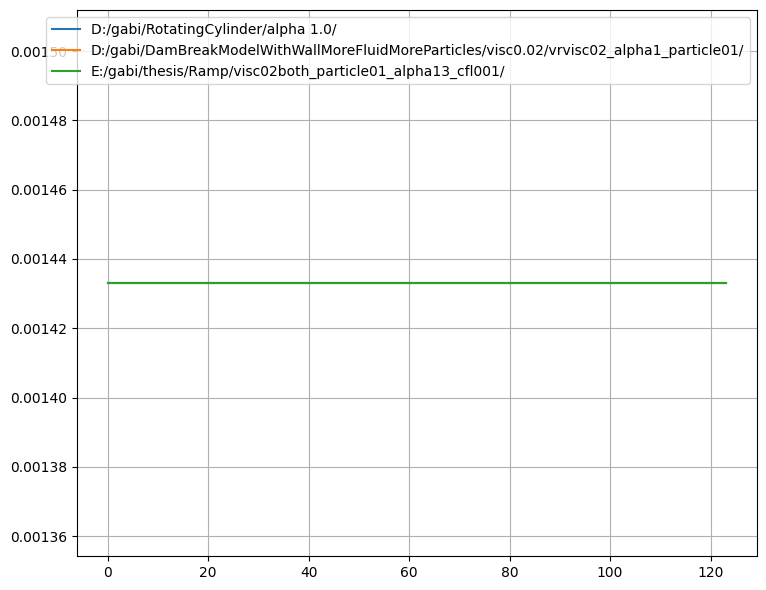

In [28]:
plt.figure(figsize=(8, 6))
begin = 1
end = 125
time = [i / 25 for i in range(70)]

for folder in folders:
    full_path = folder
    files = os.listdir(full_path)
    
    ls_lap = []
    
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        lap = mesh.point_data['m_vorticity_rate_laplacian']

        number_particles = len(h)
        if number_particles > 0:
            tot_lap = np.average(norm(lap, axis=1))
            ls_lap.append(del_over_vel)

        else:
            ls_lap.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(ls_lap, label="{}".format(folder))
    # plt.plot(time, total_energy, label="{}".format(folder))

plt.legend(fontsize=10)          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing
# plt.xticks(np.arange(0, 70, step=1))


plt.show()

In [3]:
scene = 'RotatingCylinder'

folder_path = splishsplash_path + scene + '/'

print(folder_path)

folders = os.listdir(folder_path)
folders.remove('baseline_firsttry')
folders.remove('baseline_faster')

print(folders)

# 75 looks a good scene

D:/gabi/RotatingCylinder/
['baseline', 'alpha 1.0', 'alpha 1.0 density vr 0.01']


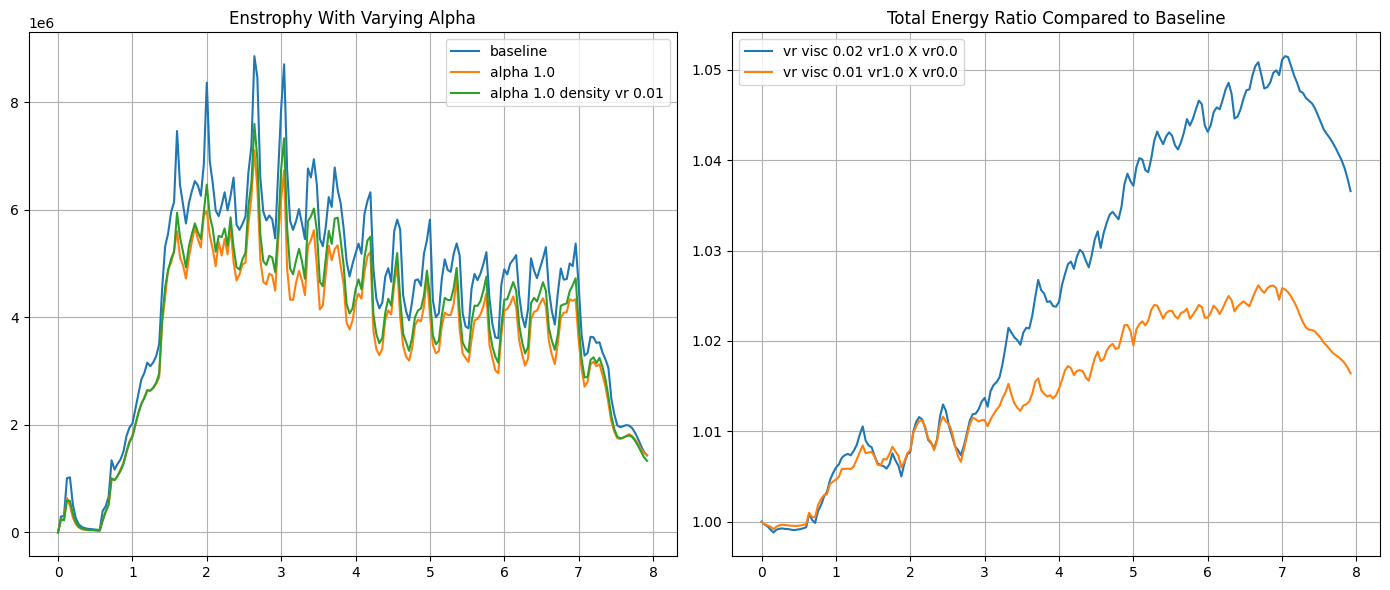

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 200
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            ls_total_energy.append((aux_kin_energy + aux_pot_energy))
#             ls_total_energy.append((aux_kin_energy))
            aux_kin_ens = np.sum((norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
    total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))

    ax1.plot(time, enstrophy, label="{}".format(folder))
#     ax1.plot(time[50:75], enstrophy[50:75], label="{}".format(name))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0'], total_energy['baseline'])], label="vr visc 0.02 vr1.0 X vr0.0")
ax2.plot(time, [x / y for x, y in zip(total_energy['alpha 1.0 density vr 0.01'], total_energy['baseline'])], label="vr visc 0.01 vr1.0 X vr0.0")


ax2.legend(fontsize=10)
ax2.grid(True)
ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


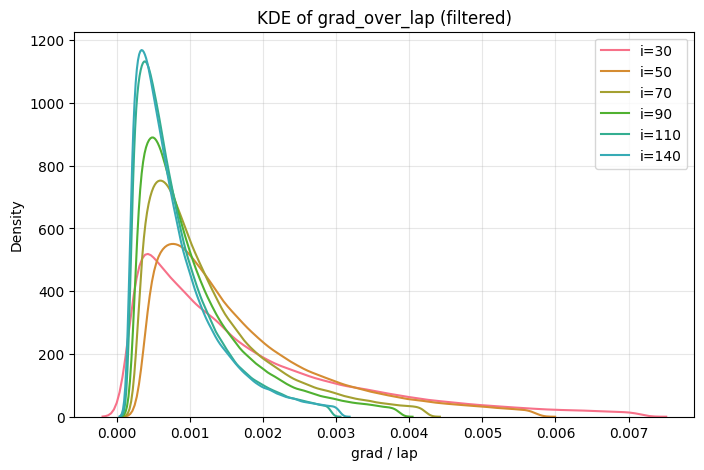

In [40]:
import os
import numpy as np
import meshio
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
colors = sns.color_palette("husl", 9)


# for folder in folders:
folder = 'alpha 1.0'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
enstrophy = []

for idx, i in enumerate([30, 50, 70, 90, 110, 140]):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points

    vel = mesh.point_data['m_velocity_from_dfsph']
    deltavel = mesh.point_data['delta_velocity']
    lap = mesh.point_data['m_vorticity_rate_laplacian']
    grad = mesh.point_data['m_vorticity_rate_gradient']
    init = mesh.point_data['m_vorticity_init']
    der = mesh.point_data['vorticity_derivative']

    norms_delvel = np.linalg.norm(deltavel, axis=1)
    norms_vel = np.linalg.norm(vel, axis=1)
    norms_lap = np.linalg.norm(lap, axis=1)
    norms_grad = np.linalg.norm(grad, axis=1)
    norms_init = np.linalg.norm(init, axis=1)
    norms_der = np.linalg.norm(der, axis=1)

    del_over_vel = norms_delvel / np.clip(norms_vel, 1e-8, None)
    grad_over_vel = norms_grad / np.clip(norms_vel, 1e-8, None)
    grad_over_lap = norms_grad / np.clip(norms_lap, 1e-8, None)
    grad_over_init = norms_grad / np.clip(norms_init, 1e-8, None)
    lap_over_init = norms_lap / np.clip(norms_init, 1e-8, None)
    der_over_init = norms_der / np.clip(norms_init, 1e-8, None)
    rey = norms_vel * norms_init / np.clip(norms_lap, 1e-8, None)
    # rey = norms_lap / np.clip(norms_vel * norms_init, 1e-8, None)

    # percentile filtering
    low, high = np.percentile(del_over_vel, [5, 95])
    filtered = del_over_vel[(del_over_vel >= low) & (del_over_vel <= high)]

    # --- KDE plot ---
    sns.kdeplot(filtered, fill=False, bw_method='scott', color=colors[idx], label=f"i={i}")

plt.xlabel("grad / lap")
plt.ylabel("Density")
plt.title("KDE of grad_over_lap (filtered)")
plt.grid(True, alpha=0.3)
plt.legend()
# plt.xlim(-0.05, 0.2)

plt.show()


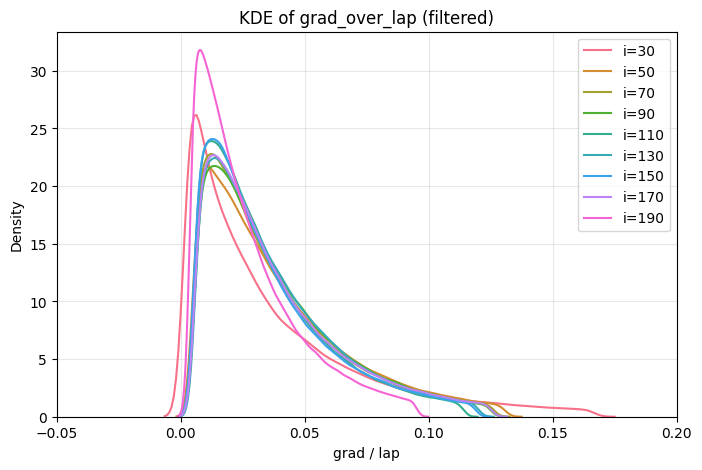

In [36]:
import os
import numpy as np
import meshio
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
colors = sns.color_palette("husl", 9)


# for folder in folders:
folder = 'baseline'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
enstrophy = []

for idx, i in enumerate([30, 50, 70, 90, 110, 130, 150, 170, 190]):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points

    lap = mesh.point_data['m_vorticity_rate_laplacian']
    grad = mesh.point_data['m_vorticity_rate_gradient']
    init = mesh.point_data['m_vorticity_init']
    der = mesh.point_data['vorticity_derivative']

    norms_lap = np.linalg.norm(lap, axis=1)
    norms_grad = np.linalg.norm(grad, axis=1)
    norms_init = np.linalg.norm(init, axis=1)
    norms_der = np.linalg.norm(der, axis=1)

    grad_over_lap = norms_grad / np.clip(norms_lap, 1e-8, None)
    grad_over_init = norms_grad / np.clip(norms_init, 1e-8, None)
    lap_over_init = norms_lap / np.clip(norms_init, 1e-8, None)
    der_over_init = norms_der / np.clip(norms_init, 1e-8, None)

    # percentile filtering
    low, high = np.percentile(grad_over_lap, [5, 95])
    filtered = grad_over_lap[(grad_over_lap >= low) & (grad_over_lap <= high)]

    # --- KDE plot ---
    sns.kdeplot(filtered, fill=False, bw_method='scott', color=colors[idx], label=f"i={i}")

plt.xlabel("grad / lap")
plt.ylabel("Density")
plt.title("KDE of grad_over_lap (filtered)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(-0.05, 0.2)

plt.show()


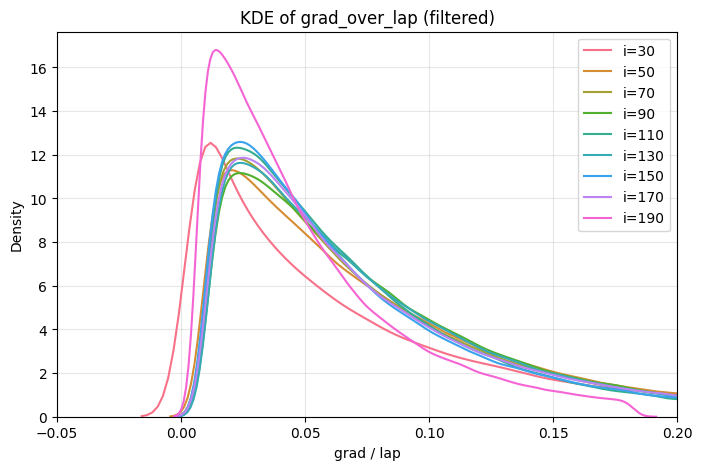

In [35]:
import os
import numpy as np
import meshio
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
colors = sns.color_palette("husl", 9)


# for folder in folders:
folder = 'alpha 1.0 density vr 0.01'
full_path = folder_path + folder + '/'
files = os.listdir(full_path)

ls_total_energy = []
enstrophy = []

for idx, i in enumerate([30, 50, 70, 90, 110, 130, 150, 170, 190]):
    file = 'ParticleData_Fluid_{}.vtk'.format(i)

    mesh = meshio.read(full_path + file)
    positions = mesh.points

    lap = mesh.point_data['m_vorticity_rate_laplacian']
    grad = mesh.point_data['m_vorticity_rate_gradient']
    init = mesh.point_data['m_vorticity_init']
    der = mesh.point_data['vorticity_derivative']

    norms_lap = np.linalg.norm(lap, axis=1)
    norms_grad = np.linalg.norm(grad, axis=1)
    norms_init = np.linalg.norm(init, axis=1)
    norms_der = np.linalg.norm(der, axis=1)

    grad_over_lap = norms_grad / np.clip(norms_lap, 1e-8, None)
    grad_over_init = norms_grad / np.clip(norms_init, 1e-8, None)
    lap_over_init = norms_lap / np.clip(norms_init, 1e-8, None)
    der_over_init = norms_der / np.clip(norms_init, 1e-8, None)

    # percentile filtering
    low, high = np.percentile(grad_over_lap, [5, 95])
    filtered = grad_over_lap[(grad_over_lap >= low) & (grad_over_lap <= high)]

    # --- KDE plot ---
    sns.kdeplot(filtered, fill=False, bw_method='scott', color=colors[idx], label=f"i={i}")

plt.xlabel("grad / lap")
plt.ylabel("Density")
plt.title("KDE of grad_over_lap (filtered)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(-0.05, 0.2)
plt.show()


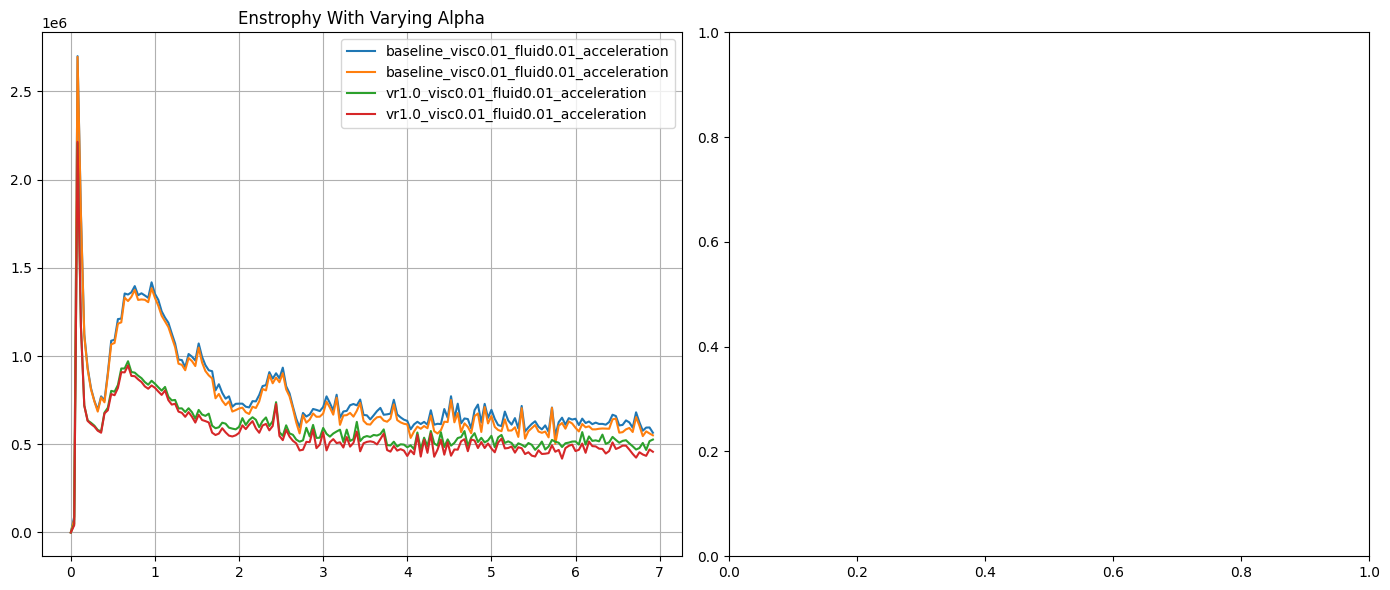

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
ax1, ax2 = axes 

begin = 1
end = 175
time = [i / 25 for i in range(end - begin)]

total_energy = {}
    
for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    ls_total_energy = []
    enstrophy_linear = []
    enstrophy_eq = []
    for i in range(begin,end):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        vorticity_linear = mesh.point_data['vorticity_linear_field']
        vorticity_eq = mesh.point_data['m_vorticity_equation']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:

            aux_kin_ens = np.sum((norm(vorticity_linear, axis=1)**2) / 2)
            enstrophy_linear.append(aux_kin_ens)
            
            aux_kin_ens = np.sum((norm(vorticity_eq, axis=1)**2) / 2)
            enstrophy_eq.append(aux_kin_ens)
#         else:
#             ls_total_energy.append(0)
            
#     total_energy[folder] = ls_total_energy
#     ax1.plot(time, ls_total_energy, label="{}".format(folder))

    ax1.plot(time, enstrophy_linear, label="{}".format(folder))
    ax1.plot(time, enstrophy_eq, label="{}".format(folder))
#     ax1.plot(time[50:75], enstrophy[50:75], label="{}".format(name))
    

ax1.legend(fontsize=10)          # show the labels
ax1.grid(True)        # optional grid
# ax1.set_title("Total Energy With Varying Alpha")
ax1.set_title("Enstrophy With Varying Alpha")

# ax2.plot(time, [x / y for x, y in zip(total_energy['vr1.0_visc0.01_fluid0.01_acceleration'], total_energy['baseline_visc0.01_fluid0.01_acceleration'])], label="vr visc 0.01 vr1.0 X vr0.0")

# ax2.legend(fontsize=10)
# ax2.grid(True)
# ax2.set_title("Total Energy Ratio Compared to Baseline")

plt.tight_layout()
plt.show()


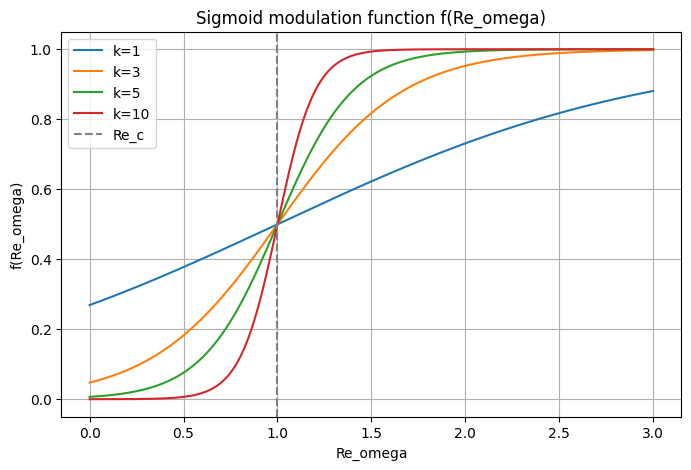

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(Re_omega, Re_c, k):
    return 1 / (1 + np.exp(-k * (Re_omega - Re_c)))

# Parameters
Re_c = 1.0                  # threshold
k_values = [1, 3, 5, 10]    # different sharpness values
Re_omega = np.linspace(0, 3, 500)  # range of Re_omega values

# Plot
plt.figure(figsize=(8,5))
for k in k_values:
    f = sigmoid(Re_omega, Re_c, k)
    plt.plot(Re_omega, f, label=f'k={k}')

plt.axvline(Re_c, color='gray', linestyle='--', label='Re_c')
plt.title('Sigmoid modulation function f(Re_omega)')
plt.xlabel('Re_omega')
plt.ylabel('f(Re_omega)')
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()


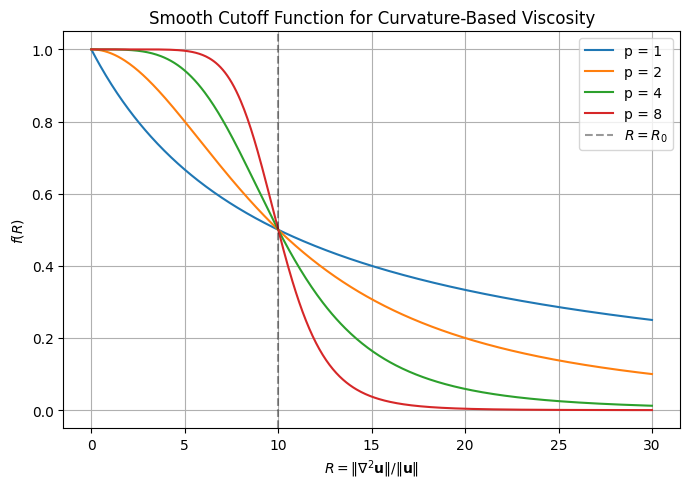

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
R0 = 10.0                      # cutoff scale
R = np.linspace(0, 3*R0, 500) # curvature ratio range
p_values = [1, 2, 4, 8]       # different sharpness parameters

plt.figure(figsize=(7, 5))

for p in p_values:
    f = 1.0 / (1.0 + (R / R0)**p)
    plt.plot(R, f, label=f"p = {p}")

# Plot styling
plt.axvline(R0, color='k', linestyle='--', alpha=0.4, label=r"$R = R_0$")
plt.xlabel(r"$R = \|\nabla^2 \mathbf{u}\| / \|\mathbf{u}\|$")
plt.ylabel(r"$f(R)$")
plt.title("Smooth Cutoff Function for Curvature-Based Viscosity")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
